In [ ]:
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#   https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.


# Retrieval-Centric Deep Learning in Growing Nonparametric Neural Networks

Retrieval-Centric Deep Learning (RCDL) proposes a general-purpose layer for deep learning that, instead of compressing arbitrary-size training data into fixed-size weight matrices via gradients i.e. $W \leftarrow W - \eta \nabla_W \ell$, stores a new pair of key-value representations for every data point during training. At inference time, it then retrieves
and recombines these representations through an attention mechanism resulting in a growing neural net (NN) in width over the course of training. See the Table 1 from our paper below for an illustrative comparison of common weight learning vs. of our new family of RCDL layers.


We derive such a “retrieval-centric deep learning” paradigm from the classic duality of a linear layer trained by gradient descent as a type of linear attention (LA) over the training data points—
which motivates us to replace the corresponding LA by a more powerful form of
attention from recent work on sequence models, namely, kernelized attention using radial basis function (RBF) and softmax-like kernels. Please see our paper  [[LINK TODO]](https://) for more details.


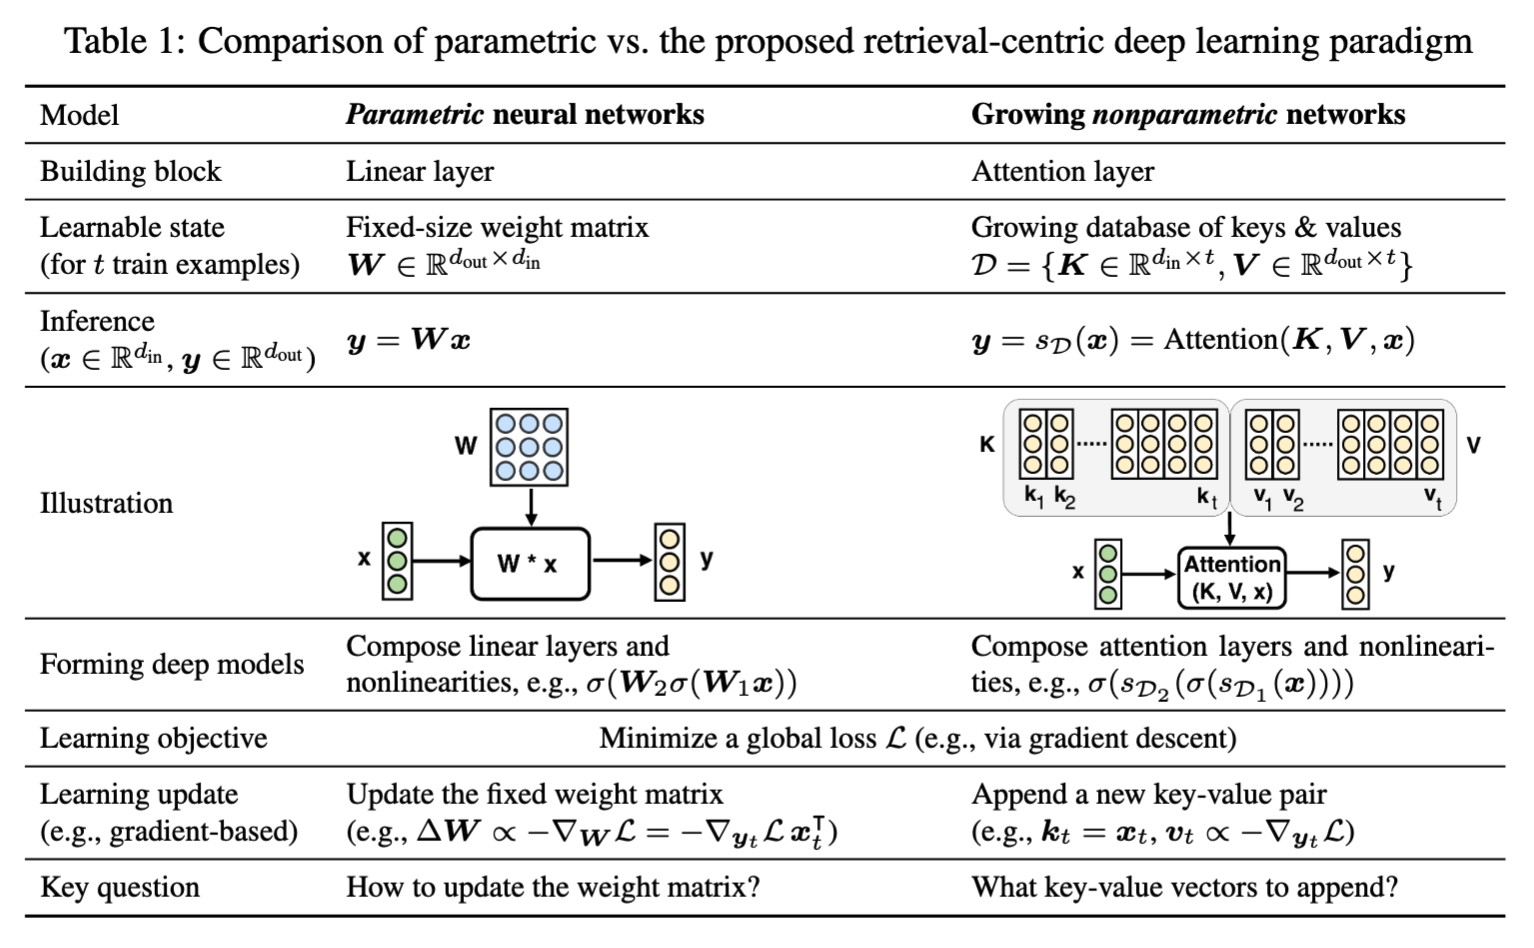






This interactive notebook accompanies our paper and demonstrates **single-epoch online learning on CIFAR-10** using growing nonparametric RCDL layers alongside parametric baselines.


In [ ]:
#@title 1. Setup & Dependencies
try:
  import flax
  import optax
  import tensorflow_datasets as tfds
except ImportError:
  !pip install -q jax jaxlib flax optax tensorflow-datasets matplotlib seaborn tqdm

import dataclasses as dc
import functools
import gc
import math
import time
from typing import Any, Dict, Optional, Tuple

import flax
import flax.linen as nn
from flax import traverse_util
from flax.training import train_state
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import optax
import tensorflow as tf
import tensorflow_datasets as tfds
from tqdm.auto import tqdm

# Paper Color Palette & Plot Aesthetics
METHOD_PALETTE = {
    "Mesa": "#f48fb1",
    "Delta": "#b692f4",
    "Muon": "#ffca28",
    "Weighted Softmax": "#1976D2",
    "RBF": "#a3c1e1",
    "AdamW": "#689f38",
    "Adam": "#9ccc65",
    "RMSprop": "#c5e1a5",
    "SGD": "#9E9E9E",
    "kNN": "#6610f2",
    "SVM": "#000000",
}


def style_paper_ax(
    ax: plt.Axes,
    fontsize_ticks: int = 13,
    linewidth_x: float = 1.5,
    linewidth_y: float = 1.5,
    show_grid: bool = False,
):
  """Applies the paper spine, tick, and grid aesthetic to a Matplotlib Axes."""
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  ax.spines["bottom"].set_linewidth(linewidth_x)
  ax.spines["left"].set_linewidth(linewidth_y)
  ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks)
  if show_grid:
    ax.grid(True, linestyle="--", alpha=0.5)
  else:
    ax.grid(False)


print(f"JAX version:  {jax.__version__}")
print(f"Flax version: {flax.__version__}")
print(f"Devices:      {jax.devices()}")


JAX version:  0.11.2
Flax version: 0.12.9
Devices:      [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


## 2. CIFAR-10 Data Pipeline

Loads CIFAR-10 (`50,000` training and `10,000` test images), flattens each image to $d_{\text{in}} = 3{,}072$ features, and standardizes per channel. During training, the model sees the `50,000` training images **once** in a single online pass (`1` epoch).


In [ ]:
#@title 2.1 Load & Standardize CIFAR-10

# Prevent TensorFlow from consuming GPU/TPU memory
tf.config.set_visible_devices([], 'GPU')

CIFAR_MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32).reshape(1, 1, 1, 3)
CIFAR_STD = np.array([0.2470, 0.2435, 0.2616], dtype=np.float32).reshape(1, 1, 1, 3)


def load_cifar10_tfds() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
  """Loads CIFAR-10 via TFDS into standardized flat float32 arrays."""
  print("Loading CIFAR-10 via TFDS...")
  train_ds = tfds.load('cifar10', split='train', shuffle_files=False,
                       as_supervised=True, batch_size=-1)
  test_ds = tfds.load('cifar10', split='test', shuffle_files=False,
                      as_supervised=True, batch_size=-1)

  train_images_np, train_labels_np = tfds.as_numpy(train_ds)
  test_images_np, test_labels_np = tfds.as_numpy(test_ds)

  train_x = (train_images_np.astype(np.float32) / 255.0 - CIFAR_MEAN) / CIFAR_STD
  test_x = (test_images_np.astype(np.float32) / 255.0 - CIFAR_MEAN) / CIFAR_STD

  train_x = train_x.reshape(train_x.shape[0], -1)
  test_x = test_x.reshape(test_x.shape[0], -1)
  return train_x, train_labels_np.astype(np.int32), test_x, test_labels_np.astype(np.int32)


train_images, train_labels, test_images, test_labels = load_cifar10_tfds()
print(f"Train images: {train_images.shape}, Labels: {train_labels.shape}")
print(f"Test images:  {test_images.shape}, Labels: {test_labels.shape}")

Loading CIFAR-10 via TFDS...
Train images: (50000, 3072), Labels: (50000,)
Test images:  (10000, 3072), Labels: (10000,)


## 3. Model Architecture

All models share the same residual-stream backbone: $L$ pre-norm residual blocks followed by a readout layer. In the ResNet-MLP baseline, each block is a standard feed-forward (FFN) layer acting on the RMS-normalized residual stream. The RCDL models replace these FFN layers (and the readout) with a *growing* layer that retrieves from a database $D = \{(w_j, \mathbf{k}_j, \tilde{\mathbf{v}}_j)\}_{j=1}^{N}$ of keys $\mathbf{k}_j \in \mathbb{R}^{d_{\text{in}}}$, weighted values $\tilde{\mathbf{v}}_j = w_j \mathbf{v}_j \in \mathbb{R}^{d_{\text{out}}}$, and scalar weights $w_j \ge 0$. For a query $\mathbf{q}$ (the normalized layer input), the **weighted softmax** models compute

$$z_j(\mathbf{q}) = \frac{\langle \mathbf{q}, \mathbf{k}_j \rangle}{T \sqrt{d_{\text{in}}}}, \qquad s_D(\mathbf{q}) = \frac{\sum_{j} \exp(z_j(\mathbf{q}))\, \tilde{\mathbf{v}}_j}{\sum_{m} w_m \exp(z_m(\mathbf{q}))},$$

with temperature $T$. The **Growing RBF** model instead uses an unnormalized Gaussian RBF kernel over a database $D = \{(\mathbf{k}_j, \mathbf{v}_j)\}_{j=1}^{N}$:

$$\phi_{\text{RBF}}(\mathbf{q}, \mathbf{k}_j) = \exp\!\left(-\frac{\lVert \mathbf{q} - \mathbf{k}_j \rVert_2^2}{2 T \sqrt{d_{\text{in}}}}\right), \qquad s_D(\mathbf{q}) = \sum_{j} \phi_{\text{RBF}}(\mathbf{q}, \mathbf{k}_j)\, \mathbf{v}_j .$$

The learning rules, i.e. how a new tuple $(w_t, \mathbf{k}_t, \tilde{\mathbf{v}}_t)$ is added for the current training data, are described in the corresponding sections below. You can train the following models in this notebook:


| Model | Core Mechanism | Database Growth | Parameter Updates |
| :--- | :--- | :--- | :--- |
| **Growing Weighted Softmax** | Weighted softmax attention; each new tuple is a (clipped) functional gradient step | One entry per training sample | Nonparametric (no backprop into the database) |
| **Gauge-Invariant Weighted Softmax** | Weighted softmax attention; gauge-invariant functional gradient step (strictly positive weights, no clipping) | One entry per training sample | Nonparametric (no backprop into the database) |
| **Growing RBF** | Unnormalized Gaussian RBF kernel attention | One entry per training sample | Nonparametric (no backprop into the database) |
| **Hybrid Growing Weighted Softmax** | Weighted softmax attention; only novel queries are added, all entries are refined by Adam | Sublinear (novel samples only) | Nonparametric growth + parametric (Adam) refinement |
| **Parametric Softmax** | Fixed-size weighted softmax table trained from random init | Fixed size (no growth) | Pure backpropagation (Adam) |
| **ResNet-MLP** | Standard dense residual network (`GELU`) | Fixed network width | Pure backpropagation (Adam) |

In [ ]:
#@title 3.1 Architecture, Kernels & Flax Modules

@dc.dataclass(frozen=True)
class RCDLConfig:
  """Unified configuration for 'gws', 'gauge', 'rbf', 'hybrid', 'parametric_softmax', and 'standard'."""
  # --- Architecture ---
  kernel_type: str = 'gws'           # 'gws' | 'gauge' | 'rbf' | 'hybrid' | 'parametric_softmax' | 'standard'
  hidden_dim: int = 3072
  num_layers: int = 2
  nonlinearity: str = 'none'         # 'none' | 'gelu' | 'relu'
  use_residual: bool = True
  use_post_norm: bool = False
  learn_norm_params: bool = False
  use_input_embedding: bool = False
  use_nndense_readout: bool = False
  # --- Attention & Database (paper notation in comments) ---
  temperature: float = 10.0          # T (softmax temperature; RBF temperature for 'rbf')
  db_size: int = 50016               # N: max. database size per layer = 50,000 (1 epoch) + 16 (D_0)
  full_epoch_capacity: int = 50016   # Reference 1-epoch capacity for % calculation
  # --- Growing layers ('gws', 'gauge', 'rbf', 'hybrid') ---
  eta: float = 0.03                  # η: weight learning rate ('gws'/'gauge'/'hybrid'); value learning rate for 'rbf'
  beta: float = 30.0                 # β: value learning rate ('gws'/'gauge'/'hybrid'); unused for 'rbf'
  model_momentum: float = 0.0
  model_weight_decay: float = 0.0
  init_pred_scale: float = 20.0
  add_activations: bool = False
  freeze_init_out: bool = True
  rbf_sliding_window: int = -1
  # --- Gauge-Invariant Weighted Softmax ('gauge') ---
  gauge_method: str = 'None'         # 'None' | 'normalized_v2' (= updates in the order of the gradient length)
  gauge_alpha: float = 1.0           # α: gauge parameter (α_t = α / ||g_t||)
  # --- Parametric Softmax ('parametric_softmax') Specific ---
  learn_parametric_weights: bool = True
  # --- Hybrid ('hybrid') Growth Control ---
  growth_trigger: str = 'distance'   # 'distance' | 'cost_regularized' | 'error_weighted' | 'always'
  growth_threshold: float = 50.0     # τ: growth threshold
  growth_penalty: float = 1.0
  growth_power: float = 2.0
  growth_loss_scale: float = 1.0
  # --- Data & Optimization ---
  num_classes: int = 10
  batch_size: int = 16
  optimizer: str = 'adam'            # 'adam' | 'adamw' | 'sgd' | 'rmsprop' | 'muon'
  weight_decay: float = 0.0
  learning_rate: float = 3e-4        # optimizer (e.g. Adam) learning rate for parametric parameters
  db_weights_lr: float = 0.0
  num_epochs: int = 1
  global_init_seed: int = 1


def weighted_attention(
    q: jax.Array,
    keys: jax.Array,
    values: jax.Array,
    weights: jax.Array,
    temperature: jax.Array,
    db_size: Optional[jax.Array] = None,
) -> Tuple[jax.Array, jax.Array]:
  """Weighted softmax attention over the database entries.

  Note: weights enter the denominator only; the numerator is unweighted exp_qk @ values,
  and similarity is divided by temperature * sqrt(d_k).
  """
  temperature = jnp.asarray(temperature)
  d_k = q.shape[-1]
  scaling = temperature * jnp.sqrt(d_k)
  logits_qk = jnp.matmul(q, keys.T) / scaling

  nonzero = jnp.any(keys != 0.0, axis=-1)
  nonzero = jnp.logical_or(nonzero, jnp.any(weights != 0.0, axis=-1))
  if db_size is not None:
    active = jnp.arange(keys.shape[0])[None, :] < db_size
    valid = jnp.logical_and(active, nonzero[None, :])
  else:
    valid = nonzero[None, :]

  logits_for_max = jnp.where(valid, logits_qk, -1e9)
  max_logit = jnp.max(logits_for_max, axis=-1, keepdims=True)
  exp_qk = jnp.exp(logits_for_max - max_logit)

  denom = jnp.sum(exp_qk * weights.T, axis=-1, keepdims=True)
  sign = jnp.sign(denom)
  sign = jnp.where(sign == 0, 1.0, sign)
  denom_safe = jnp.maximum(jnp.abs(denom), 1e-8) * sign
  numer = jnp.matmul(exp_qk, values)
  return numer / denom_safe, denom_safe


def rbf_attention(
    queries: jax.Array,
    keys: jax.Array,
    values: jax.Array,
    temperature: jax.Array,
) -> Tuple[jax.Array, jax.Array]:
  """Unnormalized Gaussian RBF kernel attention: exp(-||q - k||^2 / (2 T sqrt(d_in)))."""
  d_k = queries.shape[-1]
  scaling = jnp.sqrt(d_k) * (2.0 * temperature)
  x_sq = jnp.sum(jnp.square(queries), axis=-1, keepdims=True)
  k_sq = jnp.sum(jnp.square(keys), axis=-1)
  dot_prod = jnp.matmul(queries, keys.T)
  dist_sq = jnp.maximum(x_sq + k_sq - 2.0 * dot_prod, 0.0)
  rbf_weights = jnp.exp(-dist_sq / scaling)
  return jnp.matmul(rbf_weights, values), rbf_weights


def get_rbf_decay_mask(db_size: int, batch_size: int, current_idx: jax.Array,
                       momentum: float, weight_decay: float,
                       sliding_window: int = -1) -> jax.Array:
  """Age decay & optional sliding-window mask for 'gws'/'gauge' and 'rbf'."""
  t = jnp.arange(0, db_size)
  ages = (db_size - t) % db_size // batch_size
  ages = jnp.roll(ages, batch_size - 1)

  wd_mask = (jnp.power(1.0 - weight_decay, ages)
             if weight_decay > 0.0 else jnp.ones((db_size,), dtype=jnp.float32))
  if momentum > 0.0:
    denom = 1.0 - momentum + 1e-6
    ages_mom = jnp.roll(ages, batch_size)
    mom_term = (1.0 - jnp.power(momentum, ages_mom)) / denom
  else:
    mom_term = 1.0

  base_mask = jnp.roll(wd_mask * mom_term, -batch_size).reshape((db_size, 1)).astype(jnp.float32)
  current_mask = jnp.roll(base_mask, shift=current_idx, axis=0)

  if sliding_window != -1:
    dist = (current_idx - 1 - t) % db_size
    decay_len = sliding_window // 2
    window_mask = jnp.where(dist < sliding_window, 1.0, 0.0)
    cos_part = 0.5 + 0.5 * jnp.cos(jnp.pi * (dist - sliding_window) / decay_len)
    window_mask = jnp.where((dist >= sliding_window) & (dist < sliding_window + decay_len),
                            cos_part, window_mask)
    window_mask = jnp.where(dist >= sliding_window + decay_len, 0.0, window_mask)
    current_mask = current_mask * window_mask.reshape((db_size, 1))

  return current_mask


@functools.partial(jax.custom_vjp, nondiff_argnums=(7, 8, 9, 10, 11, 12, 13, 14))
def rcdl_tunnel_op(
    x, keys, values, weights, t_k, t_v, t_w,
    weight_lr, temperature, value_lr,
    data_batch_size, kernel_type, add_activations,
    gauge_method, gauge_alpha, db_size_f,
):
  """Unified custom-VJP gradient tunnel for 'gws', 'gauge', 'rbf', and 'hybrid'."""
  del t_k, t_v, t_w
  if kernel_type == 'rbf':
    y, _ = rbf_attention(x, keys, values, temperature)
  else:
    active_db = db_size_f if kernel_type == 'hybrid' else None
    y, _ = weighted_attention(x, keys, values, weights, temperature, active_db)
  return y


def _rcdl_tunnel_fwd(
    x, keys, values, weights, t_k, t_v, t_w,
    weight_lr, temperature, value_lr,
    data_batch_size, kernel_type, add_activations,
    gauge_method, gauge_alpha, db_size_f,
):
  del t_k, t_v, t_w
  if kernel_type == 'rbf':
    y, _ = rbf_attention(x, keys, values, temperature)
  else:
    active_db = db_size_f if kernel_type == 'hybrid' else None
    y, _ = weighted_attention(x, keys, values, weights, temperature, active_db)
  return y, (x, keys, values, weights, y, db_size_f)


def _rcdl_tunnel_bwd(
    weight_lr, temperature, value_lr,
    data_batch_size, kernel_type, add_activations,
    gauge_method, gauge_alpha, res, g_y,
):
  x, keys, values, weights, y, db_size_f = res

  if kernel_type == 'hybrid':
    def pure_wrapper(x_in, k_in, v_in, w_in):
      out, _ = weighted_attention(x_in, k_in, v_in, w_in, temperature, db_size_f)
      return out
    _, vjp_fn = jax.vjp(pure_wrapper, x, keys, values, weights)
    grad_x, grad_keys, grad_values, grad_weights = vjp_fn(g_y)
  elif kernel_type == 'rbf':
    def pure_wrapper(x_in):
      out, _ = rbf_attention(x_in, keys, values, temperature)
      return out
    _, vjp_fn = jax.vjp(pure_wrapper, x)
    (grad_x,) = vjp_fn(g_y)
    grad_keys = jnp.zeros_like(keys)
    grad_values = jnp.zeros_like(values)
    grad_weights = jnp.zeros_like(weights)
  else:
    def pure_wrapper(x_in):
      out, _ = weighted_attention(x_in, keys, values, weights, temperature)
      return out
    _, vjp_fn = jax.vjp(pure_wrapper, x)
    (grad_x,) = vjp_fn(g_y)
    grad_keys = jnp.zeros_like(keys)
    grad_values = jnp.zeros_like(values)
    grad_weights = jnp.zeros_like(weights)

  grad_k_cand = x

  if kernel_type == 'rbf':
    grad_v_cand = -1.0 * g_y * data_batch_size * value_lr
    if add_activations:
      grad_v_cand = grad_v_cand + y
    grad_w_cand = jnp.zeros((x.shape[0], 1), dtype=x.dtype)
  elif gauge_method in (None, 'None'):
    # Growing Weighted Softmax ('gws') & Hybrid Growing Weighted Softmax ('hybrid').
    # g_y is the gradient of the batch-MEAN loss, so B * g_y = g_t (per-sample gradient).
    #   ṽ_t = -β g_t,   w_t = max(0, η · clip(δ_t, -B, B)),   δ_t = <s_{t-1}, g_t>
    grad_v_cand = -1.0 * g_y * data_batch_size * value_lr
    eta_scaled = weight_lr * data_batch_size
    delta_over_b = jnp.clip(jnp.sum(y * g_y, axis=-1, keepdims=True), -1.0, 1.0)  # δ_t / B, clipped
    grad_w_cand = eta_scaled * delta_over_b
    grad_w_cand = jnp.where(grad_w_cand > 0, grad_w_cand, 0.0)
  elif gauge_method == 'normalized_v2':
    # Gauge-Invariant Weighted Softmax (updates in the order of the gradient length),
    # with virtual gauge b_t = (-<y, g_y>/||g_y||^2 + α/||g_y||) g_y.
    # NOTE: uses the batch-mean gradient g_y directly (no factor B).
    norm_g = jnp.linalg.norm(g_y, axis=-1, keepdims=True)
    delta = jnp.sum(y * g_y, axis=-1, keepdims=True)
    grad_w_cand = weight_lr * gauge_alpha * norm_g
    grad_v_cand = (
        -(weight_lr * (gauge_alpha ** 2) + value_lr)
        + weight_lr * gauge_alpha * delta / (norm_g + 1e-8)
    ) * g_y
  else:
    raise ValueError(f'Unsupported gauge method: {gauge_method}')

  return (
      grad_x, grad_keys, grad_values, grad_weights,
      grad_k_cand, grad_v_cand, grad_w_cand,
      jnp.zeros_like(db_size_f),
  )


rcdl_tunnel_op.defvjp(_rcdl_tunnel_fwd, _rcdl_tunnel_bwd)


class RCDLLayer(nn.Module):
  """Unified Flax module for 'gws', 'gauge', 'rbf', 'hybrid', and 'parametric_softmax' RCDL layers."""
  layer_id: int
  d_in: int
  features: int
  db_size: int
  eta: float                         # η (see RCDLConfig)
  kernel_type: str = 'gws'           # 'gws' | 'gauge' | 'rbf' | 'hybrid' | 'parametric_softmax'
  temperature: float = 10.0          # T
  beta: float = 30.0                 # β (see RCDLConfig)
  # Growing ('gws' & 'rbf') parameters
  momentum: float = 0.0
  weight_decay: float = 0.0
  init_pred_scale: float = 20.0
  add_activations: bool = False
  use_slow_weights: bool = False
  rbf_sliding_window: int = -1
  # Gauge-Invariant Weighted Softmax ('gauge') parameters
  gauge_method: str = 'None'         # 'None' | 'normalized_v2'
  gauge_alpha: float = 1.0           # α
  # Parametric Softmax ('parametric_softmax') parameters
  learn_parametric_weights: bool = True
  # Hybrid ('hybrid') growth parameters
  growth_trigger: str = 'distance'
  growth_threshold: float = 50.0     # τ: growth threshold
  growth_penalty: float = 1.0
  growth_power: float = 2.0
  growth_loss_scale: float = 1.0
  # Batch sizing
  expected_batch_size: int = 16
  true_batch_size: int = 16
  max_tunnel_size: Optional[int] = None

  @nn.compact
  def __call__(self, x, targets: Optional[jax.Array] = None):
    # --- Branch 0: Parametric Weighted Softmax ('parametric_softmax') ---
    if self.kernel_type == 'parametric_softmax':
      keys = self.param('keys', nn.initializers.lecun_normal(),
                        (self.db_size, self.d_in))
      values = self.param('values', nn.initializers.normal(stddev=0.02),
                          (self.db_size, self.features))
      if self.learn_parametric_weights:
        weights = self.param('weights', nn.initializers.ones, (self.db_size, 1))
      else:
        weights = jnp.ones((self.db_size, 1), dtype=jnp.float32)
      # Track static capacity in db_state for consistent reporting/plotting
      _ = self.variable(
          'db_state', 'db_size',
          lambda: jnp.array(self.db_size, dtype=jnp.int32))
      y, _ = weighted_attention(x, keys, values, weights, self.temperature)
      return y

    tunnel_size = (
        self.max_tunnel_size if self.max_tunnel_size is not None else x.shape[0]
    )

    values = self.param('values', nn.initializers.zeros, (self.db_size, self.features))
    keys = self.param('keys', nn.initializers.zeros, (self.db_size, self.d_in))

    def init_weights_singular(key, shape, dtype=jnp.float32):
      del key
      w = jnp.zeros(shape, dtype=dtype)
      return w.at[0:self.expected_batch_size].set(1.0 / self.expected_batch_size)

    weights = self.param('weights', init_weights_singular, (self.db_size, 1))
    bias = self.param('bias', nn.initializers.zeros, (self.features,))

    tunnel_keys = self.param('tunnel_keys', nn.initializers.zeros, (tunnel_size, self.d_in))
    tunnel_values = self.param('tunnel_values', nn.initializers.zeros, (tunnel_size, self.features))
    tunnel_weights = self.param('tunnel_weights', nn.initializers.zeros, (tunnel_size, 1))

    curr_b = x.shape[0]
    t_k = jax.lax.dynamic_slice(tunnel_keys, (0, 0), (curr_b, self.d_in))
    t_v = jax.lax.dynamic_slice(tunnel_values, (0, 0), (curr_b, self.features))
    t_w = jax.lax.dynamic_slice(tunnel_weights, (0, 0), (curr_b, 1))

    # --- Branch 1: Unnormalized RBF Kernel ('rbf') ----------------------------
    if self.kernel_type == 'rbf':
      db_idx_var = self.variable(
          'db_state', 'db_idx', lambda: jnp.array(0, dtype=jnp.int32))
      w_slow = None
      if self.use_slow_weights:
        init_key = jax.random.PRNGKey(self.layer_id * 42)
        w_slow = self.variable(
            'init_out', 'kernel',
            lambda key, shape: jax.random.normal(key, shape)
            / (math.sqrt(self.d_in) * self.init_pred_scale),
            init_key, (self.d_in, self.features),
        ).value

      current_mask = get_rbf_decay_mask(
          self.db_size, curr_b, db_idx_var.value,
          self.momentum, self.weight_decay, self.rbf_sliding_window)
      weighted_values = values * current_mask

      y_fast = rcdl_tunnel_op(
          x, keys, weighted_values, weights, t_k, t_v, t_w,
          self.eta, self.temperature, self.eta,
          curr_b, 'rbf', self.add_activations,
          'None', 1.0,
          jnp.array(-1.0, dtype=jnp.float32),
      )
      y_slow_val = (x @ w_slow) if self.use_slow_weights else 0.0
      y = y_slow_val + y_fast + bias - jax.lax.stop_gradient(bias)
      if self.is_mutable_collection('db_state'):
        db_idx_var.value = jnp.minimum(self.db_size, db_idx_var.value + curr_b)
      return y

    # --- Branch 2: Growing Weighted Softmax ('gws' & 'gauge') ----------
    if self.kernel_type in ('gws', 'gauge'):
      db_idx_var = self.variable(
          'db_state', 'db_idx',
          lambda: jnp.array(self.expected_batch_size, dtype=jnp.int32))
      current_mask = get_rbf_decay_mask(
          self.db_size, curr_b, db_idx_var.value,
          self.momentum, self.weight_decay, -1)
      weighted_values = values * current_mask

      eff_gauge_method = (
          'normalized_v2'
          if (self.kernel_type == 'gauge' and self.gauge_method in (None, 'None'))
          else self.gauge_method
      )
      y_fast = rcdl_tunnel_op(
          x, keys, weighted_values, weights, t_k, t_v, t_w,
          self.eta, self.temperature, self.beta,
          self.true_batch_size, self.kernel_type, False,
          eff_gauge_method, self.gauge_alpha,
          jnp.array(-1.0, dtype=jnp.float32),
      )
      y = y_fast + bias - jax.lax.stop_gradient(bias)
      if self.is_mutable_collection('db_state'):
        db_idx_var.value = jnp.minimum(self.db_size, db_idx_var.value + curr_b)
      return y

    # --- Branch 3: Hybrid Growing Weighted Softmax ('hybrid') -----------
    db_size_var = self.variable(
        'db_state', 'db_size',
        lambda: jnp.array(self.expected_batch_size, dtype=jnp.int32))
    old_size_var = self.variable(
        'db_state', 'old_db_size',
        lambda: jnp.array(self.expected_batch_size, dtype=jnp.int32))
    novel_var = self.variable(
        'db_state', 'is_novel',
        lambda: jnp.zeros((tunnel_size,), dtype=bool))

    y_fast = rcdl_tunnel_op(
        x, keys, values, weights, t_k, t_v, t_w,
        self.eta, self.temperature, self.beta,
        self.true_batch_size, 'hybrid', False,
        self.gauge_method, self.gauge_alpha,
        db_size_var.value.astype(jnp.float32),
    )
    y = y_fast + bias - jax.lax.stop_gradient(bias)

    if self.is_mutable_collection('db_state'):
      old_size_var.value = db_size_var.value
      active_mask = jnp.arange(self.db_size) < db_size_var.value

      x_sq = jnp.sum(x ** 2, axis=-1, keepdims=True)
      k_sq = jnp.sum(keys ** 2, axis=-1)[None, :]
      xk = jnp.matmul(x, keys.T)
      dists = jnp.sqrt(jnp.maximum(0.0, x_sq + k_sq - 2.0 * xk))
      dists = jnp.where(active_mask[None, :], dists, jnp.inf)
      min_dists = jnp.min(dists, axis=-1)

      capacity_ratio = db_size_var.value / float(self.db_size)
      penalised_threshold = self.growth_threshold * (
          1.0 + self.growth_penalty * (capacity_ratio ** self.growth_power))

      if self.growth_trigger == 'distance':
        is_novel = min_dists > self.growth_threshold
      elif self.growth_trigger == 'cost_regularized':
        is_novel = min_dists > penalised_threshold
      elif self.growth_trigger in ('error_weighted', 'loss_gated'):
        probs = jax.nn.softmax(y, axis=-1)
        log_probs = jax.nn.log_softmax(y, axis=-1)
        if targets is not None and targets.shape[0] == curr_b:
          one_hot = (jax.nn.one_hot(targets, y.shape[-1])
                     if targets.ndim == 1 else targets)
          sample_loss = -jnp.sum(one_hot * log_probs, axis=-1)
        else:
          sample_loss = -jnp.sum(probs * log_probs, axis=-1)
        score = min_dists * (1.0 + self.growth_loss_scale * sample_loss)
        is_novel = score > penalised_threshold
      elif self.growth_trigger == 'always':
        is_novel = jnp.ones((curr_b,), dtype=bool)
      else:
        is_novel = min_dists > self.growth_threshold

      is_novel_pad = jnp.zeros((tunnel_size,), dtype=bool).at[:curr_b].set(is_novel)
      novel_var.value = is_novel_pad
      num_novel = jnp.sum(is_novel_pad.astype(jnp.int32))
      db_size_var.value = jnp.minimum(self.db_size, old_size_var.value + num_novel)

    return y


def make_rcdl_layer_builder(cfg: RCDLConfig, db_size_override: Optional[int] = None):
  """Builds a layer for 'gws', 'gauge', 'rbf', 'hybrid', 'parametric_softmax', or 'standard'."""
  if cfg.kernel_type == 'standard':
    def _build_standard(layer_id: int, d_in: int, features: int, name: str):
      del layer_id, d_in
      return nn.Dense(features=features, use_bias=True, name=name)
    return _build_standard

  eff_db = db_size_override if db_size_override is not None else cfg.db_size
  return functools.partial(
      RCDLLayer,
      db_size=eff_db,
      eta=cfg.eta,
      kernel_type=cfg.kernel_type,
      temperature=cfg.temperature,
      beta=cfg.beta,
      momentum=cfg.model_momentum,
      weight_decay=cfg.model_weight_decay,
      init_pred_scale=cfg.init_pred_scale,
      add_activations=cfg.add_activations,
      use_slow_weights=(not cfg.freeze_init_out),
      rbf_sliding_window=cfg.rbf_sliding_window,
      gauge_method=cfg.gauge_method,
      gauge_alpha=cfg.gauge_alpha,
      learn_parametric_weights=cfg.learn_parametric_weights,
      growth_trigger=cfg.growth_trigger,
      growth_threshold=cfg.growth_threshold,
      growth_penalty=cfg.growth_penalty,
      growth_power=cfg.growth_power,
      growth_loss_scale=cfg.growth_loss_scale,
      expected_batch_size=cfg.batch_size,
      true_batch_size=cfg.batch_size,
      max_tunnel_size=cfg.batch_size,
  )


def get_activation_fn(name: str):
  if name == 'gelu':
    return jax.nn.gelu
  if name == 'relu':
    return jax.nn.relu
  return lambda v: v


class CifarRCDLClassifier(nn.Module):
  """Stacked residual classifier supporting all RCDL layers, Parametric Softmax, and standard dense (ResNet-MLP) layers."""
  cfg: RCDLConfig
  db_size: Optional[int] = None

  @nn.compact
  def __call__(self, x, training: bool = False):
    del training
    cfg = self.cfg
    x = x.reshape((x.shape[0], -1))
    hidden_dim = cfg.hidden_dim

    layer_builder = make_rcdl_layer_builder(cfg, db_size_override=self.db_size)
    norm_builder = functools.partial(nn.RMSNorm, use_scale=cfg.learn_norm_params)
    act_fn = get_activation_fn(cfg.nonlinearity)

    for i in range(cfg.num_layers):
      residual = x
      x_in = norm_builder(name=f'norm_{i}')(x)
      y = layer_builder(layer_id=i, d_in=hidden_dim, features=hidden_dim,
                        name=f'layer_{i}')(x_in)
      if cfg.use_post_norm:
        y = norm_builder(name=f'out_norm_{i}')(y)
      y = act_fn(y)
      x = residual + y if cfg.use_residual else y

    x = norm_builder(name='norm_final')(x)
    if cfg.use_nndense_readout or cfg.kernel_type == 'standard':
      return nn.Dense(features=cfg.num_classes, name='output_layer')(x)
    return layer_builder(layer_id=cfg.num_layers, d_in=hidden_dim,
                         features=cfg.num_classes, name='output_layer')(x)


print("3.1 ready: RCDLConfig, weighted_attention, rbf_attention, rcdl_tunnel_op, RCDLLayer, CifarRCDLClassifier")


3.1 ready: RCDLConfig, weighted_attention, rbf_attention, rcdl_tunnel_op, RCDLLayer, CifarRCDLClassifier


## 4. Online Training Loop & State Management

To implement nonparametric database growth inside standard JAX automatic differentiation, each RCDL layer uses a custom vector-Jacobian product (`custom_vjp`):
- **Forward pass:** Computes the retrieval output $s_D(\mathbf{q})$ over the currently stored entries.
- **Backward pass:** Propagates the input gradient $\nabla_{\mathbf{q}} \ell$ to earlier layers while computing the new tuples $(w_t, \mathbf{k}_t, \tilde{\mathbf{v}}_t)$ from the query $\mathbf{q}_t$, the current prediction $s_{t-1} = s_D(\mathbf{q}_t)$, and the output gradient $g_t = \nabla_{s} \ell$. These tuples are appended to the database at the end of the step.

**Gradient scaling.** JAX differentiates the *batch-mean* loss, so the output gradient available in the code (`g_y`) is $\bar g_t = g_t / B$, where $g_t$ is the per-sample gradient and $B$ is the batch size.

In [ ]:
#@title 4.1 TrainState, Optimizer & 1-Epoch Online Runner

def create_rcdl_tx(params, cfg: RCDLConfig):
  """Creates the optimizer for 'gws', 'gauge', 'rbf', 'hybrid', 'parametric_softmax', or 'standard'."""
  is_parametric_db = cfg.kernel_type in ('hybrid', 'parametric_softmax')
  flat_labels = {}
  for path in traverse_util.flatten_dict(params):
    key_str = path[-1]
    if 'keys' in key_str or 'values' in key_str or 'weights' in key_str:
      if 'tunnel' in key_str:
        flat_labels[path] = 'tunnels'
      elif 'weights' in key_str and cfg.db_weights_lr > 0.0:
        flat_labels[path] = 'db_weights'
      else:
        flat_labels[path] = 'database'
    else:
      flat_labels[path] = 'standard'

  opt_name = cfg.optimizer.lower()
  if opt_name == 'adamw':
    base_opt = optax.adamw(cfg.learning_rate, weight_decay=cfg.weight_decay)
  elif opt_name == 'sgd':
    base_opt = optax.sgd(cfg.learning_rate, momentum=cfg.model_momentum)
  elif opt_name == 'rmsprop':
    base_opt = optax.rmsprop(cfg.learning_rate)
  elif opt_name == 'muon':
    if hasattr(optax, 'contrib') and hasattr(optax.contrib, 'muon'):
      base_opt = optax.contrib.muon(cfg.learning_rate, weight_decay=cfg.weight_decay)
    else:
      raise ValueError('optax.contrib.muon requires a newer version of Optax.')
  else:
    base_opt = optax.adam(cfg.learning_rate)

  transforms = {
      'standard': base_opt,
      'tunnels': optax.identity(),
      'database': base_opt if is_parametric_db else optax.set_to_zero(),
  }
  if cfg.db_weights_lr > 0.0:
    transforms['db_weights'] = optax.adam(cfg.db_weights_lr)

  return optax.multi_transform(
      transforms, traverse_util.unflatten_dict(flat_labels))


class RCDLTrainState(train_state.TrainState):
  """Unified TrainState handling ring-buffer, distance-gated, and purely parametric updates."""
  model_state: Any = None

  def apply_gradients(self, *, grads, batch_size=None, db_state=None, **kwargs):
    if batch_size is None:
      raise ValueError('batch_size required for RCDLTrainState')
    if db_state is None:
      db_state = self.model_state.get('db_state', {})

    updates, new_opt_state = self.tx.update(
        flax.core.unfreeze(grads), self.opt_state,
        flax.core.unfreeze(self.params))
    new_params = optax.apply_updates(flax.core.unfreeze(self.params), updates)
    pre_db_state = self.model_state.get('db_state', {})

    def recursive_scatter(p_dict, u_dict, s_pre, s_post):
      if 'tunnel_keys' in p_dict and 'tunnel_keys' in u_dict:
        fresh_keys = u_dict['tunnel_keys']
        fresh_vals = u_dict['tunnel_values']
        capacity = p_dict['keys'].shape[0]
        eff_b = fresh_keys.shape[0]

        if 'is_novel' in s_post:
          old_size = s_post['old_db_size']
          new_size = s_post['db_size']
          num_added = new_size - old_size
          sort_idx = jnp.argsort(~s_post['is_novel'])
          packed_k = fresh_keys[sort_idx]
          packed_v = fresh_vals[sort_idx]

          update_indices = (jnp.arange(eff_b) + old_size) % capacity
          write_mask = jnp.arange(eff_b)[:, None] < num_added

          existing_k = p_dict['keys'][update_indices]
          p_dict['keys'] = p_dict['keys'].at[update_indices].set(
              jnp.where(write_mask, packed_k[:eff_b], existing_k))
          existing_v = p_dict['values'][update_indices]
          p_dict['values'] = p_dict['values'].at[update_indices].set(
              jnp.where(write_mask, packed_v[:eff_b], existing_v))

          if 'tunnel_weights' in p_dict and 'tunnel_weights' in u_dict:
            packed_w = u_dict['tunnel_weights'][sort_idx]
            existing_w = p_dict['weights'][update_indices]
            p_dict['weights'] = p_dict['weights'].at[update_indices].set(
                jnp.where(write_mask, packed_w[:eff_b], existing_w))
        else:
          write_idx = s_pre['db_idx']
          update_indices = (jnp.arange(eff_b) + write_idx) % capacity
          p_dict['keys'] = p_dict['keys'].at[update_indices].set(fresh_keys[:eff_b])
          p_dict['values'] = p_dict['values'].at[update_indices].set(fresh_vals[:eff_b])
          if 'tunnel_weights' in p_dict and 'tunnel_weights' in u_dict:
            p_dict['weights'] = p_dict['weights'].at[update_indices].set(
                u_dict['tunnel_weights'][:eff_b])

        p_dict['tunnel_keys'] = jnp.zeros_like(p_dict['tunnel_keys'])
        p_dict['tunnel_values'] = jnp.zeros_like(p_dict['tunnel_values'])
        if 'tunnel_weights' in p_dict:
          p_dict['tunnel_weights'] = jnp.zeros_like(p_dict['tunnel_weights'])

      for k, v in p_dict.items():
        if isinstance(v, (dict, flax.core.FrozenDict)) and k in u_dict:
          recursive_scatter(v, u_dict[k], s_pre.get(k, {}), s_post.get(k, {}))

    recursive_scatter(new_params, updates, pre_db_state, db_state)
    return self.replace(params=new_params, opt_state=new_opt_state,
                        step=self.step + 1)


def create_rcdl_state(rng, cfg: RCDLConfig, input_shape, real_db_size: int):
  """Initializes model parameters and databases ('gws', 'gauge', 'rbf', 'hybrid', 'parametric_softmax', 'standard')."""
  batch_size = input_shape[0]
  rng, init_rng = jax.random.split(rng)

  if cfg.kernel_type == 'standard':
    model = CifarRCDLClassifier(cfg=cfg)
    variables = flax.core.unfreeze(model.init(init_rng, jnp.ones(input_shape)))
    params = variables['params']
    return RCDLTrainState.create(
        apply_fn=model.apply,
        params=params,
        tx=create_rcdl_tx(params, cfg),
        model_state={'db_state': {}},
    )

  proxy_db = 8 if cfg.kernel_type == 'parametric_softmax' else batch_size
  model = CifarRCDLClassifier(cfg=cfg, db_size=proxy_db)
  variables = flax.core.unfreeze(model.init(init_rng, jnp.ones(input_shape)))
  params = variables['params']
  db_state = variables.get('db_state', {})
  init_out = variables.get('init_out', {})

  def recursive_patch(p_dict, s_dict, rng_key):
    if 'keys' in p_dict and 'values' in p_dict:
      d_in = p_dict['keys'].shape[1]
      features = p_dict['values'].shape[1]

      if cfg.kernel_type == 'parametric_softmax':
        # LeCun normal keys, Normal(0, 0.02) values, and unit weights across all real_db_size entries.
        rng_key, k_key, v_key = jax.random.split(rng_key, 3)
        p_dict['keys'] = (
            jax.random.normal(k_key, (real_db_size, d_in), dtype=jnp.float32)
            / jnp.sqrt(float(d_in))
        )
        p_dict['values'] = (
            jax.random.normal(v_key, (real_db_size, features), dtype=jnp.float32)
            * 0.02
        )
        if 'weights' in p_dict:
          p_dict['weights'] = jnp.ones((real_db_size, 1), dtype=jnp.float32)
        if 'db_size' in s_dict:
          s_dict['db_size'] = jnp.array(real_db_size, dtype=jnp.int32)
      elif cfg.kernel_type in ('gws', 'gauge', 'hybrid'):
        layer_eff_bs = p_dict['keys'].shape[0]
        layer_real_db_size = int(layer_eff_bs * (real_db_size / batch_size))
        rng_key, k_key, v_key = jax.random.split(rng_key, 3)

        init_keys = jax.random.normal(k_key, (layer_eff_bs, d_in))
        init_keys = init_keys / jnp.sqrt(
            jnp.mean(init_keys ** 2, axis=-1, keepdims=True) + 1e-6)
        p_dict['keys'] = jnp.zeros((layer_real_db_size, d_in), jnp.float32
                                   ).at[:layer_eff_bs].set(init_keys)

        init_values = jax.random.normal(v_key, (layer_eff_bs, features))
        init_values = init_values / jnp.sqrt(
            jnp.mean(init_values ** 2, axis=-1, keepdims=True) + 1e-6)
        p_dict['values'] = jnp.zeros((layer_real_db_size, features), jnp.float32
                                     ).at[:layer_eff_bs].set(init_values)

        if 'weights' in p_dict:
          p_dict['weights'] = jnp.zeros((layer_real_db_size, 1), jnp.float32
                                        ).at[:layer_eff_bs].set(1.0 / batch_size)

        if 'db_idx' in s_dict:
          s_dict['db_idx'] = jnp.array(layer_eff_bs, dtype=jnp.int32)
        if 'db_size' in s_dict:
          s_dict['db_size'] = jnp.array(layer_eff_bs, dtype=jnp.int32)
        if 'old_db_size' in s_dict:
          s_dict['old_db_size'] = jnp.array(layer_eff_bs, dtype=jnp.int32)
      else:
        layer_eff_bs = p_dict['keys'].shape[0]
        layer_real_db_size = int(layer_eff_bs * (real_db_size / batch_size))
        p_dict['keys'] = jnp.zeros((layer_real_db_size, d_in), jnp.float32)
        p_dict['values'] = jnp.zeros((layer_real_db_size, features), jnp.float32)
        if 'weights' in p_dict:
          p_dict['weights'] = jnp.zeros((layer_real_db_size, 1), jnp.float32)
        if 'db_idx' in s_dict:
          s_dict['db_idx'] = jnp.array(0, dtype=jnp.int32)

    for k, v in p_dict.items():
      if isinstance(v, (dict, flax.core.FrozenDict)):
        rng_key = recursive_patch(v, s_dict.get(k, {}), rng_key)
    return rng_key

  recursive_patch(params, db_state, rng)

  model_state = {'db_state': db_state}
  if init_out:
    model_state['init_out'] = init_out

  return RCDLTrainState.create(
      apply_fn=CifarRCDLClassifier(cfg=cfg).apply,
      params=params,
      tx=create_rcdl_tx(params, cfg),
      model_state=model_state,
  )


@functools.partial(jax.jit, donate_argnums=(0,))
def rcdl_train_step(state: RCDLTrainState, images: jax.Array, labels: jax.Array):
  """Single online training step for all RCDL models and baselines."""
  def loss_wrapper(params):
    variables = {'params': params}
    variables.update(state.model_state)
    logits, new_mutable_state = state.apply_fn(
        variables, images, training=True, mutable=['db_state'])
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()
    return loss, (new_mutable_state, logits)

  (loss, (new_mutable_state, logits)), grads = jax.value_and_grad(
      loss_wrapper, has_aux=True)(state.params)

  new_state = state.apply_gradients(
      grads=grads,
      batch_size=images.shape[0],
      db_state=new_mutable_state.get('db_state', {}),
  )
  updated_model_state = dict(state.model_state)
  updated_model_state['db_state'] = new_mutable_state.get('db_state', {})
  new_state = new_state.replace(model_state=updated_model_state)
  acc = jnp.mean(jnp.argmax(logits, -1) == labels)
  return new_state, loss, acc


@jax.jit
def rcdl_eval_step(state: RCDLTrainState, images: jax.Array, labels: jax.Array):
  """Evaluation step without mutating db_state."""
  variables = {'params': state.params}
  variables.update(state.model_state)
  logits = state.apply_fn(variables, images, training=False)
  loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()
  acc = jnp.mean(jnp.argmax(logits, -1) == labels)
  return loss, acc


def rcdl_evaluate(state: RCDLTrainState, images: np.ndarray, labels: np.ndarray,
                 batch_size: int) -> Tuple[float, float]:
  steps = images.shape[0] // batch_size
  total_loss, total_acc = 0.0, 0.0
  for i in range(steps):
    sl = slice(i * batch_size, (i + 1) * batch_size)
    loss, acc = rcdl_eval_step(state, jnp.asarray(images[sl]), jnp.asarray(labels[sl]))
    total_loss += float(loss)
    total_acc += float(acc)
  return total_loss / steps, total_acc / steps


def get_per_layer_db_sizes(state: RCDLTrainState, cfg: RCDLConfig,
                           has_mem_readout: bool = True) -> Dict[str, int]:
  """Returns database sizes (stored entries) / layer width per layer (hidden_dim for 'standard' dense layers)."""
  out = {}
  db_state = state.model_state.get('db_state', {})
  for k, v in db_state.items():
    if isinstance(v, (dict, flax.core.FrozenDict)):
      if 'db_size' in v:
        out[k] = int(v['db_size'])
      elif 'db_idx' in v:
        out[k] = int(v['db_idx'])
  if not out:
    # For standard Dense layers, each hidden layer has `cfg.hidden_dim` (3,072) basis units (width)
    for i in range(cfg.num_layers):
      out[f'layer_{i}'] = int(cfg.hidden_dim)
    if has_mem_readout:
      out['output_layer'] = int(cfg.num_classes)
  return out


def run_rcdl_experiment(cfg: RCDLConfig, eval_every: int = 250,
                       progress: bool = True) -> Dict[str, Any]:
  """Unified 1-epoch online CIFAR-10 runner ('gws', 'gauge', 'rbf', 'hybrid', 'parametric_softmax', 'standard')."""
  rng = jax.random.PRNGKey(cfg.global_init_seed)
  rng, state_rng = jax.random.split(rng)

  num_train = train_images.shape[0]
  steps_per_epoch = num_train // cfg.batch_size
  total_steps = steps_per_epoch * cfg.num_epochs
  ref_cap = cfg.full_epoch_capacity if cfg.kernel_type == 'parametric_softmax' else cfg.db_size

  is_gauge = (
      cfg.kernel_type == 'gauge'
      or cfg.gauge_method not in (None, 'None')
  )
  eff_gauge_method = (
      'normalized_v2'
      if (cfg.kernel_type == 'gauge' and cfg.gauge_method in (None, 'None'))
      else cfg.gauge_method
  )

  print('=' * 72)
  if cfg.kernel_type == 'hybrid':
    print(f'Hybrid Growing Weighted Softmax | L={cfg.num_layers} residual blocks (+ readout) | '
          f'hidden={cfg.hidden_dim} | capacity={cfg.db_size:,} | '
          f'learn_norm={cfg.learn_norm_params}')
    print(f'trigger={cfg.growth_trigger!r} threshold={cfg.growth_threshold} '
          f'η={cfg.eta} β={cfg.beta}')
    print(f'T={cfg.temperature} Adam lr={cfg.learning_rate} '
          f'B={cfg.batch_size} seed={cfg.global_init_seed}')
  elif cfg.kernel_type == 'rbf':
    print(f'Growing RBF | L={cfg.num_layers} residual blocks (+ readout) | '
          f'hidden={cfg.hidden_dim} | db_size={cfg.db_size:,}')
    print(f'T={cfg.temperature} η={cfg.eta} '
          f'init_pred_scale={cfg.init_pred_scale} momentum={cfg.model_momentum} '
          f'batch={cfg.batch_size} seed={cfg.global_init_seed}')
  elif cfg.kernel_type == 'parametric_softmax':
    pct_cap = 100.0 * cfg.db_size / ref_cap
    print(f'Stacked Parametric Softmax | layers={cfg.num_layers} (+1 readout) | '
          f'hidden={cfg.hidden_dim} | N={cfg.db_size:,} ({pct_cap:.1f}% of 1-epoch cap)')
    print(f'T={cfg.temperature} optimizer={cfg.optimizer} '
          f'lr={cfg.learning_rate} learn_weights={cfg.learn_parametric_weights} '
          f'batch={cfg.batch_size} seed={cfg.global_init_seed}')
  elif cfg.kernel_type == 'standard':
    print(f'ResNet-MLP | L={cfg.num_layers} residual blocks (+ readout) | '
          f'hidden={cfg.hidden_dim} | activation={cfg.nonlinearity!r}')
    print(f'optimizer={cfg.optimizer} lr={cfg.learning_rate} '
          f'momentum={cfg.model_momentum} weight_decay={cfg.weight_decay} '
          f'batch={cfg.batch_size} seed={cfg.global_init_seed}')
  elif is_gauge:
    print(f'Gauge-Invariant Weighted Softmax | L={cfg.num_layers} residual blocks (+ readout) | '
          f'hidden={cfg.hidden_dim} | db_size={cfg.db_size:,}')
    print(f'gauge_method={eff_gauge_method!r} α={cfg.gauge_alpha} '
          f'η={cfg.eta} β={cfg.beta}')
    print(f'T={cfg.temperature} momentum={cfg.model_momentum} '
          f'batch={cfg.batch_size} seed={cfg.global_init_seed}')
  else:
    print(f'Growing Weighted Softmax | L={cfg.num_layers} residual blocks (+ readout) | '
          f'hidden={cfg.hidden_dim} | db_size={cfg.db_size:,}')
    print(f'T={cfg.temperature} η={cfg.eta} β={cfg.beta} '
          f'momentum={cfg.model_momentum} '
          f'batch={cfg.batch_size} seed={cfg.global_init_seed}')

  if cfg.kernel_type == 'standard':
    param_bytes = (cfg.num_layers * cfg.hidden_dim * cfg.hidden_dim
                   + cfg.hidden_dim * cfg.num_classes) * 4 / 1e9
    print(f'dense parameters ~{param_bytes:.2f} GB of float32 weights (fixed layer width={cfg.hidden_dim:,} = {100.0*cfg.hidden_dim/ref_cap:.1f}% cap)')
  else:
    mem_gb = (cfg.num_layers * cfg.db_size * cfg.hidden_dim * 2
              + cfg.db_size * (cfg.hidden_dim + cfg.num_classes)) * 4 / 1e9
    print(f'database ~{mem_gb:.2f} GB of float32 parameters')
  print('=' * 72)

  state = create_rcdl_state(
      state_rng, cfg, (cfg.batch_size, cfg.hidden_dim), real_db_size=cfg.db_size)

  has_mem_readout = not (cfg.use_nndense_readout or cfg.kernel_type == 'standard')
  layer_names = [f'layer_{i}' for i in range(cfg.num_layers)]
  if has_mem_readout:
    layer_names.append('output_layer')
  num_mem_layers = max(1, len(layer_names))
  total_full_cap = num_mem_layers * ref_cap

  history = {
      'steps': [], 'samples': [], 'train_losses': [], 'train_accuracies': [],
      'test_steps': [], 'test_samples': [], 'test_losses': [],
      'test_accuracies': [], 'db_sizes': [],
      'total_entries': [], 'total_full_capacity': total_full_cap,
      'per_layer_db_sizes': {k: [] for k in layer_names},
  }

  init_loss, init_acc = rcdl_evaluate(state, test_images, test_labels, cfg.batch_size)
  init_dbs = get_per_layer_db_sizes(state, cfg, has_mem_readout)
  init_total_active = sum(init_dbs[k] for k in layer_names)
  history['test_steps'].append(0)
  history['test_samples'].append(0)
  history['test_losses'].append(init_loss)
  history['test_accuracies'].append(init_acc)
  print(f'Initial Eval: Loss={init_loss:.4f}, Accuracy={init_acc:.4f}, '
        f'Capacity={init_total_active:,}/{total_full_cap:,} '
        f'({100.0 * init_total_active / total_full_cap:.1f}%)')

  start_time = time.time()
  step = 0
  order_key = jax.random.PRNGKey(cfg.global_init_seed)

  for epoch in range(cfg.num_epochs):
    perm = np.asarray(
        jax.random.permutation(jax.random.fold_in(order_key, epoch + 1), num_train))
    epoch_imgs = train_images[perm]
    epoch_lbls = train_labels[perm]

    iterator = range(steps_per_epoch)
    if progress:
      iterator = tqdm(iterator, desc=f'Epoch {epoch + 1}/{cfg.num_epochs}')

    for batch_idx in iterator:
      sl = slice(batch_idx * cfg.batch_size, (batch_idx + 1) * cfg.batch_size)
      bx = jnp.asarray(epoch_imgs[sl])
      by = jnp.asarray(epoch_lbls[sl])

      state, loss, acc = rcdl_train_step(state, bx, by)

      step += 1
      samples_seen = step * cfg.batch_size
      per_layer_now = get_per_layer_db_sizes(state, cfg, has_mem_readout)
      total_active_now = sum(per_layer_now[k] for k in layer_names)

      history['steps'].append(step)
      history['samples'].append(samples_seen)
      history['train_losses'].append(float(loss))
      history['train_accuracies'].append(float(acc))
      history['db_sizes'].append(total_active_now)
      history['total_entries'].append(total_active_now)
      for k in layer_names:
        history['per_layer_db_sizes'][k].append(per_layer_now[k])

      if progress:
        iterator.set_postfix({
            'Loss': f'{float(loss):.3f}',
            'Acc': f'{float(acc) * 100:.1f}%',
            'Cap': f'{100.0 * total_active_now / total_full_cap:.1f}%',
        })

      if step % eval_every == 0 or step == total_steps:
        test_loss, test_acc = rcdl_evaluate(
            state, test_images, test_labels, cfg.batch_size)
        history['test_steps'].append(step)
        history['test_samples'].append(samples_seen)
        history['test_losses'].append(test_loss)
        history['test_accuracies'].append(test_acc)
        print(f'Eval at {samples_seen:,} samples: Loss={test_loss:.4f}, '
              f'Accuracy={test_acc:.4f}, Capacity={total_active_now:,}/{total_full_cap:,} '
              f'({100.0 * total_active_now / total_full_cap:.1f}%)')

  elapsed = time.time() - start_time
  final_test_acc = history['test_accuracies'][-1]
  final_dbs = get_per_layer_db_sizes(state, cfg, has_mem_readout)
  final_total_active = sum(final_dbs[k] for k in layer_names)
  print(f'\n--> Finished in {elapsed:.1f}s | Final Test Accuracy: '
        f'{final_test_acc * 100:.2f}%')
  print(f'    Total Capacity: {final_total_active:,} / {total_full_cap:,} entries '
        f'({100.0 * final_total_active / total_full_cap:.2f}% of full capacity)\n')

  model_tag = (
      f'rcdl_gauge_{eff_gauge_method}_L{cfg.num_layers}'
      if is_gauge
      else f'rcdl_{cfg.kernel_type}_L{cfg.num_layers}'
  )
  return {
      'model_type': model_tag,
      'cfg': cfg,
      'history': history,
      'final_test_acc': final_test_acc,
      'final_db_size': final_total_active,
      'total_full_capacity': total_full_cap,
      'per_layer_db': final_dbs,
      'elapsed': elapsed,
      'state': state,
  }


def _get_method_color_and_title(cfg: RCDLConfig) -> Tuple[str, str]:
  ref_cap = cfg.full_epoch_capacity if cfg.kernel_type == 'parametric_softmax' else cfg.db_size
  is_gauge = (
      cfg.kernel_type == 'gauge'
      or cfg.gauge_method not in (None, 'None')
  )
  if cfg.kernel_type == 'hybrid':
    return '#f48fb1', f'Hybrid Growing Weighted Softmax (τ={cfg.growth_threshold:g})'
  elif cfg.kernel_type == 'rbf':
    return '#a3c1e1', f'Growing RBF (T={cfg.temperature:g})'
  elif cfg.kernel_type == 'parametric_softmax':
    pct = 100.0 * cfg.db_size / ref_cap
    col = '#ffca28' if pct < 50.0 else '#6610f2'
    return col, f'Parametric Softmax ({pct:.0f}% Cap)'
  elif cfg.kernel_type == 'standard':
    opt_colors = {
        'adam': '#9ccc65',
        'adamw': '#689f38',
        'rmsprop': '#c5e1a5',
        'sgd': '#9E9E9E',
        'muon': '#ffca28',
    }
    col = opt_colors.get(cfg.optimizer.lower(), '#9ccc65')
    return col, f'ResNet-MLP ({cfg.num_layers}L {cfg.nonlinearity.upper()}, {cfg.optimizer.upper()})'
  elif is_gauge:
    return '#b692f4', 'Gauge-Invariant Weighted Softmax'
  else:
    return '#1976D2', 'Growing Weighted Softmax'


def plot_rcdl_result(res: Dict[str, Any]):
  """Plots the overall capacity (database size) and CIFAR-10 test accuracy in the paper style with legends underneath."""
  import matplotlib.ticker as mtick
  cfg = res['cfg']
  h = res['history']
  samples = np.asarray(h['samples'])
  ts = np.asarray(h['test_samples'])
  acc = np.asarray(h['test_accuracies']) * 100.0
  ref_cap = cfg.full_epoch_capacity if cfg.kernel_type == 'parametric_softmax' else cfg.db_size

  per_layer_dict = h.get('per_layer_db_sizes', {})
  if per_layer_dict:
    num_l = len(per_layer_dict)
    total_active = np.sum([np.asarray(v, dtype=np.float64) for v in per_layer_dict.values()], axis=0)
    total_full_cap = float(num_l * ref_cap)
  else:
    num_l = 1
    total_active = np.asarray(h['db_sizes'], dtype=np.float64)
    total_full_cap = float(h.get('total_full_capacity', ref_cap))

  col, title_tag = _get_method_color_and_title(cfg)
  fig, (ax_mem, ax_acc) = plt.subplots(1, 2, figsize=(13.5, 5.2))

  init_offset = num_l * (cfg.batch_size if cfg.kernel_type not in ('rbf', 'standard') else 0)
  linear_stream = np.minimum(total_full_cap, num_l * samples + init_offset)
  ax_mem.plot(samples, linear_stream, ls='--', lw=1.8, color='#9E9E9E', alpha=0.75,
              label=f'One entry per sample (N = {int(total_full_cap):,})')
  ax_mem.plot(samples, total_active, ls='-', lw=3.5, color=col, alpha=0.9,
              label=f'Stored: {int(total_active[-1]):,} / {int(total_full_cap):,} ({total_active[-1]/total_full_cap:.1%})')

  ax_mem.set_title(f'{title_tag}: Capacity', fontsize=16, pad=10)
  ax_mem.set_xlabel('Samples', fontsize=15)
  ax_mem.set_ylabel('Database size (entries)', fontsize=15)
  ax_mem.set_xlim(0, 50000)
  ax_mem.set_ylim(0, total_full_cap * 1.05)

  ax_acc.plot(ts, acc, ls='-', lw=3.5, color=col, alpha=0.9,
              label=f'{title_tag} (Final: {acc[-1]:.2f}%)')
  ax_acc.set_title('CIFAR-10 Test Accuracy', fontsize=16, pad=10)
  ax_acc.set_xlabel('Samples', fontsize=15)
  ax_acc.set_ylabel('Test Accuracy', fontsize=15)
  ax_acc.set_xlim(0, 50000)
  ax_acc.set_ylim(10.0, None)
  ax_acc.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))

  for ax in (ax_mem, ax_acc):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.grid(False)
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.20),
        frameon=False,
        fontsize=11.5,
        handlelength=2.4,
    )

  plt.tight_layout(rect=[0.0, 0.14, 1.0, 1.0])
  plt.show()
  return fig


print("4.1 ready: RCDLTrainState, create_rcdl_state, run_rcdl_experiment, plot_rcdl_result")


4.1 ready: RCDLTrainState, create_rcdl_state, run_rcdl_experiment, plot_rcdl_result


## 5. Experiment 1: Growing Weighted Softmax

In the **Growing Weighted Softmax**, stored keys, weighted values, and weights are never updated by gradient descent. Instead, each incoming query $\mathbf{q}_t$ adds a new tuple to the layer's database, computed from the current prediction $s_{t-1}$ and the per-sample output gradient $g_t$:

$$\mathbf{k}_t = \mathbf{q}_t, \qquad \tilde{\mathbf{v}}_t = -\beta\, g_t, \qquad w_t = \max\!\big\{0,\; \eta\, \mathrm{clip}(\delta_t, -B, B)\big\}, \qquad \delta_t = \langle s_{t-1}, g_t \rangle,$$

with value learning rate $\beta$, weight learning rate $\eta$, and batch size $B$. Besides enforcing non-negative weights, this implementation clips the inner product $\delta_t$ to $[-B, B]$ for numerical stability.

Growing Weighted Softmax | L=2 residual blocks (+ readout) | hidden=3072 | db_size=50,016
T=6.0 η=0.003 β=3.0 momentum=0.0 batch=16 seed=1
database ~3.07 GB of float32 parameters
Initial Eval: Loss=7.0966, Accuracy=0.1000, Capacity=48/150,048 (0.0%)


Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=1.7797, Accuracy=0.3993, Capacity=12,048/150,048 (8.0%)
Eval at 8,000 samples: Loss=1.5193, Accuracy=0.4764, Capacity=24,048/150,048 (16.0%)
Eval at 12,000 samples: Loss=1.4662, Accuracy=0.4897, Capacity=36,048/150,048 (24.0%)
Eval at 16,000 samples: Loss=1.4079, Accuracy=0.5067, Capacity=48,048/150,048 (32.0%)
Eval at 20,000 samples: Loss=1.3511, Accuracy=0.5288, Capacity=60,048/150,048 (40.0%)
Eval at 24,000 samples: Loss=1.3060, Accuracy=0.5432, Capacity=72,048/150,048 (48.0%)
Eval at 28,000 samples: Loss=1.2671, Accuracy=0.5596, Capacity=84,048/150,048 (56.0%)
Eval at 32,000 samples: Loss=1.2399, Accuracy=0.5667, Capacity=96,048/150,048 (64.0%)
Eval at 36,000 samples: Loss=1.2288, Accuracy=0.5646, Capacity=108,048/150,048 (72.0%)
Eval at 40,000 samples: Loss=1.2066, Accuracy=0.5782, Capacity=120,048/150,048 (80.0%)
Eval at 44,000 samples: Loss=1.1935, Accuracy=0.5853, Capacity=132,048/150,048 (88.0%)
Eval at 48,000 samples: Loss=1.1630, Accuracy=0.5949, 

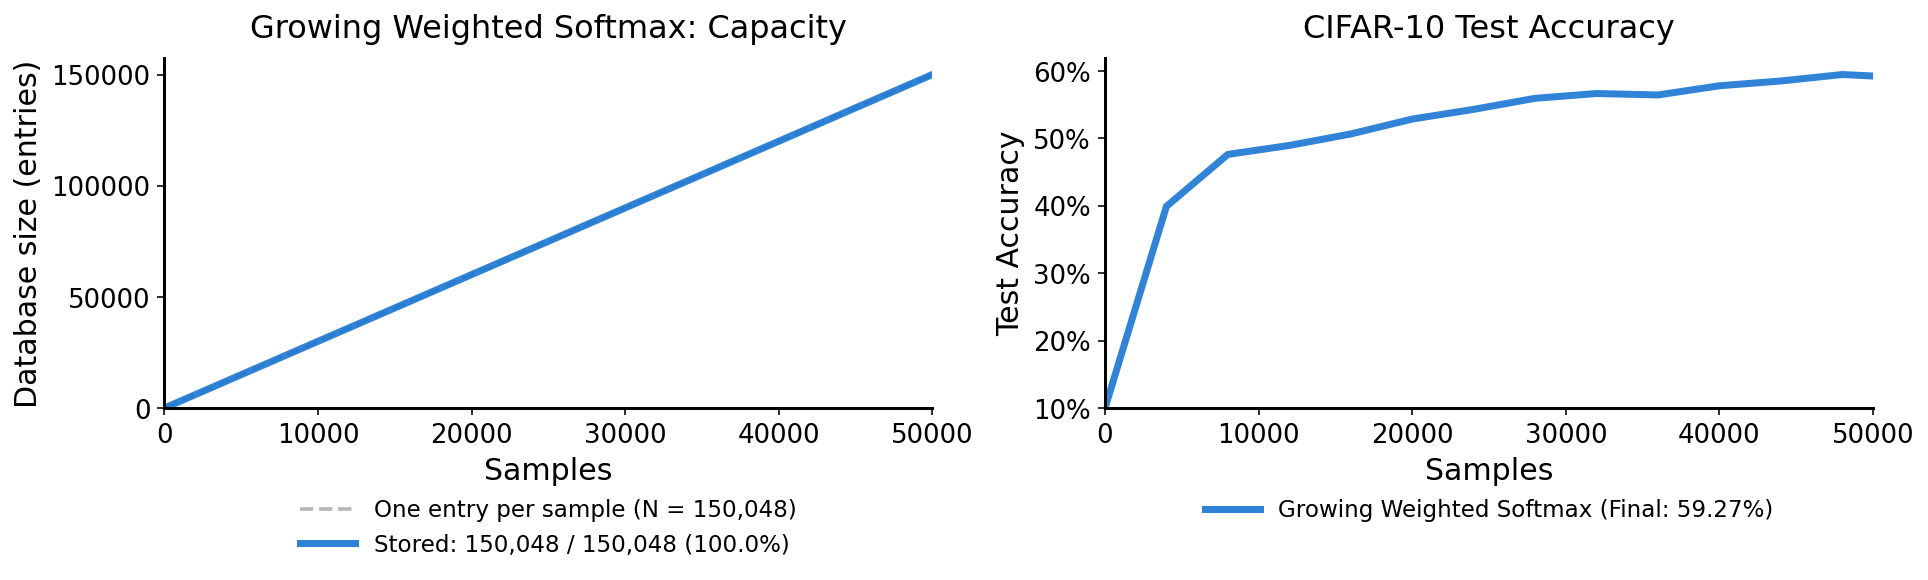

In [ ]:
#@title 5.1 Run Growing Weighted Softmax

EVAL_EVERY = 250  # @param {type:"integer"}
FORCE_RETRAIN = False  # @param {type:"boolean"}

gws_cfg = RCDLConfig(
    kernel_type='gws',
    hidden_dim=3072,
    num_layers=2,
    temperature=6.0,               # T
    beta=3.0,                      # β: value learning rate
    model_momentum=0.0,
    db_size=50016,                 # 50,000 (1 epoch) + 16 (init batch)
    learn_norm_params=False,
    num_classes=10,
    batch_size=16,
    eta=0.003,                     # η: weight learning rate
    learning_rate=3e-4,
    num_epochs=1,
    global_init_seed=1,
)

if FORCE_RETRAIN or 'gws_result' not in globals() or gws_result is None or gws_result.get('cfg') != gws_cfg:
  gws_result = run_rcdl_experiment(gws_cfg, eval_every=EVAL_EVERY)
_ = plot_rcdl_result(gws_result)


## 5B. Experiment 1B: Gauge-Invariant Weighted Softmax

The weighted softmax has an exact shift (gauge) symmetry: shifting every stored weighted value by $\tilde{\mathbf{v}}_j \leftarrow \tilde{\mathbf{v}}_j + w_j \boldsymbol{\xi}$ shifts the output by $s_D(\mathbf{q}) \leftarrow s_D(\mathbf{q}) + \boldsymbol{\xi}$. The **Gauge-Invariant Weighted Softmax** uses this symmetry to choose a virtual gauge at every step so that the new weight is strictly positive, so no clipping is needed. We use the variant with updates in the order of the gradient length, with gauge parameter $\alpha$:

$$\mathbf{k}_t = \mathbf{q}_t, \qquad w_t = \eta\, \alpha\, \lVert \bar g_t \rVert_2, \qquad \tilde{\mathbf{v}}_t = \left(-\eta \alpha^2 - \beta + \eta\, \alpha\, \frac{\langle s_{t-1}, \bar g_t \rangle}{\lVert \bar g_t \rVert_2 + 10^{-8}}\right) \bar g_t .$$

Note that this implementation uses the batch-mean gradient $\bar g_t = g_t / B$ (see Section 4). Both updates are linear in the gradient, so this is equivalent to the per-sample rule (with $g_t$) using learning rates $\eta / B$ and $\beta / B$.

Gauge-Invariant Weighted Softmax | L=2 residual blocks (+ readout) | hidden=3072 | db_size=50,016
gauge_method='normalized_v2' α=10.0 η=0.03 β=100.0
T=5.0 momentum=0.0 batch=16 seed=1
database ~3.07 GB of float32 parameters
Initial Eval: Loss=7.0898, Accuracy=0.1000, Capacity=48/150,048 (0.0%)


Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=1.7319, Accuracy=0.3996, Capacity=12,048/150,048 (8.0%)
Eval at 8,000 samples: Loss=1.5090, Accuracy=0.4725, Capacity=24,048/150,048 (16.0%)
Eval at 12,000 samples: Loss=1.4468, Accuracy=0.4995, Capacity=36,048/150,048 (24.0%)
Eval at 16,000 samples: Loss=1.4051, Accuracy=0.5085, Capacity=48,048/150,048 (32.0%)
Eval at 20,000 samples: Loss=1.3553, Accuracy=0.5277, Capacity=60,048/150,048 (40.0%)
Eval at 24,000 samples: Loss=1.3297, Accuracy=0.5375, Capacity=72,048/150,048 (48.0%)
Eval at 28,000 samples: Loss=1.2891, Accuracy=0.5543, Capacity=84,048/150,048 (56.0%)
Eval at 32,000 samples: Loss=1.2654, Accuracy=0.5621, Capacity=96,048/150,048 (64.0%)
Eval at 36,000 samples: Loss=1.2578, Accuracy=0.5611, Capacity=108,048/150,048 (72.0%)
Eval at 40,000 samples: Loss=1.2387, Accuracy=0.5732, Capacity=120,048/150,048 (80.0%)
Eval at 44,000 samples: Loss=1.2230, Accuracy=0.5782, Capacity=132,048/150,048 (88.0%)
Eval at 48,000 samples: Loss=1.2010, Accuracy=0.5845, 

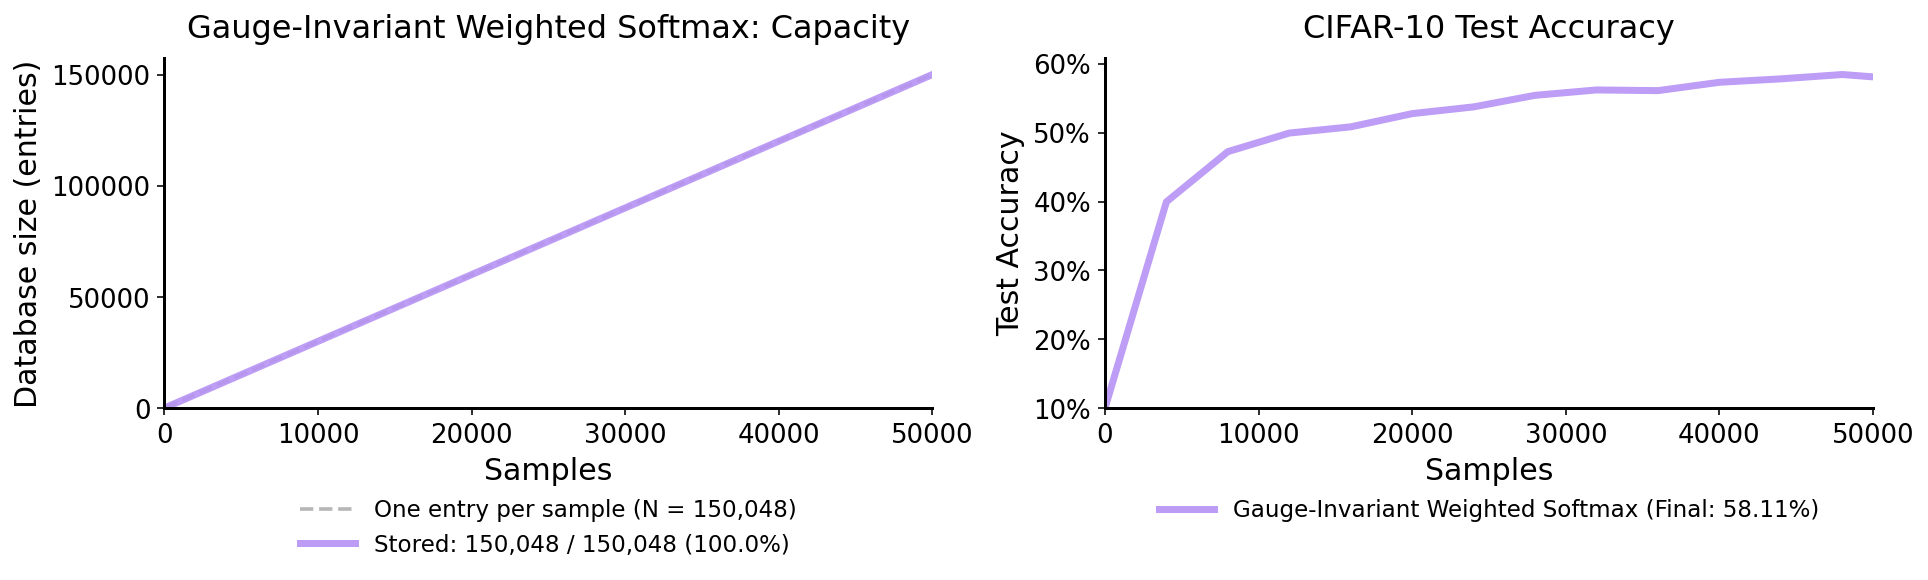

In [ ]:
#@title 5.2 Run Gauge-Invariant Weighted Softmax

EVAL_EVERY = 250  # @param {type:"integer"}
FORCE_RETRAIN = False  # @param {type:"boolean"}

gauge_cfg = RCDLConfig(
    kernel_type='gauge',
    gauge_method='normalized_v2',
    gauge_alpha=10.0,              # α: gauge parameter
    eta=0.03,                      # η: weight learning rate
    beta=100.0,                    # β: value learning rate
    hidden_dim=3072,
    num_layers=2,
    temperature=5.0,               # T
    model_momentum=0.0,
    db_size=50016,                 # 50,000 (1 epoch) + 16 (init batch)
    learn_norm_params=False,
    num_classes=10,
    batch_size=16,
    learning_rate=3e-4,
    num_epochs=1,
    global_init_seed=1,
)

if FORCE_RETRAIN or 'gauge_result' not in globals() or gauge_result is None or gauge_result.get('cfg') != gauge_cfg:
  gauge_result = run_rcdl_experiment(gauge_cfg, eval_every=EVAL_EVERY)
_ = plot_rcdl_result(gauge_result)


## 6. Experiment 2: Growing RBF

As a positive-definite kernel (PDK) instance of RCDL, the **Growing RBF** replaces the normalized weighted softmax attention with the unnormalized Gaussian RBF kernel from Section 3. Its learning rule stores the query as the key and the scaled negative gradient as the value:

$$\mathbf{k}_t = \mathbf{q}_t, \qquad \mathbf{v}_t = -\eta\, g_t,$$

where $\eta$ is the value learning rate.

Growing RBF | L=2 residual blocks (+ readout) | hidden=3072 | db_size=50,000
T=10.0 η=10.0 init_pred_scale=20.0 momentum=0.0 batch=16 seed=1
database ~3.07 GB of float32 parameters
Initial Eval: Loss=2.3026, Accuracy=0.1000, Capacity=0/150,000 (0.0%)


Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=1.7355, Accuracy=0.4220, Capacity=12,000/150,000 (8.0%)
Eval at 8,000 samples: Loss=1.5303, Accuracy=0.4788, Capacity=24,000/150,000 (16.0%)
Eval at 12,000 samples: Loss=1.4720, Accuracy=0.5021, Capacity=36,000/150,000 (24.0%)
Eval at 16,000 samples: Loss=1.4112, Accuracy=0.5192, Capacity=48,000/150,000 (32.0%)
Eval at 20,000 samples: Loss=1.3725, Accuracy=0.5340, Capacity=60,000/150,000 (40.0%)
Eval at 24,000 samples: Loss=1.3357, Accuracy=0.5455, Capacity=72,000/150,000 (48.0%)
Eval at 28,000 samples: Loss=1.3025, Accuracy=0.5552, Capacity=84,000/150,000 (56.0%)
Eval at 32,000 samples: Loss=1.2675, Accuracy=0.5646, Capacity=96,000/150,000 (64.0%)
Eval at 36,000 samples: Loss=1.2585, Accuracy=0.5661, Capacity=108,000/150,000 (72.0%)
Eval at 40,000 samples: Loss=1.2405, Accuracy=0.5751, Capacity=120,000/150,000 (80.0%)
Eval at 44,000 samples: Loss=1.2311, Accuracy=0.5783, Capacity=132,000/150,000 (88.0%)
Eval at 48,000 samples: Loss=1.2095, Accuracy=0.5868, 

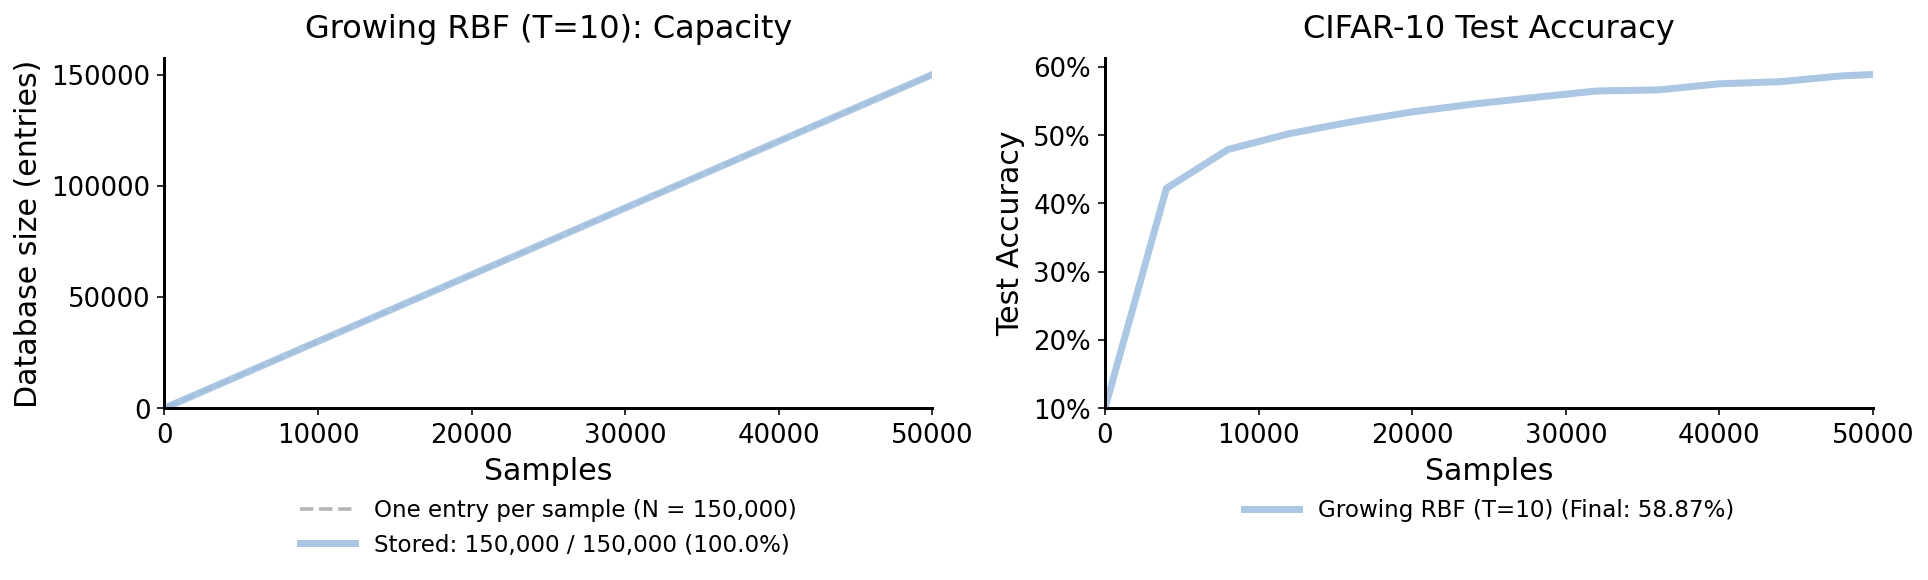

In [ ]:
#@title 6.1 Run Growing RBF

TEMPERATURE = 10.0  # @param {type:"number"}
ETA = 10.0  # @param {type:"number"}
BATCH_SIZE = 16  # @param {type:"integer"}
ADD_ACTIVATIONS = False  # @param {type:"boolean"}
FREEZE_INIT_OUT = True  # @param {type:"boolean"}
EVAL_EVERY = 250  # @param {type:"integer"}
FORCE_RETRAIN = False  # @param {type:"boolean"}

rbf_cfg = RCDLConfig(
    kernel_type='rbf',
    hidden_dim=3072,
    num_layers=2,
    temperature=float(TEMPERATURE),  # T: kernel exp(-||q-k||^2 / (2 T sqrt(d_in)))
    init_pred_scale=20.0,
    add_activations=bool(ADD_ACTIVATIONS),
    freeze_init_out=bool(FREEZE_INIT_OUT),
    model_momentum=0.0,
    db_size=(50000 // int(BATCH_SIZE)) * int(BATCH_SIZE),  # 1 epoch (no initial entries)
    learn_norm_params=False,
    num_classes=10,
    batch_size=int(BATCH_SIZE),
    eta=float(ETA),                  # η: value learning rate
    learning_rate=3e-4,
    num_epochs=1,
    global_init_seed=1,
)

if FORCE_RETRAIN or 'rbf_result' not in globals() or rbf_result is None or rbf_result.get('cfg') != rbf_cfg:
  rbf_result = run_rcdl_experiment(rbf_cfg, eval_every=EVAL_EVERY)
_ = plot_rcdl_result(rbf_result)


## 7. Experiment 3: Hybrid Growing Weighted Softmax (Sublinear Growth)

Rather than storing every training sample, the **Hybrid Growing Weighted Softmax** grows its database selectively and refines existing entries by backpropagation:
- **Select novel queries:** A query $\mathbf{q}_{t,n}$ from the current batch is added to the database (with the weight and weighted value of the Growing Weighted Softmax rule from Section 5) only if its Euclidean distance to all stored keys exceeds the growth threshold $\tau$, i.e. $\min_j \lVert \mathbf{q}_{t,n} - \mathbf{k}_j \rVert_2 > \tau$.
- **Parametric update:** All stored keys, weighted values, and weights are updated jointly with one Adam step per batch.

Hybrid Growing Weighted Softmax | L=3 residual blocks (+ readout) | hidden=3072 | capacity=50,016 | learn_norm=False
trigger='distance' threshold=50.0 η=1.0 β=30.0
T=5.0 Adam lr=0.001 B=16 seed=42
database ~4.30 GB of float32 parameters
Initial Eval: Loss=10.4541, Accuracy=0.1000, Capacity=64/200,064 (0.0%)


Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=1.7767, Accuracy=0.3872, Capacity=8,230/200,064 (4.1%)
Eval at 8,000 samples: Loss=1.6111, Accuracy=0.4433, Capacity=15,294/200,064 (7.6%)
Eval at 12,000 samples: Loss=1.5462, Accuracy=0.4580, Capacity=22,467/200,064 (11.2%)
Eval at 16,000 samples: Loss=1.4738, Accuracy=0.4890, Capacity=29,638/200,064 (14.8%)
Eval at 20,000 samples: Loss=1.4210, Accuracy=0.5037, Capacity=36,833/200,064 (18.4%)
Eval at 24,000 samples: Loss=1.3905, Accuracy=0.5156, Capacity=44,198/200,064 (22.1%)
Eval at 28,000 samples: Loss=1.3710, Accuracy=0.5180, Capacity=51,320/200,064 (25.7%)
Eval at 32,000 samples: Loss=1.3439, Accuracy=0.5315, Capacity=58,668/200,064 (29.3%)
Eval at 36,000 samples: Loss=1.3176, Accuracy=0.5407, Capacity=66,051/200,064 (33.0%)
Eval at 40,000 samples: Loss=1.3052, Accuracy=0.5500, Capacity=73,526/200,064 (36.8%)
Eval at 44,000 samples: Loss=1.2825, Accuracy=0.5543, Capacity=80,976/200,064 (40.5%)
Eval at 48,000 samples: Loss=1.2670, Accuracy=0.5565, Capac

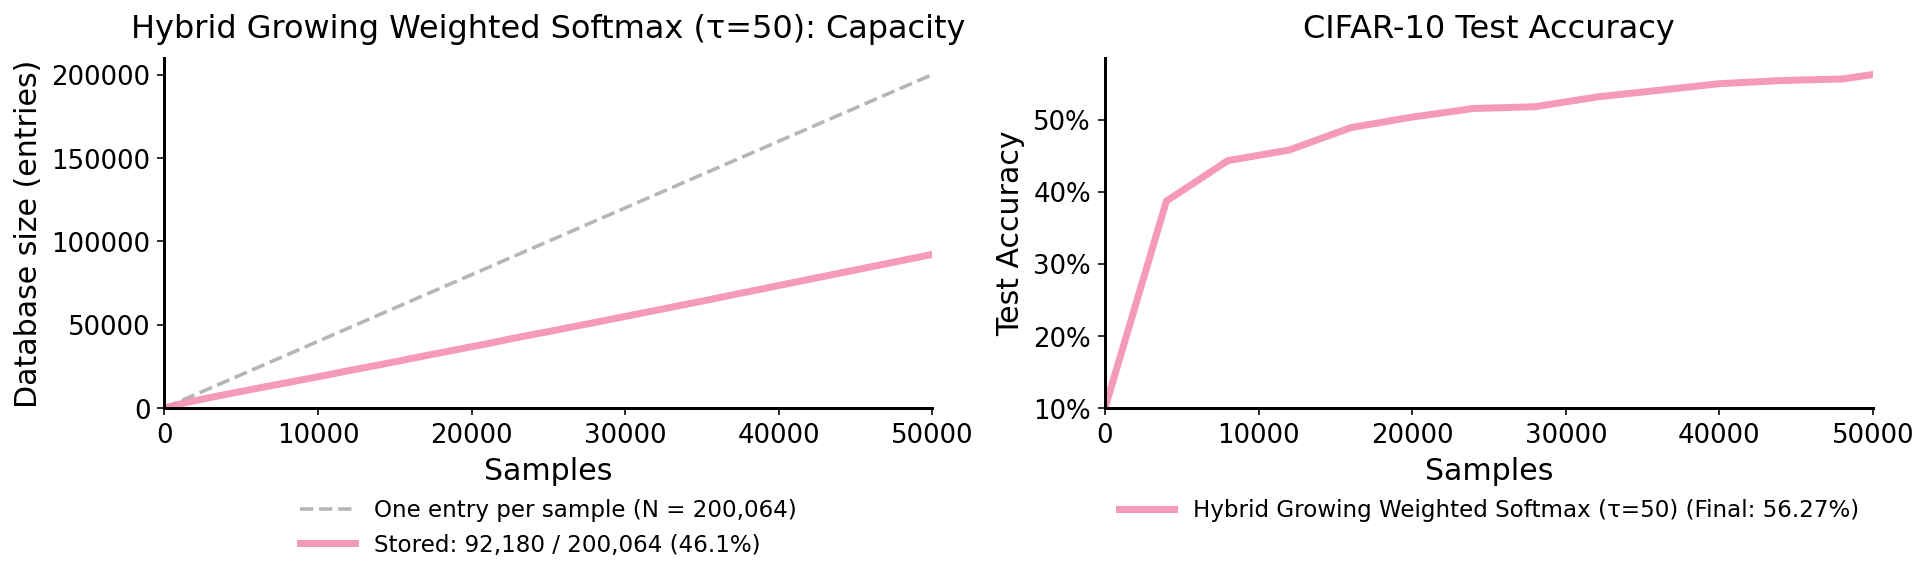

In [ ]:
#@title 7.1 Run Hybrid Growing Weighted Softmax

EVAL_EVERY = 250  # @param {type:"integer"}
FORCE_RETRAIN = False  # @param {type:"boolean"}
GROWTH_THRESHOLD = 50.0        # @param {type:"number"}

hybrid_cfg = RCDLConfig(
    kernel_type='hybrid',
    hidden_dim=3072,
    num_layers=3,
    temperature=5.0,               # T
    db_size=50016,                 # 50,000 (1 epoch) + 16 (init batch)
    learn_norm_params=False,
    use_nndense_readout=False,
    growth_trigger='distance',
    growth_threshold=GROWTH_THRESHOLD,
    beta=30.0,                     # β: value learning rate
    num_classes=10,
    batch_size=16,
    eta=1.0,                       # η: weight learning rate
    learning_rate=1e-3,            # Adam learning rate (parametric refinement)
    db_weights_lr=0.0,
    num_epochs=1,
    global_init_seed=42,
)

if FORCE_RETRAIN or 'hybrid_result' not in globals() or hybrid_result is None or hybrid_result.get('cfg') != hybrid_cfg:
  hybrid_result = run_rcdl_experiment(hybrid_cfg, eval_every=EVAL_EVERY)
_ = plot_rcdl_result(hybrid_result)


## 8. Experiment 4: ResNet-MLP Baseline

As a standard deep learning reference, the **ResNet-MLP** replaces all RCDL layers with standard learnable `nn.Dense` + `GELU` residual blocks. Select the optimizer (`adam`, `sgd`, `adamw`, `rmsprop`, or `muon`) using the form controls below. By default (`USE_TUNED_HPARAMS`), each optimizer uses its best hyperparameters:

Uncheck `USE_TUNED_HPARAMS` to set the learning rate, momentum, and weight decay manually.

ResNet-MLP | optimizer=adam (tuned) | lr=0.0001 | B=16 | momentum=0 | weight_decay=0
ResNet-MLP | L=8 residual blocks (+ readout) | hidden=3072 | activation='gelu'
optimizer=adam lr=0.0001 momentum=0.0 weight_decay=0.0 batch=16 seed=1
dense parameters ~0.30 GB of float32 weights (fixed layer width=3,072 = 6.1% cap)
Initial Eval: Loss=2.7274, Accuracy=0.0861, Capacity=24,576/400,128 (6.1%)


Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=1.7892, Accuracy=0.3725, Capacity=24,576/400,128 (6.1%)
Eval at 8,000 samples: Loss=1.6977, Accuracy=0.4020, Capacity=24,576/400,128 (6.1%)
Eval at 12,000 samples: Loss=1.6716, Accuracy=0.3933, Capacity=24,576/400,128 (6.1%)
Eval at 16,000 samples: Loss=1.5884, Accuracy=0.4384, Capacity=24,576/400,128 (6.1%)
Eval at 20,000 samples: Loss=1.5826, Accuracy=0.4332, Capacity=24,576/400,128 (6.1%)
Eval at 24,000 samples: Loss=1.5356, Accuracy=0.4473, Capacity=24,576/400,128 (6.1%)
Eval at 28,000 samples: Loss=1.5249, Accuracy=0.4541, Capacity=24,576/400,128 (6.1%)
Eval at 32,000 samples: Loss=1.5103, Accuracy=0.4680, Capacity=24,576/400,128 (6.1%)
Eval at 36,000 samples: Loss=1.4957, Accuracy=0.4653, Capacity=24,576/400,128 (6.1%)
Eval at 40,000 samples: Loss=1.4996, Accuracy=0.4719, Capacity=24,576/400,128 (6.1%)
Eval at 44,000 samples: Loss=1.4189, Accuracy=0.4952, Capacity=24,576/400,128 (6.1%)
Eval at 48,000 samples: Loss=1.4169, Accuracy=0.4894, Capacity=24,5

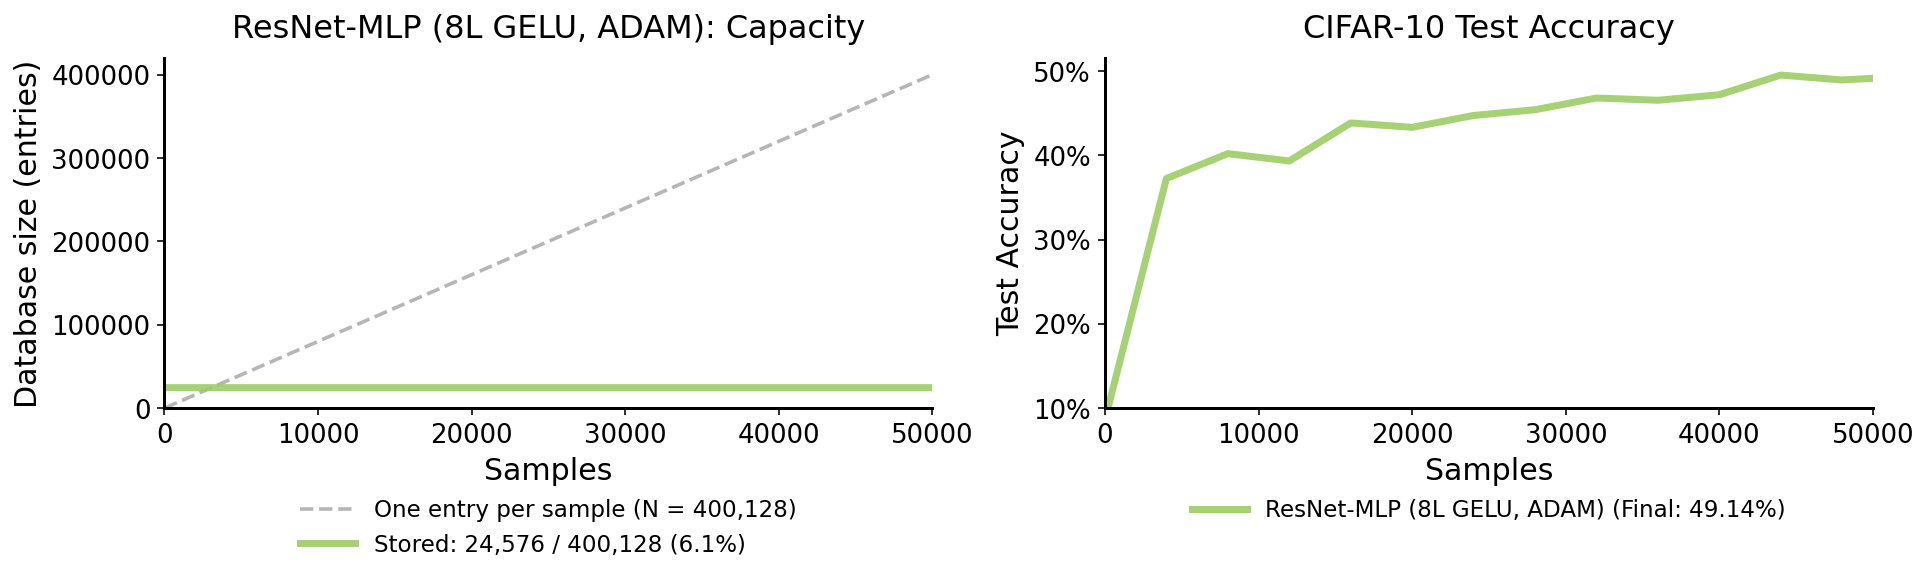

In [ ]:
#@title 8.1 Run ResNet-MLP

OPTIMIZER = "adam"  # @param ["adam", "sgd", "adamw", "rmsprop", "muon"]
USE_TUNED_HPARAMS = True  # @param {type:"boolean"}
#@markdown Manual settings below are only used if `USE_TUNED_HPARAMS` is unchecked.
LEARNING_RATE = 1e-4  # @param {type:"number"}
MOMENTUM = 0.85  # @param {type:"number"}
WEIGHT_DECAY = 0.0  # @param {type:"number"}
EVAL_EVERY = 250  # @param {type:"integer"}
FORCE_RETRAIN = False  # @param {type:"boolean"}
BATCH_SIZE = 16

# Best hyperparameters per optimizer at batch size 16 for this ResNet-MLP
TUNED_HPARAMS = {
    'adam':    dict(learning_rate=1e-4, momentum=0.0,  weight_decay=0.0),   # 48.2 ± 1.0 %
    'adamw':   dict(learning_rate=1e-4, momentum=0.0,  weight_decay=1e-4),  # 48.3 ± 1.0 %
    'muon':    dict(learning_rate=1e-3, momentum=0.0,  weight_decay=0.0),   # 57.2 ± 0.4 %
    'rmsprop': dict(learning_rate=1e-4, momentum=0.0,  weight_decay=0.0),   # 49.9 ± 0.7 %
    'sgd':     dict(learning_rate=1e-3, momentum=0.85, weight_decay=0.0),   # 46.3 ± 2.0 %
}

if USE_TUNED_HPARAMS:
  hp = TUNED_HPARAMS[OPTIMIZER]
else:
  hp = dict(learning_rate=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
print(f"ResNet-MLP | optimizer={OPTIMIZER} ({'tuned' if USE_TUNED_HPARAMS else 'manual'}) | "
      f"lr={hp['learning_rate']:g} | B={BATCH_SIZE} | "
      f"momentum={hp['momentum'] if OPTIMIZER == 'sgd' else 0.0:g} | "
      f"weight_decay={hp['weight_decay'] if OPTIMIZER in ('adamw', 'muon') else 0.0:g}")

standard_cfg = RCDLConfig(
    kernel_type='standard',
    hidden_dim=3072,
    num_layers=8,
    nonlinearity='gelu',
    learn_norm_params=False,
    use_residual=True,
    use_post_norm=False,
    num_classes=10,
    batch_size=int(BATCH_SIZE),
    optimizer=OPTIMIZER,
    learning_rate=float(hp['learning_rate']),
    model_momentum=float(hp['momentum']) if OPTIMIZER == 'sgd' else 0.0,
    weight_decay=float(hp['weight_decay']) if OPTIMIZER in ('adamw', 'muon') else 0.0,
    num_epochs=1,
    global_init_seed=1,
)

if FORCE_RETRAIN or 'standard_result' not in globals() or standard_result is None or standard_result.get('cfg') != standard_cfg:
  standard_result = run_rcdl_experiment(standard_cfg, eval_every=EVAL_EVERY)
  standard_result.pop('state', None)
  gc.collect()
_ = plot_rcdl_result(standard_result)


## 9. Experiment 5: Parametric Softmax Baseline (10% vs. 100% Capacity)

To isolate the role of the **nonparametric growth rule** from the weighted softmax architecture itself, the **Parametric Softmax** pre-allocates a fixed-size table of $N$ entries per layer at initialization and trains all $(w_j, \mathbf{k}_j, \tilde{\mathbf{v}}_j)$ purely by backpropagation with Adam (no database growth). We evaluate two table sizes:
1. **10% Capacity** ($N = 5{,}000$; an additional ablation that is not part of the paper)
2. **100% Capacity** ($N = 50{,}016$, the final database size of the Growing Weighted Softmax)

>>> Running Parametric Softmax at 10% Capacity (5,000 entries) <<<
Stacked Parametric Softmax | layers=2 (+1 readout) | hidden=3072 | N=5,000 (10.0% of 1-epoch cap)
T=3.0 optimizer=adam lr=0.001 learn_weights=True batch=16 seed=1
database ~0.31 GB of float32 parameters
Initial Eval: Loss=2.3026, Accuracy=0.1000, Capacity=15,000/150,048 (10.0%)


Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=2.2989, Accuracy=0.1462, Capacity=15,000/150,048 (10.0%)
Eval at 8,000 samples: Loss=2.1814, Accuracy=0.2035, Capacity=15,000/150,048 (10.0%)
Eval at 12,000 samples: Loss=1.9700, Accuracy=0.2838, Capacity=15,000/150,048 (10.0%)
Eval at 16,000 samples: Loss=1.8554, Accuracy=0.3344, Capacity=15,000/150,048 (10.0%)
Eval at 20,000 samples: Loss=1.8007, Accuracy=0.3549, Capacity=15,000/150,048 (10.0%)
Eval at 24,000 samples: Loss=1.7584, Accuracy=0.3687, Capacity=15,000/150,048 (10.0%)
Eval at 28,000 samples: Loss=1.7415, Accuracy=0.3791, Capacity=15,000/150,048 (10.0%)
Eval at 32,000 samples: Loss=1.7065, Accuracy=0.3913, Capacity=15,000/150,048 (10.0%)
Eval at 36,000 samples: Loss=1.6879, Accuracy=0.4016, Capacity=15,000/150,048 (10.0%)
Eval at 40,000 samples: Loss=1.6689, Accuracy=0.4083, Capacity=15,000/150,048 (10.0%)
Eval at 44,000 samples: Loss=1.6551, Accuracy=0.4105, Capacity=15,000/150,048 (10.0%)
Eval at 48,000 samples: Loss=1.6410, Accuracy=0.4151, Ca

Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=2.3024, Accuracy=0.1000, Capacity=150,048/150,048 (100.0%)
Eval at 8,000 samples: Loss=2.3018, Accuracy=0.1454, Capacity=150,048/150,048 (100.0%)
Eval at 12,000 samples: Loss=2.2981, Accuracy=0.1569, Capacity=150,048/150,048 (100.0%)
Eval at 16,000 samples: Loss=2.2173, Accuracy=0.1819, Capacity=150,048/150,048 (100.0%)
Eval at 20,000 samples: Loss=2.0114, Accuracy=0.2635, Capacity=150,048/150,048 (100.0%)
Eval at 24,000 samples: Loss=1.9021, Accuracy=0.3094, Capacity=150,048/150,048 (100.0%)
Eval at 28,000 samples: Loss=1.8389, Accuracy=0.3388, Capacity=150,048/150,048 (100.0%)
Eval at 32,000 samples: Loss=1.7822, Accuracy=0.3622, Capacity=150,048/150,048 (100.0%)
Eval at 36,000 samples: Loss=1.7457, Accuracy=0.3802, Capacity=150,048/150,048 (100.0%)
Eval at 40,000 samples: Loss=1.7227, Accuracy=0.3894, Capacity=150,048/150,048 (100.0%)
Eval at 44,000 samples: Loss=1.6946, Accuracy=0.3928, Capacity=150,048/150,048 (100.0%)
Eval at 48,000 samples: Loss=1.680

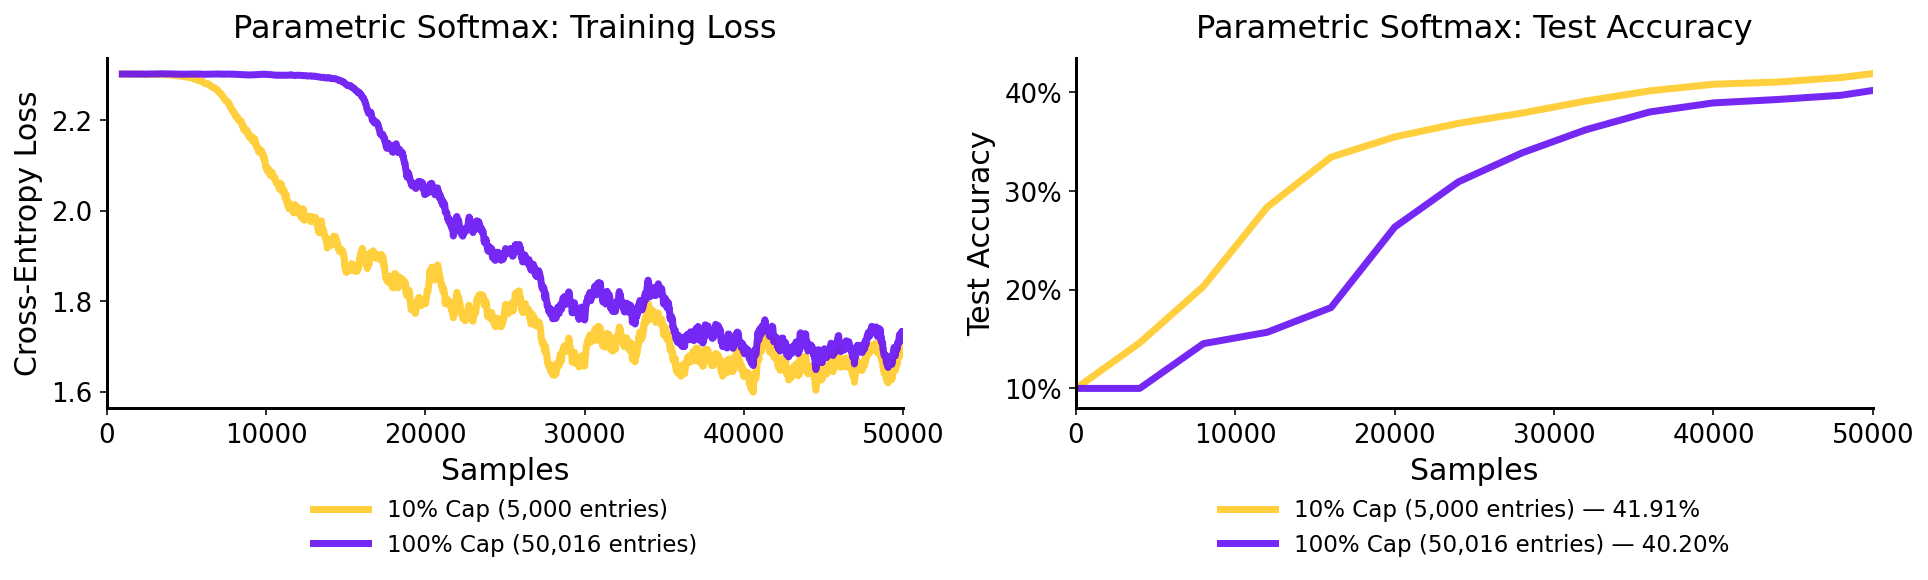

In [ ]:
#@title 9.1 Run Parametric Softmax Baseline (10% and 100% Capacity)

BATCH_SIZE = 16  # @param {type:"integer"}
EVAL_EVERY = 250  # @param {type:"integer"}
FORCE_RETRAIN = False  # @param {type:"boolean"}

# 1. Parametric Softmax at 10% Capacity (5,000 entries)
parametric_softmax_10pct_cfg = RCDLConfig(
    kernel_type='parametric_softmax',
    hidden_dim=3072,
    num_layers=2,
    temperature=3.0,
    db_size=5000,                  # 10% of 1-epoch capacity
    full_epoch_capacity=50016,
    learn_parametric_weights=True,
    learn_norm_params=False,
    num_classes=10,
    batch_size=int(BATCH_SIZE),
    optimizer='adam',
    learning_rate=1e-3,
    num_epochs=1,
    global_init_seed=1,
)

if (
    FORCE_RETRAIN
    or 'parametric_softmax_10pct_result' not in globals()
    or parametric_softmax_10pct_result is None
    or parametric_softmax_10pct_result.get('cfg') != parametric_softmax_10pct_cfg
):
  print(">>> Running Parametric Softmax at 10% Capacity (5,000 entries) <<<")
  parametric_softmax_10pct_result = run_rcdl_experiment(parametric_softmax_10pct_cfg, eval_every=EVAL_EVERY)
  parametric_softmax_10pct_result.pop('state', None)
  gc.collect()

# 2. Parametric Softmax at 100% Capacity (50,016 entries)
parametric_softmax_100pct_cfg = RCDLConfig(
    kernel_type='parametric_softmax',
    hidden_dim=3072,
    num_layers=2,
    temperature=3.0,
    db_size=50016,                 # 100% of 1-epoch capacity
    full_epoch_capacity=50016,
    learn_parametric_weights=True,
    learn_norm_params=False,
    num_classes=10,
    batch_size=int(BATCH_SIZE),
    optimizer='adam',
    learning_rate=1e-3,
    num_epochs=1,
    global_init_seed=1,
)

if (
    FORCE_RETRAIN
    or 'parametric_softmax_100pct_result' not in globals()
    or parametric_softmax_100pct_result is None
    or parametric_softmax_100pct_result.get('cfg') != parametric_softmax_100pct_cfg
):
  print(">>> Running Parametric Softmax at 100% Capacity (50,016 entries) <<<")
  parametric_softmax_100pct_result = run_rcdl_experiment(parametric_softmax_100pct_cfg, eval_every=EVAL_EVERY)
  parametric_softmax_100pct_result.pop('state', None)
  gc.collect()


def plot_parametric_softmax_comparison(res_10: Dict[str, Any], res_100: Dict[str, Any]):
  """Compares Parametric Softmax at 10% (5,000 entries) vs 100% (50,016 entries) capacity in the paper style."""
  import matplotlib.ticker as mtick
  h10, h100 = res_10['history'], res_100['history']
  fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13.5, 5.2))

  col_10, col_100 = '#ffca28', '#6610f2'
  for h, col, lbl in [
      (h10, col_10, '10% Cap (5,000 entries)'),
      (h100, col_100, '100% Cap (50,016 entries)'),
  ]:
    s_arr = np.asarray(h['samples'])
    l_arr = np.asarray(h['train_losses'])
    win = max(1, len(l_arr) // 50)
    if len(l_arr) >= win:
      sm_l = np.convolve(l_arr, np.ones(win) / float(win), mode='valid')
      ax_loss.plot(s_arr[win - 1:], sm_l, ls='-', lw=3.5, color=col, alpha=0.9, label=lbl)

  ax_loss.set_title('Parametric Softmax: Training Loss', fontsize=16, pad=10)
  ax_loss.set_xlabel('Samples', fontsize=15)
  ax_loss.set_ylabel('Cross-Entropy Loss', fontsize=15)
  ax_loss.set_xlim(0, 50000)

  t10, a10 = np.asarray(h10['test_samples']), np.asarray(h10['test_accuracies']) * 100.0
  t100, a100 = np.asarray(h100['test_samples']), np.asarray(h100['test_accuracies']) * 100.0
  ax_acc.plot(t10, a10, ls='-', lw=3.5, color=col_10, alpha=0.9,
              label=f'10% Cap (5,000 entries) — {a10[-1]:.2f}%')
  ax_acc.plot(t100, a100, ls='-', lw=3.5, color=col_100, alpha=0.9,
              label=f'100% Cap (50,016 entries) — {a100[-1]:.2f}%')
  ax_acc.set_title('Parametric Softmax: Test Accuracy', fontsize=16, pad=10)
  ax_acc.set_xlabel('Samples', fontsize=15)
  ax_acc.set_ylabel('Test Accuracy', fontsize=15)
  ax_acc.set_xlim(0, 50000)
  ax_acc.set_ylim(8.0, None)
  ax_acc.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))

  for ax in (ax_loss, ax_acc):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.grid(False)
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.20),
        frameon=False,
        fontsize=11.5,
        handlelength=2.4,
    )

  plt.tight_layout(rect=[0.0, 0.14, 1.0, 1.0])
  plt.show()
  return fig


_ = plot_parametric_softmax_comparison(parametric_softmax_10pct_result, parametric_softmax_100pct_result)


## 10. Benchmark Comparison Across All Models

Run the cell below to compare **Training Loss**, **CIFAR-10 Test Accuracy**, and **Capacity** (number of stored database entries) across all models executed above.

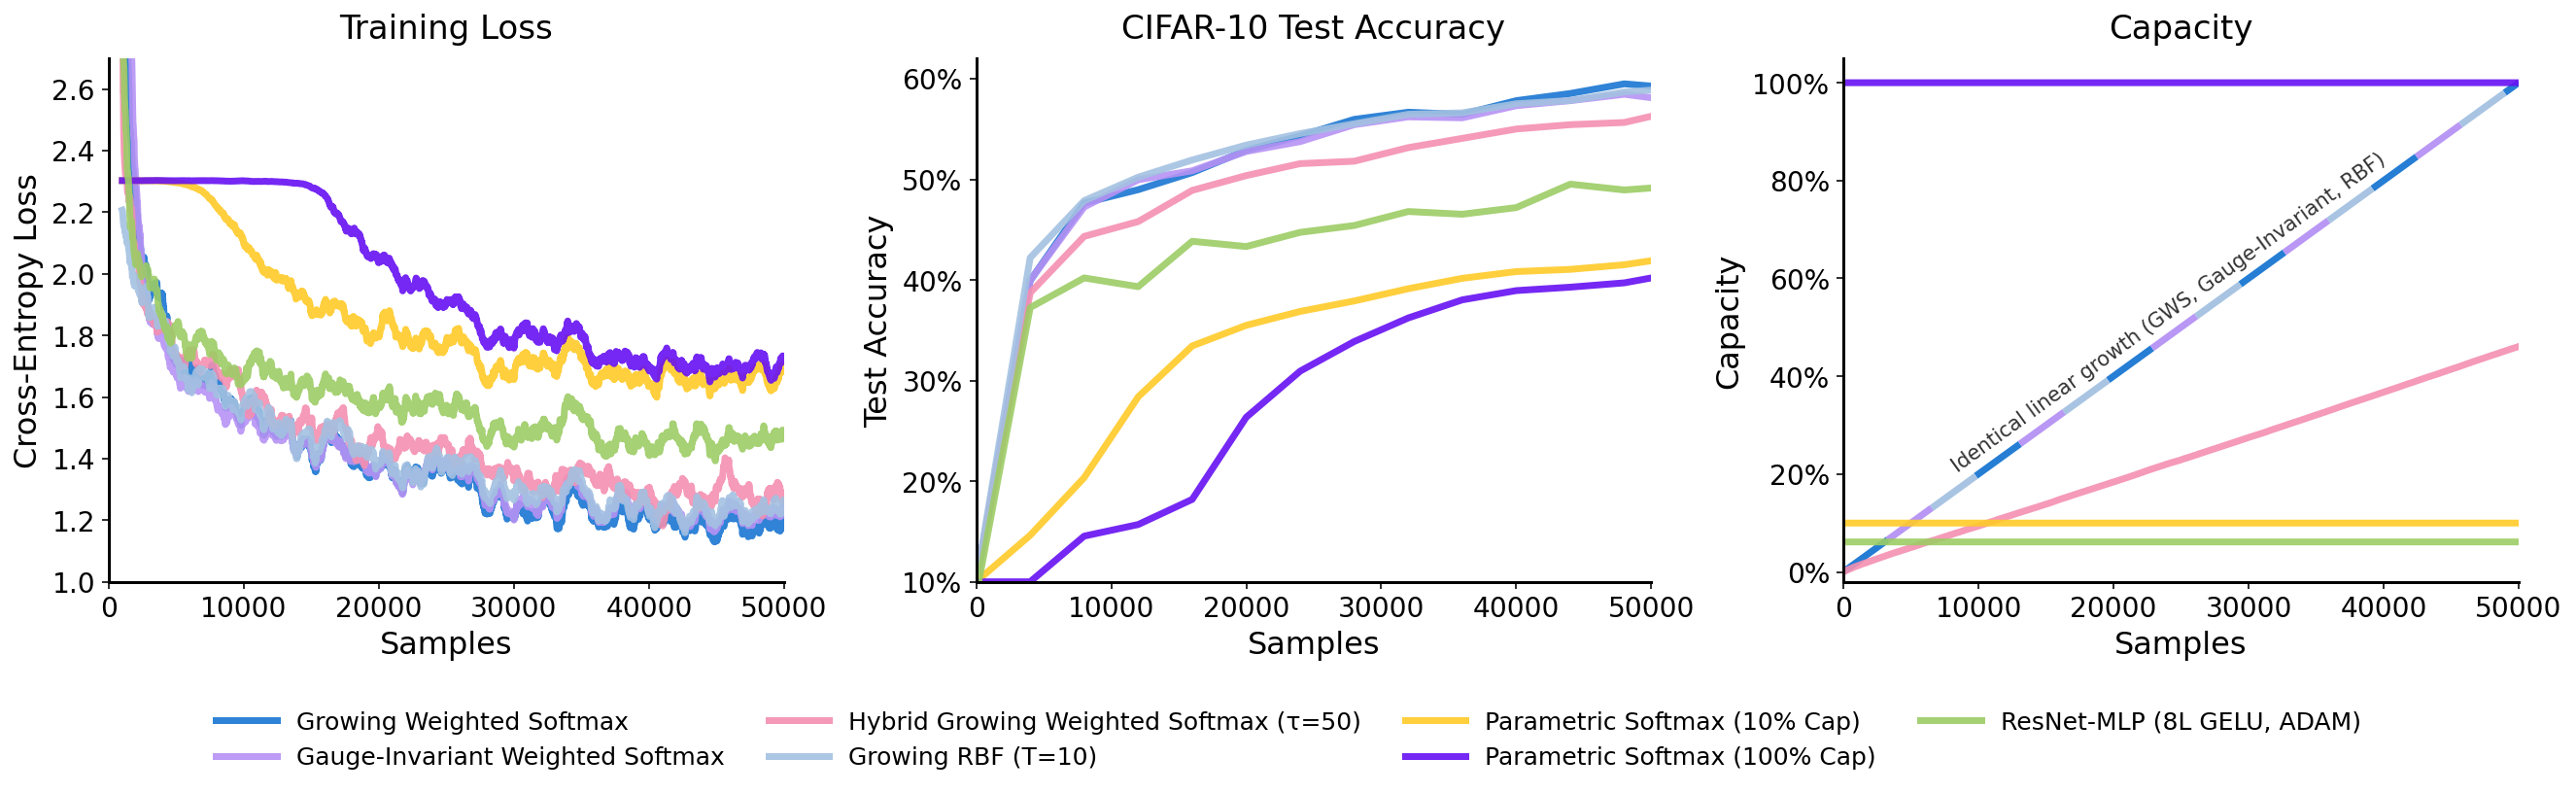

In [ ]:
#@title 10.1 Plot Master Benchmark Comparison

def plot_all_rcdl_models(results_map: Dict[str, Optional[Dict[str, Any]]]):
  """3-panel comparison of Training Loss, Test Accuracy, and Active Capacity in the paper style."""
  import matplotlib.ticker as mtick

  # --- Paper Aesthetics ---
  fontsize_title = 17
  fontsize_labels = 16
  fontsize_ticks = 14
  fontsize_legend = 12.5
  linewidth_traj = 3.5
  linewidth_x = 1.5
  linewidth_y = 1.5

  fig, (ax_loss, ax_acc, ax_mem) = plt.subplots(1, 3, figsize=(18.5, 5.8))

  # Paper METHOD_PALETTE mapping
  style_map = {
      'gws': ('#1976D2', 'Growing Weighted Softmax'),
      'gauge': ('#b692f4', 'Gauge-Invariant Weighted Softmax'),
      'hybrid': ('#f48fb1', 'Hybrid Growing Weighted Softmax'),
      'rbf': ('#a3c1e1', 'Growing RBF'),
      'parametric_softmax_10pct': ('#ffca28', 'Parametric Softmax (10% Cap)'),
      'parametric_softmax_100pct': ('#6610f2', 'Parametric Softmax (100% Cap)'),
      'standard': ('#9ccc65', 'ResNet-MLP'),
  }
  opt_palette = {
      'adam': '#9ccc65',
      'adamw': '#689f38',
      'rmsprop': '#c5e1a5',
      'sgd': '#9E9E9E',
      'muon': '#ffca28',
  }
  short_linear_names = {
      'gws': 'GWS',
      'gauge': 'Gauge-Invariant',
      'rbf': 'RBF',
  }
  linear_keys = [
      k for k in ('gws', 'gauge', 'rbf') if results_map.get(k) is not None
  ]

  legend_handles = []
  legend_labels = []

  for key, res in results_map.items():
    if res is None:
      continue
    h = res['history']
    col, label = style_map.get(key, ('#000000', key))
    cfg_m = res.get('cfg')
    if key == 'hybrid' and cfg_m is not None:
      label = f'Hybrid Growing Weighted Softmax (τ={cfg_m.growth_threshold:g})'
    elif key == 'rbf' and cfg_m is not None:
      label = f'Growing RBF (T={cfg_m.temperature:g})'
    elif key == 'standard' and cfg_m is not None:
      col = opt_palette.get(cfg_m.optimizer.lower(), '#9ccc65')
      label = f'ResNet-MLP ({cfg_m.num_layers}L {cfg_m.nonlinearity.upper()}, {cfg_m.optimizer.upper()})'

    samples = np.asarray(h['samples'])
    ts = np.asarray(h['test_samples'])
    acc = np.asarray(h['test_accuracies']) * 100.0
    losses = np.asarray(h['train_losses'])

    # Smooth training loss with a moving window
    win = max(1, len(losses) // 50)
    if len(losses) >= win:
      kernel = np.ones(win) / float(win)
      sm_losses = np.convolve(losses, kernel, mode='valid')
      sm_samples = samples[win - 1:]
      ax_loss.plot(sm_samples, sm_losses, ls='-', lw=linewidth_traj, color=col, alpha=0.9)

    line_handle, = ax_acc.plot(ts, acc, ls='-', lw=linewidth_traj, color=col, alpha=0.9, label=label)
    legend_handles.append(line_handle)
    legend_labels.append(label)

    # Compute overall active capacity = sum of stored entries across all layers
    ref_per_layer = (
        cfg_m.full_epoch_capacity
        if (cfg_m is not None and cfg_m.kernel_type == 'parametric_softmax')
        else (cfg_m.db_size if cfg_m is not None else 50016)
    )
    per_layer_dict = h.get('per_layer_db_sizes', {})
    if per_layer_dict:
      num_l = len(per_layer_dict)
      total_active = np.sum(
          [np.asarray(v, dtype=np.float64) for v in per_layer_dict.values()],
          axis=0,
      )
      total_full_cap = float(num_l * ref_per_layer)
    else:
      total_active = np.asarray(h['db_sizes'], dtype=np.float64)
      total_full_cap = float(h.get('total_full_capacity', ref_per_layer))

    pct_active = 100.0 * total_active / total_full_cap

    # Use phased alternating dashes when multiple linear-growth curves share the 0% -> 100% diagonal
    if key in linear_keys and len(linear_keys) > 1:
      n_lin = len(linear_keys)
      lin_idx = linear_keys.index(key)
      dash_len = 8
      gap_len = dash_len * (n_lin - 1)
      period = dash_len * n_lin
      offset = (-lin_idx * dash_len) % period
      ax_mem.plot(
          samples,
          pct_active,
          linestyle=(offset, (dash_len, gap_len)),
          lw=linewidth_traj,
          color=col,
          alpha=0.95,
          dash_capstyle='butt',
      )
    else:
      ax_mem.plot(samples, pct_active, ls='-', lw=linewidth_traj, color=col, alpha=0.9)

  # Apply paper axis styling (despine, spine widths, ticks, no grid)
  for ax in (ax_loss, ax_acc, ax_mem):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth_x)
    ax.spines['left'].set_linewidth(linewidth_y)
    ax.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
    ax.grid(False)
    ax.set_xlim(0, 50000)

  ax_loss.set_title('Training Loss', fontsize=fontsize_title, pad=10)
  ax_loss.set_xlabel('Samples', fontsize=fontsize_labels)
  ax_loss.set_ylabel('Cross-Entropy Loss', fontsize=fontsize_labels)
  ax_loss.set_ylim(1.0, 2.7)

  ax_acc.set_title('CIFAR-10 Test Accuracy', fontsize=fontsize_title, pad=10)
  ax_acc.set_xlabel('Samples', fontsize=fontsize_labels)
  ax_acc.set_ylabel('Test Accuracy', fontsize=fontsize_labels)
  ax_acc.set_ylim(10.0, None)
  ax_acc.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))

  ax_mem.set_title('Capacity', fontsize=fontsize_title, pad=10)
  ax_mem.set_xlabel('Samples', fontsize=fontsize_labels)
  ax_mem.set_ylabel('Capacity', fontsize=fontsize_labels)
  ax_mem.set_ylim(-2, 105)
  ax_mem.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))

  plt.tight_layout(rect=[0.0, 0.15, 1.0, 1.0])

  if len(linear_keys) > 1:
    lin_tag = ', '.join(short_linear_names[k] for k in linear_keys)
    diag_angle = np.degrees(np.arctan2(100.0, 50000.0))
    ax_mem.text(
        24500,
        51.5,
        f'Identical linear growth ({lin_tag})',
        rotation=diag_angle,
        rotation_mode='anchor',
        transform_rotates_text=True,
        ha='center',
        va='bottom',
        fontsize=10.5,
        color='#333333',
    )

  if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.14),
        ncol=min(4, len(legend_handles)),
        fontsize=fontsize_legend,
        frameon=False,
        handlelength=2.5,
        columnspacing=1.8,
    )
  plt.show()
  return fig


_ = plot_all_rcdl_models({
    'gws': globals().get('gws_result'),
    'gauge': globals().get('gauge_result'),
    'hybrid': globals().get('hybrid_result'),
    'rbf': globals().get('rbf_result'),
    'parametric_softmax_10pct': globals().get('parametric_softmax_10pct_result'),
    'parametric_softmax_100pct': globals().get('parametric_softmax_100pct_result'),
    'standard': globals().get('standard_result'),
})


## 11. Retrieval Analysis of the Best Growing Weighted Softmax: Layer-wise Retrieval, Attribution & Top-$K$ Sparsity

Every database entry of a Growing Weighted Softmax was written by exactly one training image. All layers grow in lockstep (one entry per training image per step), so entry $j$ belongs to the **same** training image $X_j$ in every layer: the $B$ random initial entries $D_0$ come first, followed by the 50,000 training images in the order in which they were streamed. This lets us trace any prediction back to the training images it retrieves, in every layer.

We analyze the best-performing Growing Weighted Softmax ($L=2$ residual blocks, $T=6$, $\beta=3$, $\eta=0.003$, ~59.3% test accuracy). Each layer $l = 0, \dots, L$ attends with its own query
$$\mathbf{q}^{(l)} = \mathrm{RMSNorm}(\mathbf{x}^{(l)}), \qquad \mathbf{x}^{(0)} = \mathbf{x}, \qquad \mathbf{x}^{(l+1)} = \mathbf{x}^{(l)} + s_{D^{(l)}}(\mathbf{q}^{(l)}),$$
where layer $L$ is the 10-class readout. **Attention to $X_j$ in layer $l$** means: the query's layer-$l$ representation resembles that of $X_j$, so the layer retrieves the correction $\tilde{\mathbf{v}}^{(l)}_j = -\beta\, \mathbf{g}^{(l)}_j$ that $X_j$'s loss requested at that layer. We compare the **pure attention** $a_j(\mathbf{q}) = \exp(z_j(\mathbf{q})) / \sum_m \exp(z_m(\mathbf{q}))$, with $z_j(\mathbf{q}) = \langle \mathbf{q}, \mathbf{k}_j \rangle / (T\sqrt{d_{\text{in}}})$, against the effective contributions below.

**Exact attribution at the readout.** The readout's logits $s_D(\mathbf{q}) \in \mathbb{R}^{10}$ decompose into an exact sum of per-entry contributions:
$$s_D(\mathbf{q}) = \sum_{j} \mathbf{c}_j(\mathbf{q}), \qquad \mathbf{c}_j(\mathbf{q}) = \tilde a_j(\mathbf{q})\, \tilde{\mathbf{v}}_j \in \mathbb{R}^{10}, \qquad \tilde a_j(\mathbf{q}) = \frac{\exp(z_j(\mathbf{q}))}{\sum_m w_m \exp(z_m(\mathbf{q}))}.$$
To show which entries help or hurt the prediction, we use the **margin view**: with true label $y$ and rival $r = \arg\max_{c \neq y} s_D(\mathbf{q})[c]$ (the strongest wrong class),
$$m_j(\mathbf{q}) = \mathbf{c}_j(\mathbf{q})[y] - \mathbf{c}_j(\mathbf{q})[r], \qquad \sum_j m_j(\mathbf{q}) = s_D(\mathbf{q})[y] - s_D(\mathbf{q})[r],$$
so the per-entry margins add up to the margin, which is positive if and only if the prediction is correct. Entries with $m_j > 0$ help the true class against its strongest competitor; entries with $m_j < 0$ help the rival.

Three things to keep in mind:
- **Layer 0 is still pixel similarity.** Its query is the RMS-normalized image and its keys are the RMS-normalized training images. Later layers see the residual stream, which still contains the image, so they are not guaranteed to become more semantic; 11.2 measures this.
- **Keys are snapshots.** For $l \ge 1$, the key $\mathbf{k}^{(l)}_j$ is $X_j$'s layer-$l$ representation at the time it was written (computed with the database $D_{t-1}$ of that moment), whereas test queries are computed with the final database.
- **Exact attribution exists only at the readout.** Hidden-layer values are directions in the 3072-d residual stream, so for hidden layers we show attention only.

- **11.1 (Layer-wise Retrieval Explorer)**: Trains (or reuses the Section 5.1 result of) the model and, for each test query, shows the top-$K$ training images by attention $a^{(l)}_j$ in every layer, plus the readout's largest contributions $\lVert \mathbf{c}_j(\mathbf{q}) \rVert_2$ and its top helpers ($m_j > 0$) and hurters ($m_j < 0$). `px#r` is the entry's rank under pure pixel similarity (layer-0 attention). The bottom-left panel shows the resulting logits $s_D(\mathbf{q})[k] = \sum_j \mathbf{c}_j(\mathbf{q})[k]$ of all 10 classes, i.e. what is left after all positive and negative contributions cancel; the highest bar is the prediction. Use `TEST_INDICES` to inspect specific test images.
- **11.2 (Depth Statistics)**: Over all 10,000 test images and for each layer: the same-class purity of the top-$K$ entries, their overlap with the pixel-space top-$K$ (layer 0), and how the attention mass is distributed over write time. Rising purity and falling pixel overlap with depth indicate that retrieval becomes more semantic.
- **11.3 (Top-$K$ Sparsity Sweep)**: Evaluates test-time Top-$K$ pruning, comparing **Top-$K$ by Contribution Magnitude** ($z_j(\mathbf{q}) + \log \lVert \tilde{\mathbf{v}}_j \rVert_2$, i.e. ranking by $\lVert \mathbf{c}_j(\mathbf{q}) \rVert_2$) against **Top-$K$ by Pure Kernel Similarity** ($z_j(\mathbf{q})$):
  1. **1D Equal-Sparsity Curve ($K_{\text{hidden}} = K_{\text{readout}} = K$)**: When all layers are pruned equally along the diagonal, representations at $T=6$ are distributed across many entries, and **Pure Kernel Similarity** preserves accuracy much better than weighting by raw value norms across intermediate layers.
  2. **2D Layer-wise Accuracy Heatmap ($K_{\text{hidden}}$ vs. $K_{\text{readout}}$)**: Decoupling the sparsity of the **hidden feature layers (`layer_0`, `layer_1` on the x-axis)** from the **classifier readout layer (`output_layer` on the y-axis)** reveals *where* each ranking rule succeeds or breaks down across the full $(K_{\text{hidden}}, K_{\text{readout}})$ plane.

Using cached Growing Weighted Softmax, L=2 (T=6, η=0.003, β=3 | Final Test Acc: 59.27%)
Replayed forward pass vs. model: max |Δ logits| = 2.37e-02
Verified entry alignment (layer_0 entries 16.. <-> train_images[deep_perm]): max |key - RMSNorm(img)| = 4.77e-07


/tmp/ipykernel_579262/767758163.py:451: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.0, 0.02, 1.0, 0.985])


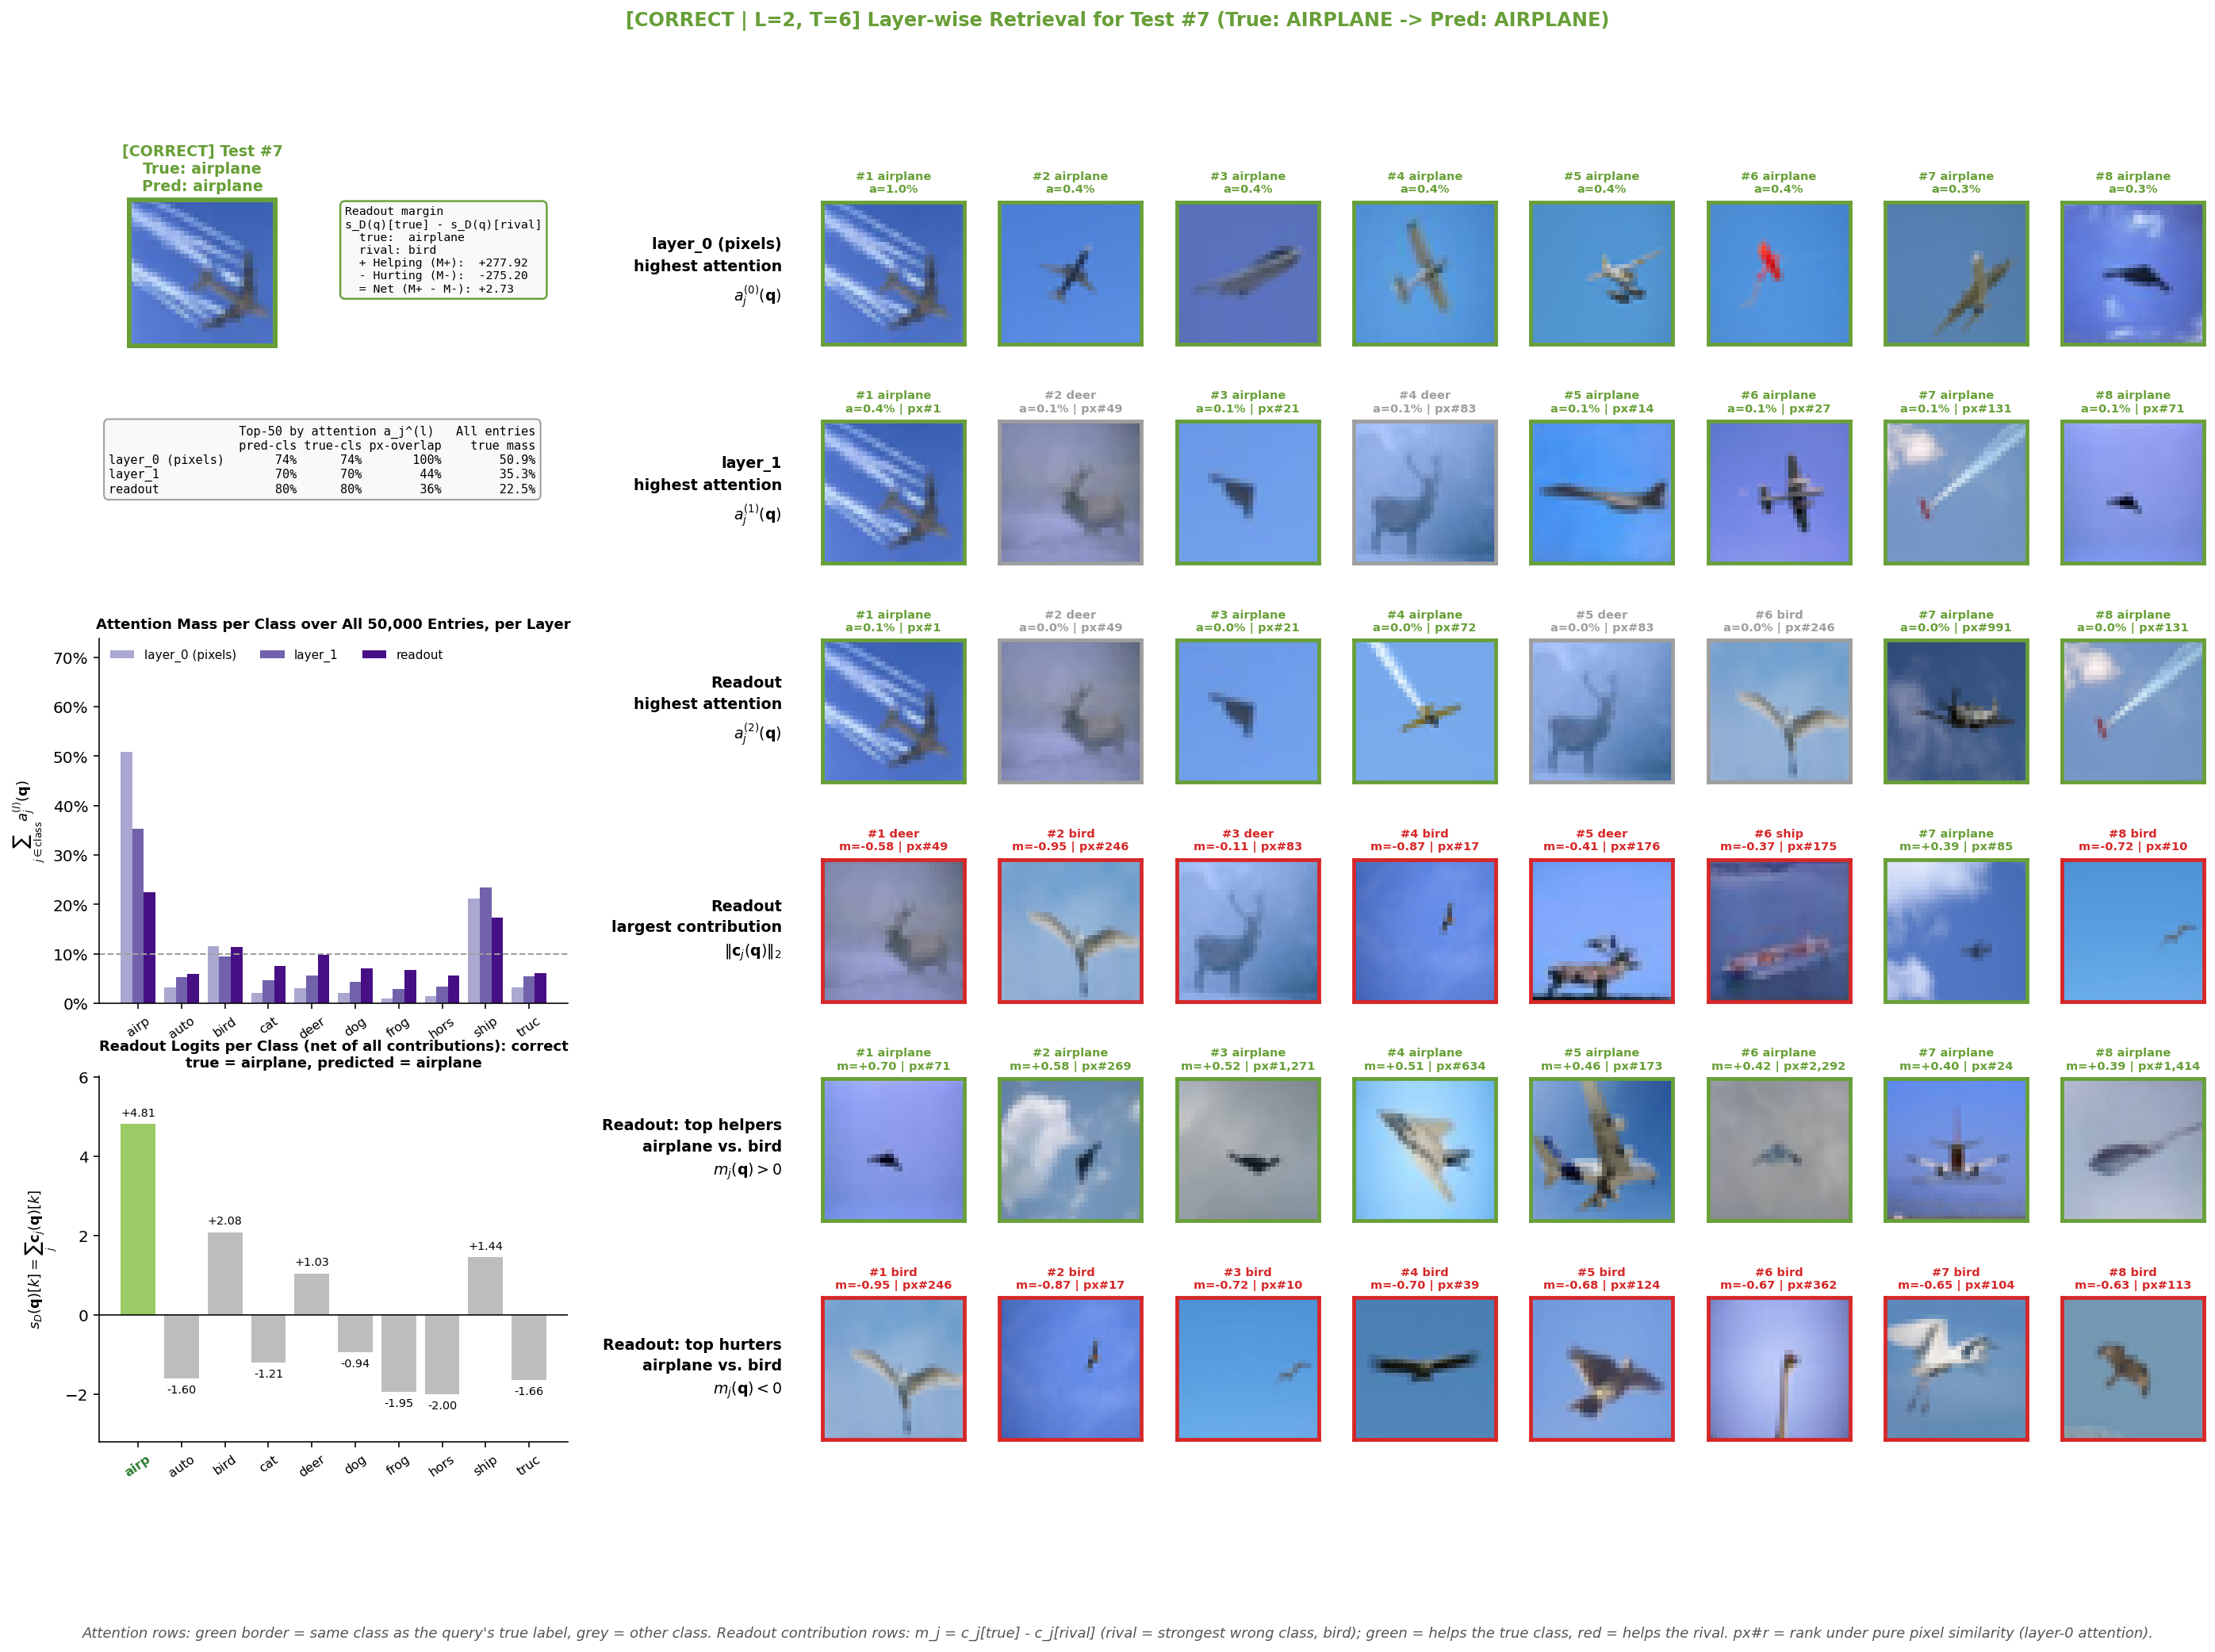

/tmp/ipykernel_579262/767758163.py:451: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.0, 0.02, 1.0, 0.985])


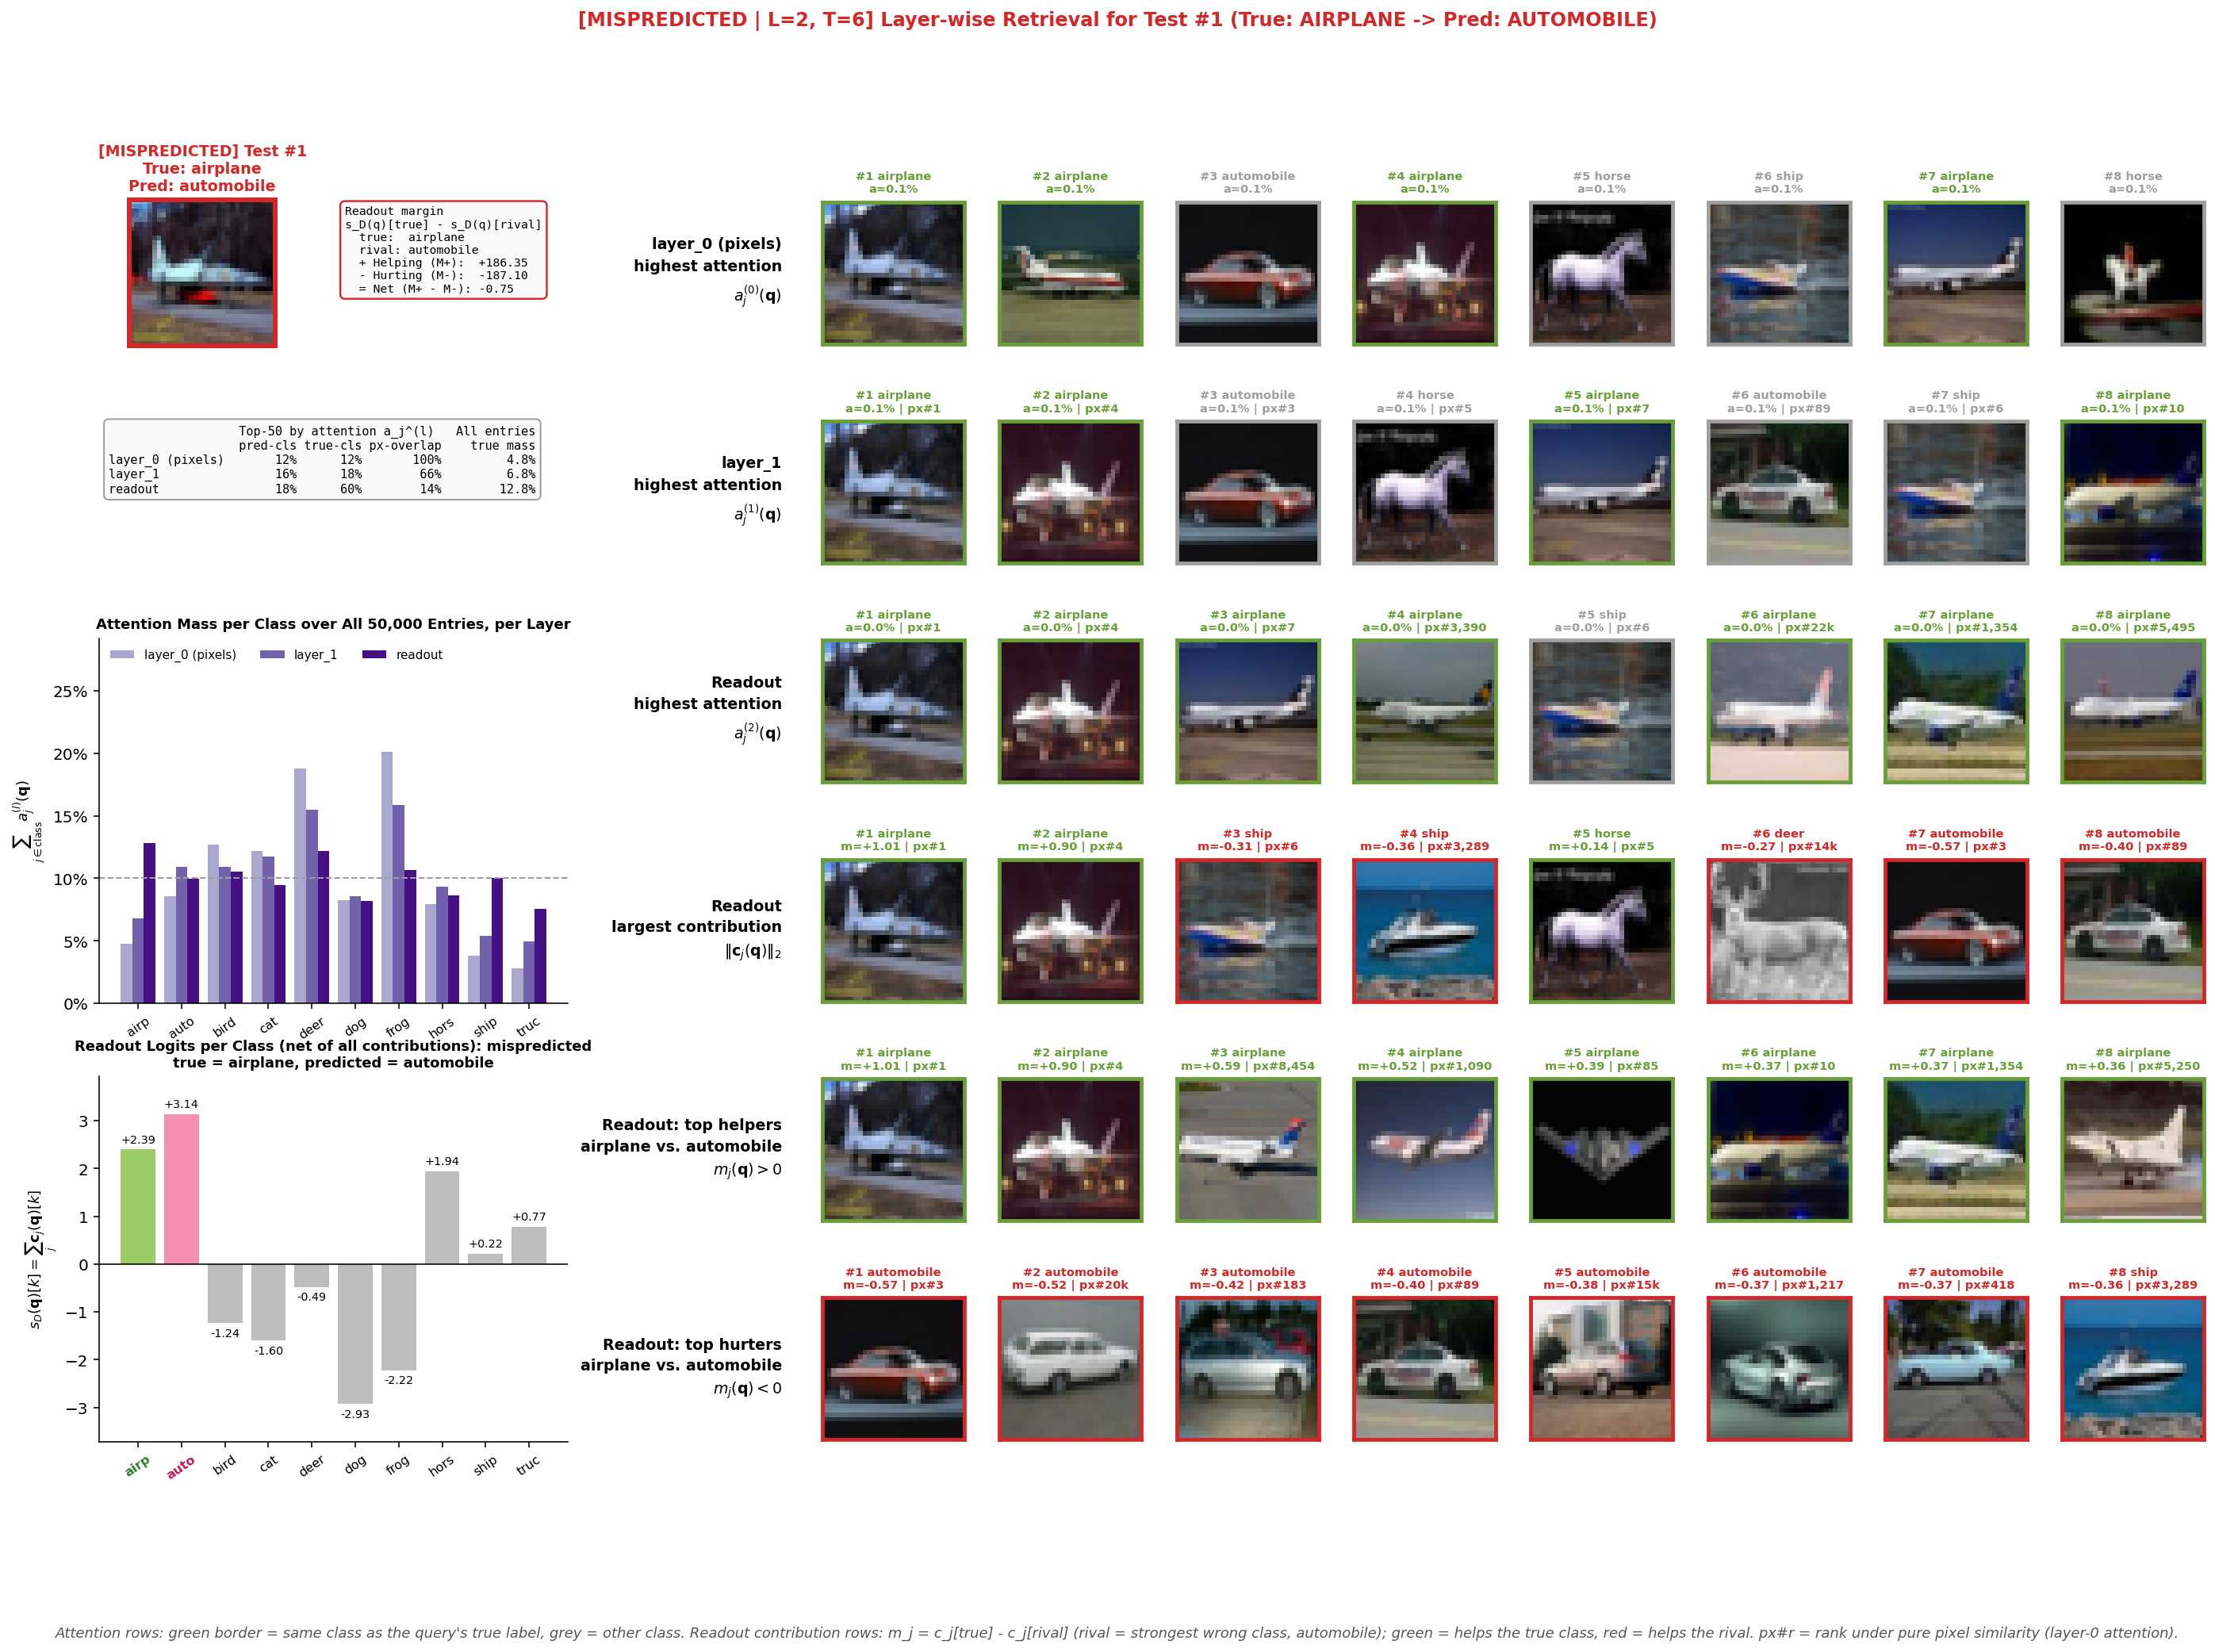

/tmp/ipykernel_579262/767758163.py:451: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.0, 0.02, 1.0, 0.985])


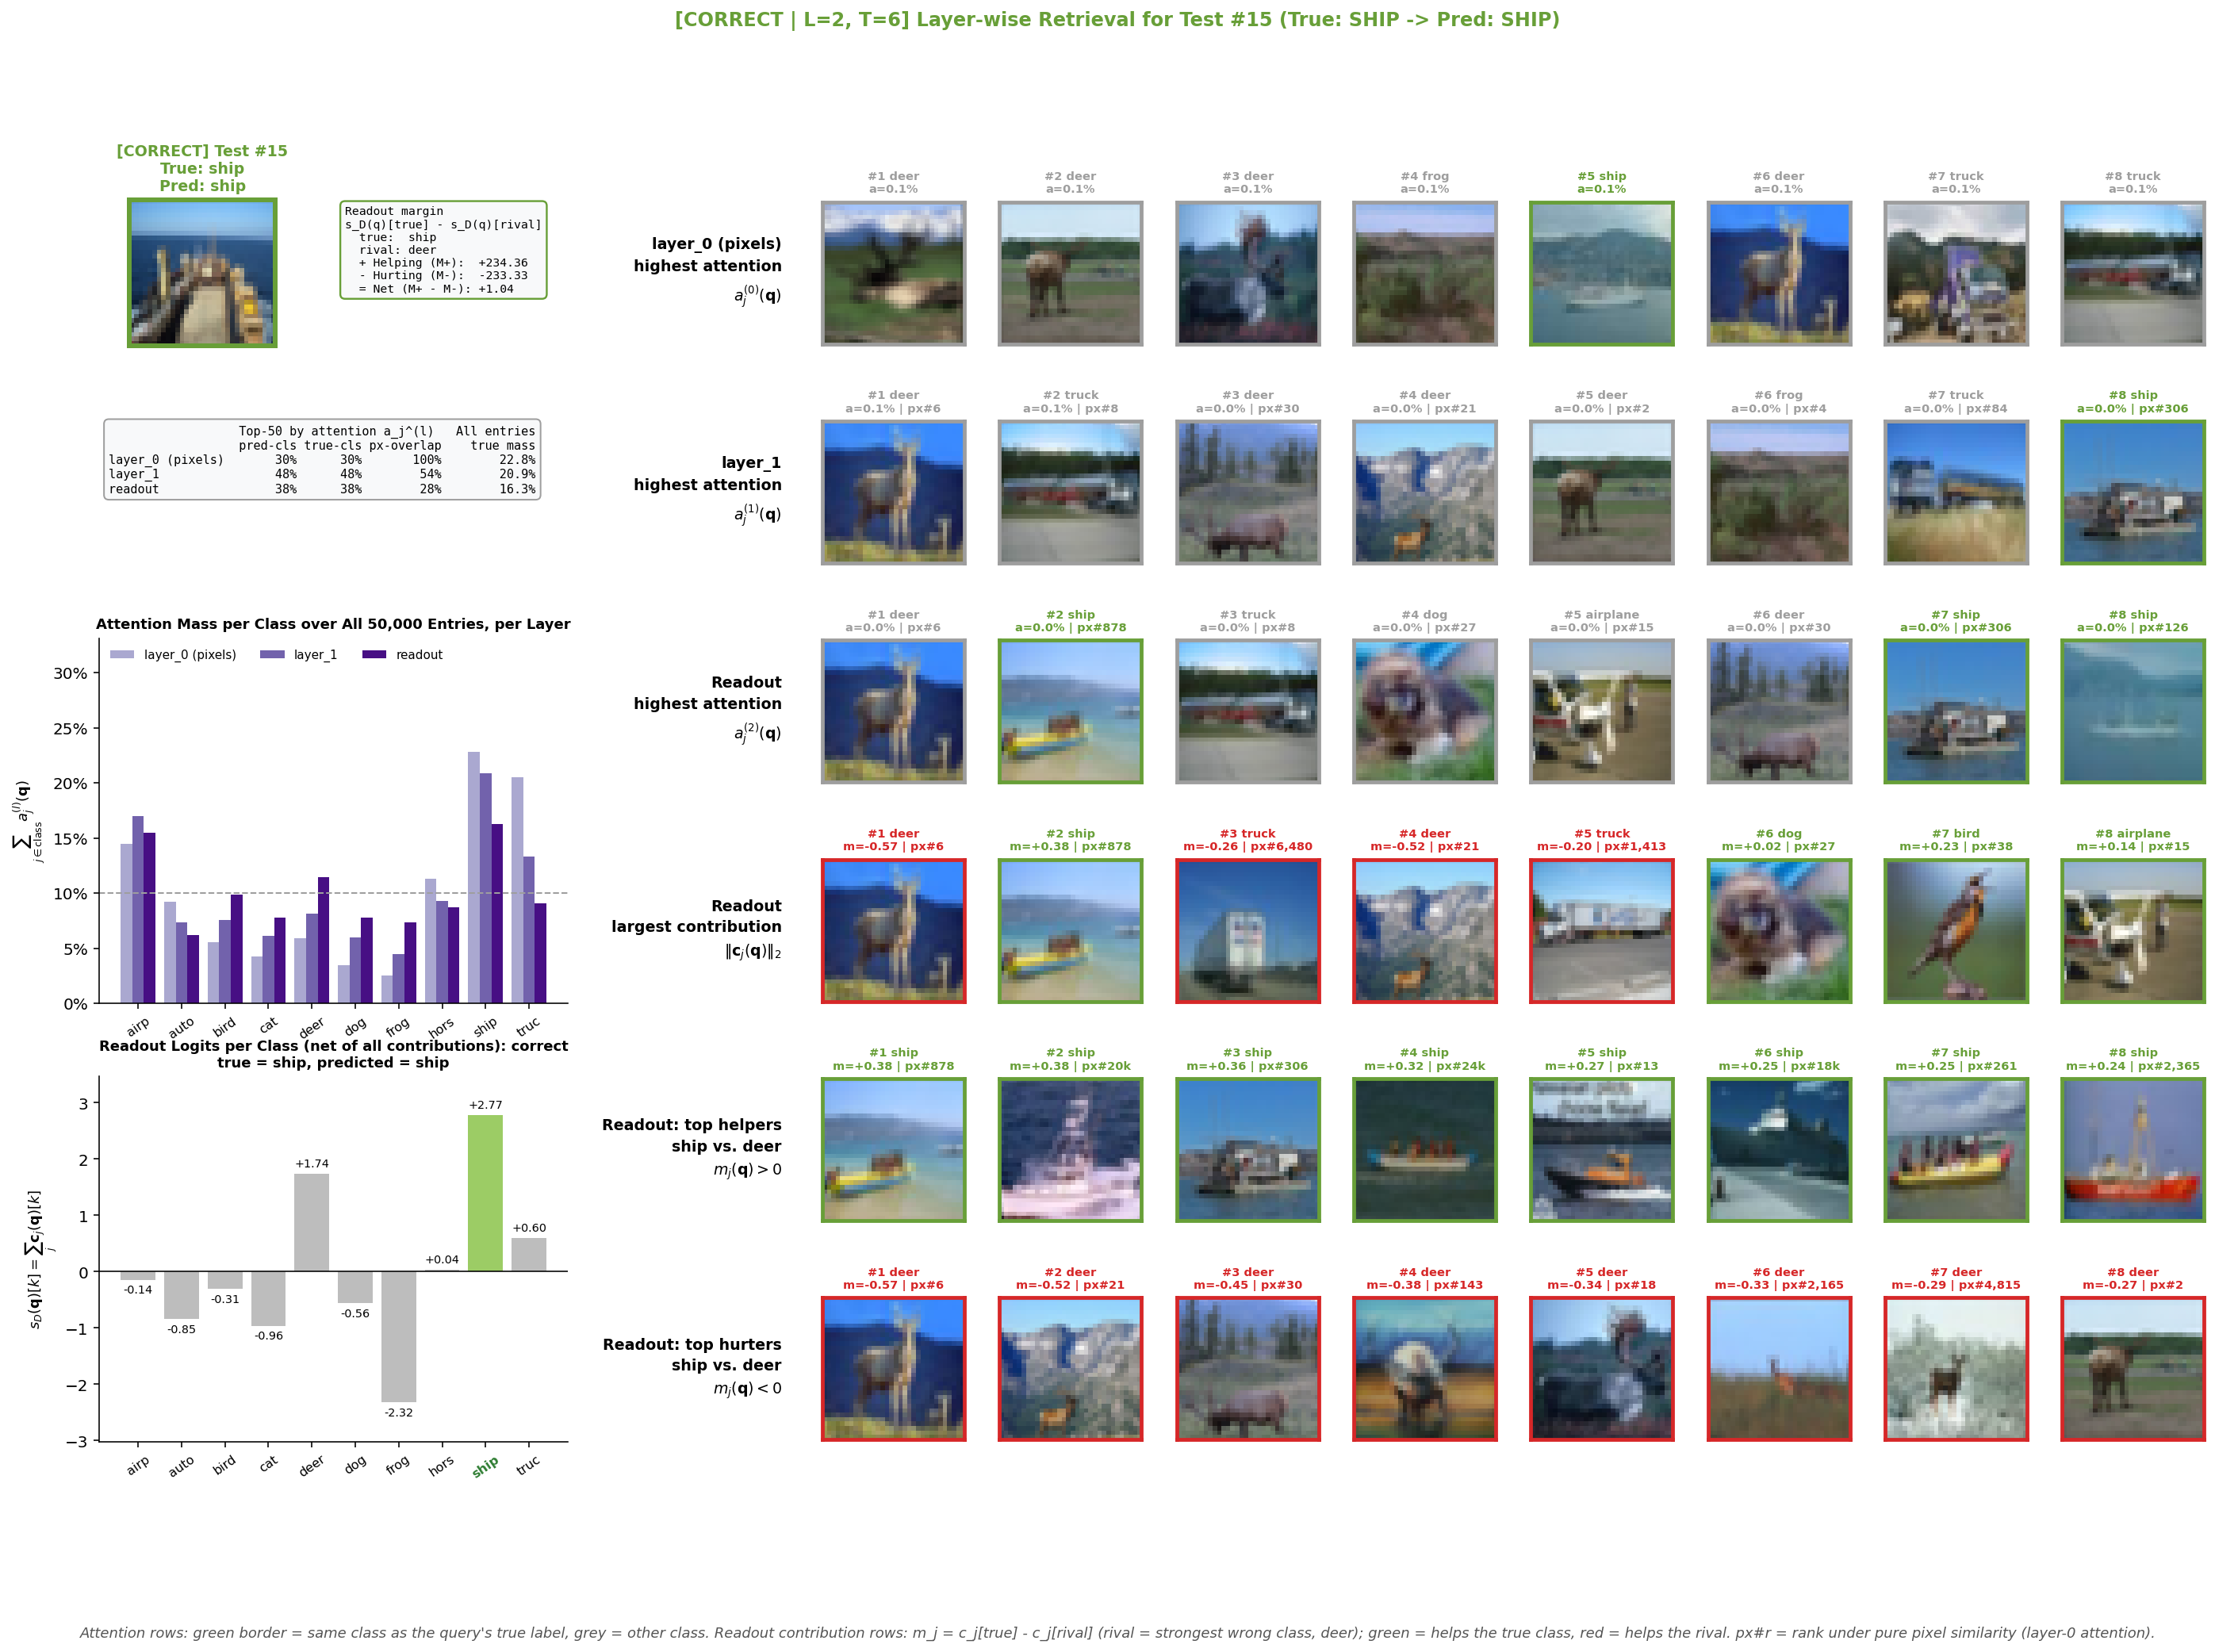

/tmp/ipykernel_579262/767758163.py:451: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.0, 0.02, 1.0, 0.985])


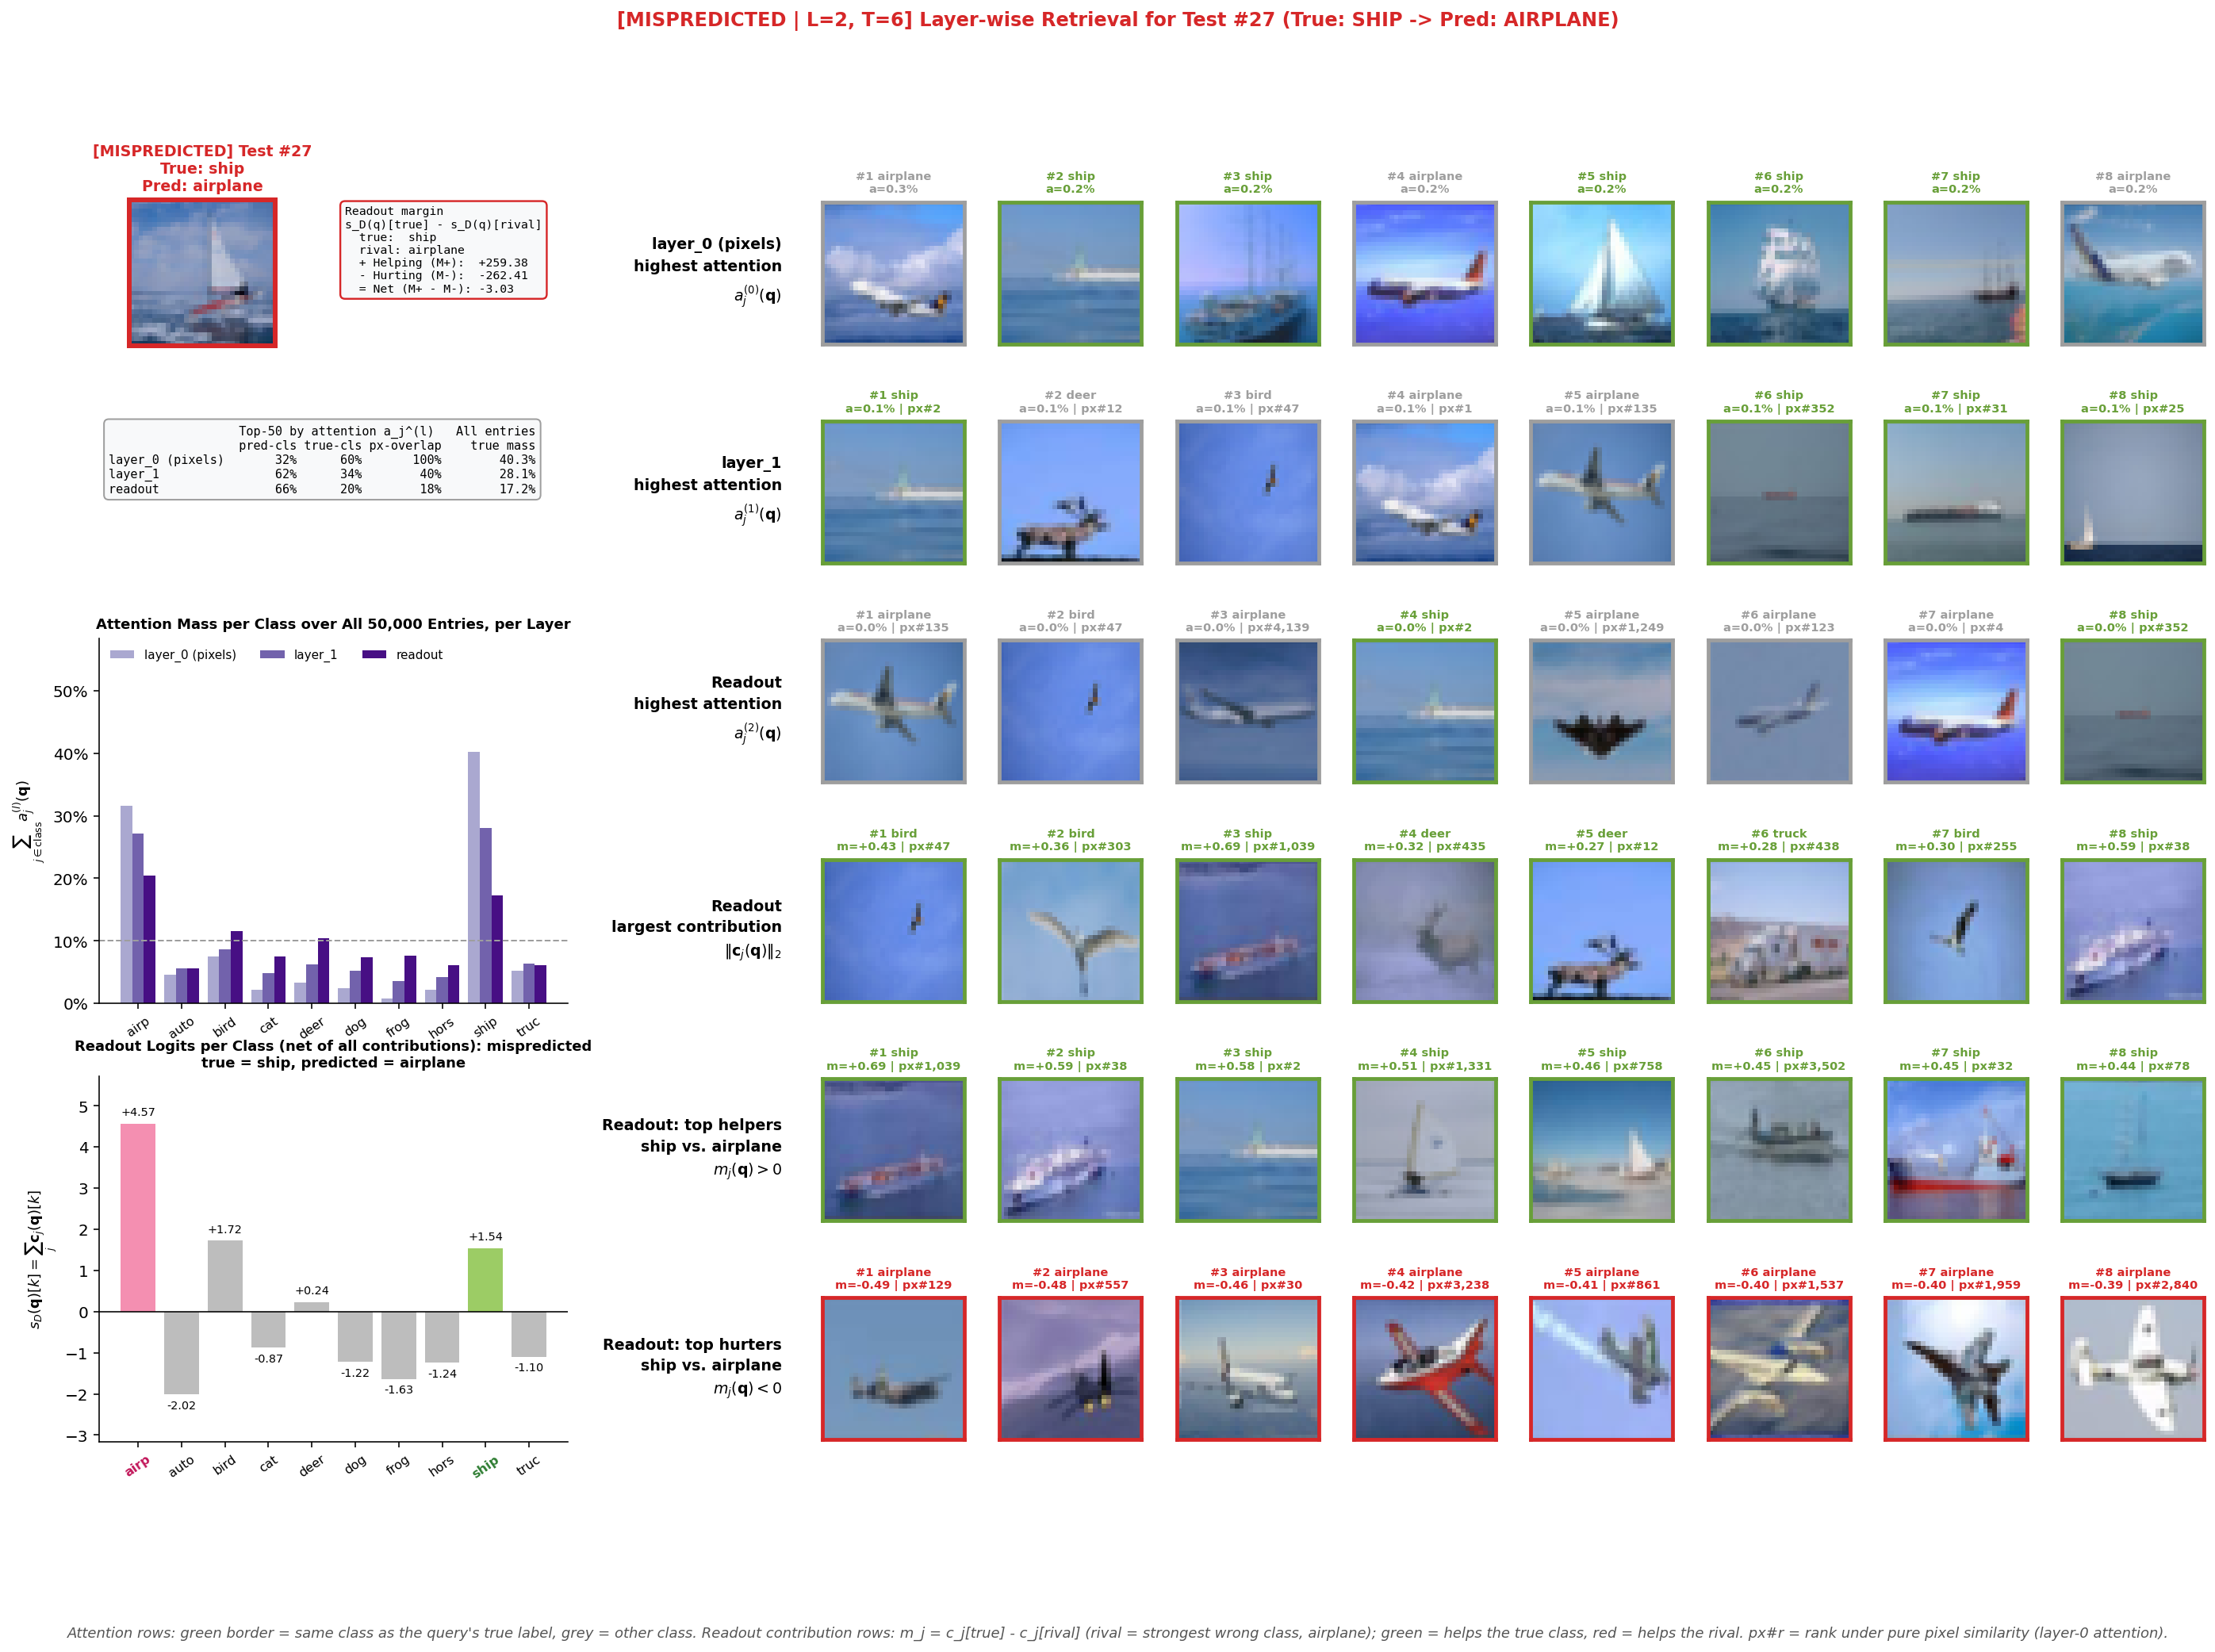

In [ ]:
#@title 11.1 Train (or Reuse) the Best Multi-Layer Growing Weighted Softmax & Explore Layer-wise Retrieval

# --- Model (defaults = best-performing configuration; reuses gws_result from 5.1 if identical) ---
NUM_LAYERS = 2  # @param {type:"integer"}
TEMPERATURE = 6.0  # @param {type:"number"}
BETA = 3.0  # @param {type:"number"}
ETA = 0.003  # @param {type:"number"}
MOMENTUM = 0.0  # @param {type:"number"}
BATCH_SIZE = 16  # @param {type:"integer"}
EVAL_EVERY = 500  # @param {type:"integer"}
FORCE_RETRAIN_DEEP = False  # @param {type:"boolean"}
# --- Explorer display controls ---
PREDICTION_FILTER = "Both (1 Correct + 1 Mispredicted per class)"  # @param ["Both (1 Correct + 1 Mispredicted per class)", "Correctly Predicted Only", "Mispredicted Only"]
QUERY_CLASSES = "airplane, ship"  # @param {type:"string"}
EXAMPLES_PER_MODE = 1  # @param {type:"slider", min:1, max:3, step:1}
TEST_INDICES = ""  # @param {type:"string"}
TOP_K = 8  # @param {type:"slider", min:4, max:12, step:1}
# TEST_INDICES: optional comma-separated test indices (e.g. "12, 345"); overrides the class filter.

CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
]


def unnormalize_cifar(flat_imgs: np.ndarray) -> np.ndarray:
  """Inverts CIFAR_MEAN / CIFAR_STD standardization back to [0, 1] RGB (..., 32, 32, 3)."""
  imgs = flat_imgs.reshape((-1, 32, 32, 3)) * CIFAR_STD + CIFAR_MEAN
  return np.clip(imgs, 0.0, 1.0)


# --- 1. Train or reuse the model --------------------------------------------
if '_gws_deep_model_cache' not in globals():
  _gws_deep_model_cache = {}

_deep_cache_key = (
    int(NUM_LAYERS),
    round(float(TEMPERATURE), 4),
    round(float(BETA), 4),
    round(float(ETA), 6),
    round(float(MOMENTUM), 4),
    int(BATCH_SIZE),
)

# Reuse gws_result from Section 5.1 if it matches the requested hyperparameters
if (
    not FORCE_RETRAIN_DEEP
    and _deep_cache_key not in _gws_deep_model_cache
    and 'gws_result' in globals()
    and gws_result is not None
):
  _c5 = gws_result['cfg']
  if (
      int(_c5.num_layers) == int(NUM_LAYERS)
      and round(float(_c5.temperature), 4) == round(float(TEMPERATURE), 4)
      and round(float(_c5.beta), 4) == round(float(BETA), 4)
      and round(float(_c5.eta), 6) == round(float(ETA), 6)
      and round(float(_c5.model_momentum), 4) == round(float(MOMENTUM), 4)
      and int(_c5.batch_size) == int(BATCH_SIZE)
  ):
    _gws_deep_model_cache[_deep_cache_key] = (_c5, gws_result)

if FORCE_RETRAIN_DEEP or _deep_cache_key not in _gws_deep_model_cache:
  gws_deep_cfg = RCDLConfig(
      kernel_type='gws',
      hidden_dim=3072,
      num_layers=int(NUM_LAYERS),
      temperature=float(TEMPERATURE),
      beta=float(BETA),
      model_momentum=float(MOMENTUM),
      db_size=(50000 // int(BATCH_SIZE)) * int(BATCH_SIZE) + int(BATCH_SIZE),
      learn_norm_params=False,
      num_classes=10,
      batch_size=int(BATCH_SIZE),
      eta=float(ETA),
      learning_rate=3e-4,
      num_epochs=1,
      global_init_seed=1,
  )
  gws_deep_result = run_rcdl_experiment(gws_deep_cfg, eval_every=EVAL_EVERY)
  _ = plot_rcdl_result(gws_deep_result)
  _gws_deep_model_cache[_deep_cache_key] = (gws_deep_cfg, gws_deep_result)
else:
  gws_deep_cfg, gws_deep_result = _gws_deep_model_cache[_deep_cache_key]
  print(
      f'Using cached Growing Weighted Softmax, L={gws_deep_cfg.num_layers} '
      f'(T={gws_deep_cfg.temperature:g}, η={gws_deep_cfg.eta:g}, '
      f'β={gws_deep_cfg.beta:g} | '
      f'Final Test Acc: {gws_deep_result["final_test_acc"]*100:.2f}%)'
  )


# --- 2. Layer-wise forward pass that exposes every layer's attention ---------
def gws_deep_layer_names(cfg: RCDLConfig) -> list[str]:
  return [f'layer_{i}' for i in range(cfg.num_layers)] + ['output_layer']


def gws_deep_layer_label(l_idx: int, cfg: RCDLConfig) -> str:
  if l_idx == cfg.num_layers:
    return 'readout'
  return 'layer_0 (pixels)' if l_idx == 0 else f'layer_{l_idx}'


def gws_deep_layer_data(state: RCDLTrainState, cfg: RCDLConfig) -> list[Dict[str, jax.Array]]:
  """Collects keys, weighted values ṽ_j, weights w_j and validity masks of all layers."""
  out = []
  for lname in gws_deep_layer_names(cfg):
    lp = state.params[lname]
    keys = jnp.asarray(lp['keys'])              # (N, d_in)
    values = jnp.asarray(lp['values'])          # (N, d_out)
    weights = jnp.asarray(lp['weights'][:, 0])  # (N,)
    out.append({
        'keys': keys,
        'values': values,
        'weights': weights,
        'v_norms': jnp.linalg.norm(values, axis=-1),
        'valid': jnp.logical_or(jnp.any(keys != 0.0, axis=-1), weights != 0.0),
    })
  return out


def gws_deep_layer_attention(x: jax.Array, ld: Dict[str, jax.Array], temperature: float):
  """One Growing Weighted Softmax layer (same math as weighted_attention in 3.1).

  Returns z_j, pure attention a_j = softmax(z)_j, effective weights ã_j = e^{z_j} / Σ_m w_m e^{z_m},
  and the layer output s = Σ_j ã_j ṽ_j.
  """
  q = x / jnp.sqrt(jnp.mean(x ** 2, axis=-1, keepdims=True) + 1e-6)  # RMSNorm (no learned scale)
  z = jnp.matmul(q, ld['keys'].T) / (temperature * jnp.sqrt(float(q.shape[-1])))
  z = jnp.where(ld['valid'][None, :], z, -1e9)
  e = jnp.exp(z - jnp.max(z, axis=-1, keepdims=True))
  e = jnp.where(ld['valid'][None, :], e, 0.0)
  a = e / jnp.sum(e, axis=-1, keepdims=True)
  denom = jnp.sum(e * ld['weights'][None, :], axis=-1, keepdims=True)
  sign = jnp.where(jnp.sign(denom) == 0, 1.0, jnp.sign(denom))
  a_tilde = e / (jnp.maximum(jnp.abs(denom), 1e-8) * sign)
  y = jnp.matmul(a_tilde, ld['values'])
  return z, a, a_tilde, y


def make_gws_deep_forward(cfg: RCDLConfig):
  """Builds a jitted forward pass x -> logits that also returns every layer's attention a_j and ã_j."""
  assert not cfg.use_post_norm and not cfg.learn_norm_params, 'Replay assumes the default architecture.'
  act_fn = get_activation_fn(cfg.nonlinearity)
  temperature = float(cfg.temperature)

  @jax.jit
  def forward(layers, bx):
    x = bx
    attns, a_tildes = [], []
    y = None
    for l_idx, ld in enumerate(layers):
      _, a, a_tilde, y = gws_deep_layer_attention(x, ld, temperature)
      attns.append(a)
      a_tildes.append(a_tilde)
      if l_idx < len(layers) - 1:
        y = act_fn(y)
        x = (x + y) if cfg.use_residual else y
    return y, attns, a_tildes

  return forward


gws_deep_state = gws_deep_result['state']
gws_deep_layers = gws_deep_layer_data(gws_deep_state, gws_deep_cfg)
gws_deep_forward = make_gws_deep_forward(gws_deep_cfg)
_deep_fwd_bs = int(gws_deep_cfg.batch_size)  # fixed batch shape -> a single compilation


def gws_deep_run(test_idx_list: list[int], with_attn: bool = True):
  """Runs the replayed forward pass on test images (padded to a fixed batch size)."""
  idx = np.asarray(test_idx_list, dtype=np.int64)
  pad = (-len(idx)) % _deep_fwd_bs
  idx_p = np.concatenate([idx, np.repeat(idx[-1:], pad)])
  logits_all, attn_all, at_all = [], [], []
  for i in range(0, len(idx_p), _deep_fwd_bs):
    lg, at, att = gws_deep_forward(gws_deep_layers, jnp.asarray(test_images[idx_p[i:i + _deep_fwd_bs]]))
    logits_all.append(np.asarray(lg))
    if with_attn:
      attn_all.append([np.asarray(v) for v in at])
      at_all.append([np.asarray(v) for v in att])
  n = len(idx)
  logits = np.concatenate(logits_all)[:n]
  if not with_attn:
    return logits, None, None
  attns = [np.concatenate([b[l] for b in attn_all])[:n] for l in range(len(gws_deep_layers))]
  a_tildes = [np.concatenate([b[l] for b in at_all])[:n] for l in range(len(gws_deep_layers))]
  return logits, attns, a_tildes


# --- 3. Sanity checks: replay == model, and entry j <-> training image -------
_n_init = int(gws_deep_cfg.batch_size)   # |D_0| = B random initial entries
_ref_vars = {'params': gws_deep_state.params}
_ref_vars.update(gws_deep_state.model_state)
_ref_logits = np.asarray(gws_deep_state.apply_fn(
    _ref_vars, jnp.asarray(test_images[:_deep_fwd_bs]), training=False))
_rep_logits = gws_deep_run(list(range(_deep_fwd_bs)), with_attn=False)[0]
print(f'Replayed forward pass vs. model: max |Δ logits| = '
      f'{float(np.max(np.abs(_ref_logits - _rep_logits))):.2e}')

deep_perm = np.asarray(jax.random.permutation(
    jax.random.fold_in(jax.random.PRNGKey(gws_deep_cfg.global_init_seed), 1),
    train_images.shape[0]))
_n_db = int(gws_deep_layers[0]['keys'].shape[0])
_n_train_entries = min(_n_db - _n_init, len(deep_perm))
deep_entry_train_idx = np.full((_n_db,), -1, dtype=np.int64)  # -1 = random initial entry (D_0)
deep_entry_train_idx[_n_init:_n_init + _n_train_entries] = deep_perm[:_n_train_entries]
deep_entry_labels = np.where(
    deep_entry_train_idx >= 0, train_labels[np.maximum(deep_entry_train_idx, 0)], -1)

_chk = train_images[deep_perm[:64]]
_chk = _chk / np.sqrt(np.mean(_chk ** 2, axis=-1, keepdims=True) + 1e-6)
_k0 = np.asarray(gws_deep_layers[0]['keys'][_n_init:_n_init + 64])
print(f'Verified entry alignment ({gws_deep_layer_names(gws_deep_cfg)[0]} entries {_n_init}.. '
      f'<-> train_images[deep_perm]): max |key - RMSNorm(img)| = {float(np.max(np.abs(_k0 - _chk))):.2e}')


# --- 4. Per-query layer-wise attribution -------------------------------------
def compute_gws_deep_attribution(test_idx: int, top_stats: int = 50) -> Dict[str, Any]:
  """Per-layer pure attention a_j^(l), contribution norms, and exact readout contributions c_j(q)."""
  logits, attns, a_tildes = gws_deep_run([test_idx])
  logits = logits[0]
  true_label = int(test_labels[test_idx])
  pred_label = int(np.argmax(logits))
  tr = slice(_n_init, _n_init + _n_train_entries)  # restrict to entries written by training images
  t_labels = deep_entry_labels[tr]

  layers = []
  for l_idx, ld in enumerate(gws_deep_layers):
    a = 100.0 * attns[l_idx][0][tr]                                            # % of attention mass
    mag = np.abs(a_tildes[l_idx][0][tr]) * np.asarray(ld['v_norms'])[tr]      # ||c_j^(l)(q)||_2
    layers.append({'attn': a, 'mag': mag, 'order': np.argsort(-a)})

  # Rank of every entry under pure pixel similarity (= layer-0 attention)
  px_rank = np.empty(_n_train_entries, dtype=np.int64)
  px_rank[layers[0]['order']] = np.arange(_n_train_entries)

  top0 = set(layers[0]['order'][:top_stats].tolist())
  for lay in layers:
    top = lay['order'][:top_stats]
    lay['purity_pred'] = 100.0 * float(np.mean(t_labels[top] == pred_label))
    lay['purity_true'] = 100.0 * float(np.mean(t_labels[top] == true_label))
    lay['pixel_overlap'] = 100.0 * len(top0.intersection(top.tolist())) / float(top_stats)
    # Attention mass per class over ALL entries written by training images (in % of the layer's total mass)
    lay['class_mass'] = np.bincount(t_labels, weights=lay['attn'], minlength=10)

  # Exact readout decomposition: s_D(q) = Σ_j c_j(q), c_j(q) = ã_j(q) ṽ_j
  values_out = np.asarray(gws_deep_layers[-1]['values'])[tr]
  contrib = a_tildes[-1][0][tr][:, None] * values_out                # (n_train, 10)
  # Margin view: rival r = strongest wrong class; m_j(q) = c_j(q)[y] - c_j(q)[r] sums to the
  # margin s_D(q)[y] - s_D(q)[r], which is > 0 iff the prediction is correct.
  rival_label = int(np.argmax(np.where(np.arange(logits.shape[0]) == true_label, -np.inf, logits)))
  margin_scores = contrib[:, true_label] - contrib[:, rival_label]

  return {
      'test_idx': test_idx,
      'true_label': true_label,
      'pred_label': pred_label,
      'logits': logits,
      'layers': layers,
      'px_rank': px_rank,
      'rival_label': rival_label,
      'margin_scores': margin_scores,
      'contrib': contrib,
      'm_plus': float(np.sum(margin_scores[margin_scores > 0])),
      'm_minus': float(np.sum(np.abs(margin_scores[margin_scores < 0]))),
      'train_labels_ordered': t_labels,
      'train_idx_ordered': deep_entry_train_idx[tr],
      'top_stats': top_stats,
  }


def _fmt_rank(r: int) -> str:
  return f'{r:,}' if r < 10000 else f'{r / 1000:.0f}k'


def plot_readout_logits(ax, contrib: np.ndarray, true_c: int, pred_c: int):
  """Net readout logits s_D(q)[k] = Σ_j c_j(q)[k] for all 10 classes (after all cancellations).

  The highest bar is the predicted class. Green = true class, pink = predicted class if wrong.
  """
  logits = np.sum(contrib, axis=0)   # (10,)
  x_idx = np.arange(logits.shape[0])
  cols = ['#9ccc65' if k == true_c else ('#f48fb1' if k == pred_c else '#bdbdbd') for k in x_idx]
  ax.bar(x_idx, logits, color=cols)
  ax.axhline(0.0, color='black', lw=0.8)
  span = max(1e-6, float(np.max(np.abs(logits))))
  for xi, v in zip(x_idx, logits):
    ax.text(xi, v + (0.03 if v >= 0 else -0.03) * span, f'{v:+.2f}', ha='center',
            va='bottom' if v >= 0 else 'top', fontsize=7.2)
  ax.set_ylim(min(0.0, float(logits.min())) - 0.25 * span, max(0.0, float(logits.max())) + 0.25 * span)
  ax.set_xticks(x_idx)
  ax.set_xticklabels([c[:4] for c in CIFAR10_CLASSES], rotation=35, fontsize=8)
  for k, tl in enumerate(ax.get_xticklabels()):
    if k in (true_c, pred_c):
      tl.set_color('#2e7d32' if k == true_c else '#c2185b')
      tl.set_fontweight('bold')
  ax.set_ylabel(r'$s_D(\mathbf{q})[k] = \sum_j \mathbf{c}_j(\mathbf{q})[k]$', fontsize=9)
  verdict = 'correct' if pred_c == true_c else 'mispredicted'
  ax.set_title(f'Readout Logits per Class (net of all contributions): {verdict}\n'
               f'true = {CIFAR10_CLASSES[true_c]}, predicted = {CIFAR10_CLASSES[pred_c]}',
               fontsize=9, weight='bold')
  for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)


def plot_gws_deep_attribution(attr: Dict[str, Any], cfg: RCDLConfig, top_k: int = 8):
  """Rows: top-K by attention in every layer, then the readout's contribution, margin-helper & margin-hurter rows."""
  test_idx, true_c, pred_c = attr['test_idx'], attr['true_label'], attr['pred_label']
  is_correct = (true_c == pred_c)
  layers = attr['layers']
  n_lay = len(layers)
  t_labels = attr['train_labels_ordered']
  t_idx = attr['train_idx_ordered']
  rival_c = attr['rival_label']
  signed = attr['margin_scores']   # m_j(q) = c_j(q)[true] - c_j(q)[rival] at the readout
  px_rank = attr['px_rank']
  readout = layers[-1]
  pred_name = CIFAR10_CLASSES[pred_c]
  true_name, rival_name = CIFAR10_CLASSES[true_c], CIFAR10_CLASSES[rival_c]
  vs_str = f'{true_name} vs. {rival_name}'
  match_col = '#689f38' if is_correct else '#d62728'
  verdict_str = 'CORRECT' if is_correct else 'MISPREDICTED'
  n_stat = attr['top_stats']

  # (row label, entry indices, row type, layer index)
  row_configs = []
  for l_idx in range(n_lay):
    lbl = gws_deep_layer_label(l_idx, cfg)
    if l_idx == cfg.num_layers:
      lbl = 'Readout'
    row_configs.append((
        f'{lbl}\nhighest attention\n' + rf'$a^{{({l_idx})}}_j(\mathbf{{q}})$',
        layers[l_idx]['order'][:top_k], 'attn', l_idx))
  row_configs += [
      ('Readout\nlargest contribution\n' + r'$\Vert\mathbf{c}_j(\mathbf{q})\Vert_2$',
       np.argsort(-readout['mag'])[:top_k], 'mag', n_lay - 1),
      (f'Readout: top helpers\n{vs_str}\n' + r'$m_j(\mathbf{q}) > 0$',
       np.argsort(-signed)[:top_k], 'pos', n_lay - 1),
      (f'Readout: top hurters\n{vs_str}\n' + r'$m_j(\mathbf{q}) < 0$',
       np.argsort(signed)[:top_k], 'neg', n_lay - 1),
  ]
  n_rows = len(row_configs)

  n_left = 3
  fig = plt.figure(figsize=(2.05 * (top_k + 3.6), 2.3 * n_rows + 0.6))
  gs = fig.add_gridspec(n_rows, top_k + n_left, width_ratios=[1.45, 1.6, 1.3] + [1.0] * top_k,
                        hspace=0.5, wspace=0.22)

  # --- Query image ---
  ax_q = fig.add_subplot(gs[0, 0])
  ax_q.imshow(unnormalize_cifar(test_images[test_idx])[0])
  ax_q.set_title(f'[{verdict_str}] Test #{test_idx}\nTrue: {CIFAR10_CLASSES[true_c]}\n'
                 f'Pred: {pred_name}', fontsize=9.5, weight='bold', color=match_col)
  for spine in ax_q.spines.values():
    spine.set_edgecolor(match_col)
    spine.set_linewidth(3.0)
  ax_q.set_xticks([])
  ax_q.set_yticks([])

  # --- Readout margin decomposition ---
  ax_stat = fig.add_subplot(gs[0, 1])
  ax_stat.axis('off')
  stat_txt = (f"Readout margin\n"
              f"s_D(q)[true] - s_D(q)[rival]\n"
              f"  true:  {true_name}\n"
              f"  rival: {rival_name}\n"
              f"  + Helping (M+):  +{attr['m_plus']:.2f}\n"
              f"  - Hurting (M-):  -{attr['m_minus']:.2f}\n"
              f"  = Net (M+ - M-): {attr['m_plus'] - attr['m_minus']:+.2f}")
  ax_stat.text(0.02, 0.96, stat_txt, va='top', ha='left', fontsize=7.4, family='monospace',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor=match_col, lw=1.2))

  # --- Depth table: purity & pixel overlap of the top-50 by attention per layer ---
  ax_tab = fig.add_subplot(gs[1, 0:2])
  ax_tab.axis('off')
  tab_txt = (f"{'':<17}{'Top-' + str(n_stat) + ' by attention a_j^(l)':^29}{'All entries':>13}\n"
             f"{'':<17}{'pred-cls':>9}{'true-cls':>9}{'px-overlap':>11}{'true mass':>13}\n")
  for l_idx, lay in enumerate(layers):
    tab_txt += (f"{gws_deep_layer_label(l_idx, cfg):<17}{lay['purity_pred']:>8.0f}%"
                f"{lay['purity_true']:>8.0f}%{lay['pixel_overlap']:>10.0f}%"
                f"{lay['class_mass'][true_c]:>12.1f}%\n")
  ax_tab.text(0.02, 0.96, tab_txt.rstrip('\n'), va='top', ha='left', fontsize=7.6, family='monospace',
              bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='#9e9e9e', lw=1.0))

  # --- Attention mass per class over ALL entries, per layer ---
  h_rows = max(1, (n_rows - 2) // 2)
  ax_hist = fig.add_subplot(gs[2:2 + h_rows, 0:2])
  x_idx = np.arange(10)
  bar_w = 0.8 / n_lay
  lay_cols = plt.cm.Purples(np.linspace(0.45, 0.95, n_lay))
  max_mass = 10.0
  for l_idx, lay in enumerate(layers):
    max_mass = max(max_mass, float(lay['class_mass'].max()))
    ax_hist.bar(x_idx - 0.4 + bar_w * (l_idx + 0.5), lay['class_mass'], width=bar_w,
                color=lay_cols[l_idx], label=gws_deep_layer_label(l_idx, cfg))
  ax_hist.axhline(10.0, ls='--', lw=1.0, color='#9e9e9e')
  ax_hist.set_xticks(x_idx)
  ax_hist.set_xticklabels([c[:4] for c in CIFAR10_CLASSES], rotation=35, fontsize=8)
  ax_hist.set_ylabel(r'$\sum_{j \in \mathrm{class}} a^{(l)}_j(\mathbf{q})$', fontsize=9)
  ax_hist.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))
  ax_hist.set_title(f'Attention Mass per Class over All {len(t_labels):,} Entries, per Layer',
                    fontsize=9, weight='bold')
  ax_hist.set_ylim(0, 1.45 * max_mass)
  ax_hist.legend(fontsize=7.6, loc='upper left', frameon=False, ncol=min(3, n_lay))
  for sp in ('top', 'right'):
    ax_hist.spines[sp].set_visible(False)

  # --- Readout: net logits per class ---
  if 2 + h_rows < n_rows:
    ax_cancel = fig.add_subplot(gs[2 + h_rows:, 0:2])
    plot_readout_logits(ax_cancel, attr['contrib'], true_c, pred_c)

  # --- Thumbnail rows ---
  for row_i, (row_label, indices, r_type, l_idx) in enumerate(row_configs):
    ax_lbl = fig.add_subplot(gs[row_i, n_left - 1])
    ax_lbl.axis('off')
    ax_lbl.text(0.97, 0.5, row_label, ha='right', va='center', fontsize=9.5,
                weight='bold', linespacing=1.5, transform=ax_lbl.transAxes)
    for rank, entry_i in enumerate(indices):
      ax = fig.add_subplot(gs[row_i, rank + n_left])
      ax.imshow(unnormalize_cifar(train_images[int(t_idx[entry_i])])[0])
      cls_i = int(t_labels[entry_i])
      a_val = float(layers[l_idx]['attn'][entry_i])
      px_str = f'px#{_fmt_rank(int(px_rank[entry_i]) + 1)}'
      if r_type == 'attn':
        border_col = '#689f38' if cls_i == true_c else '#9e9e9e'
        sub_txt = f'a={a_val:.1f}%' if l_idx == 0 else f'a={a_val:.1f}% | {px_str}'
      else:
        s_val = float(signed[entry_i])
        border_col = '#689f38' if s_val >= 0 else '#d62728'
        sub_txt = f'm={s_val:+.2f} | {px_str}'
      for spine in ax.spines.values():
        spine.set_edgecolor(border_col)
        spine.set_linewidth(2.4)
      ax.set_xticks([])
      ax.set_yticks([])
      ax.set_title(f'#{rank + 1} {CIFAR10_CLASSES[cls_i]}\n{sub_txt}',
                   fontsize=7.3, color=border_col, weight='bold')

  fig.suptitle(
      f'[{verdict_str} | L={cfg.num_layers}, T={cfg.temperature:g}] Layer-wise Retrieval for '
      f'Test #{test_idx} (True: {CIFAR10_CLASSES[true_c].upper()} -> Pred: {pred_name.upper()})',
      fontsize=12, weight='bold', color=match_col, y=0.995)
  fig.text(0.5, 0.004,
           'Attention rows: green border = same class as the query\'s true label, grey = other class. '
           f'Readout contribution rows: m_j = c_j[true] - c_j[rival] (rival = strongest wrong class, {rival_name}); '
           'green = helps the true class, red = helps the rival. '
           'px#r = rank under pure pixel similarity (layer-0 attention).',
           ha='center', va='bottom', fontsize=9, style='italic', color='#555555')
  plt.tight_layout(rect=[0.0, 0.02, 1.0, 0.985])
  plt.show()
  return fig


# --- 5. Select queries & plot -----------------------------------------------
_explicit_idx = [int(s) for s in TEST_INDICES.replace(';', ',').split(',') if s.strip().isdigit()]
_explicit_idx = [i for i in _explicit_idx if 0 <= i < test_images.shape[0]]

if _explicit_idx:
  for tid in _explicit_idx:
    _ = plot_gws_deep_attribution(compute_gws_deep_attribution(tid), gws_deep_cfg, top_k=int(TOP_K))
else:
  parsed_classes = [c.strip().lower() for c in QUERY_CLASSES.split(',')
                    if c.strip().lower() in CIFAR10_CLASSES] or ['airplane']
  want_correct = PREDICTION_FILTER in ("Both (1 Correct + 1 Mispredicted per class)",
                                       "Correctly Predicted Only")
  want_mispred = PREDICTION_FILTER in ("Both (1 Correct + 1 Mispredicted per class)",
                                       "Mispredicted Only")
  for cls_name in parsed_classes:
    target_cid = CIFAR10_CLASSES.index(cls_name)
    cand = np.where(test_labels == target_cid)[0][:250]
    cand_pred = np.argmax(gws_deep_run(list(cand), with_attn=False)[0], axis=-1)
    chosen = []
    if want_correct:
      chosen += list(cand[cand_pred == target_cid][:EXAMPLES_PER_MODE])
    if want_mispred:
      chosen += list(cand[cand_pred != target_cid][:EXAMPLES_PER_MODE])
    for tid in chosen:
      _ = plot_gws_deep_attribution(
          compute_gws_deep_attribution(int(tid)), gws_deep_cfg, top_k=int(TOP_K))


Depth statistics (L=2, top-50):   0%|          | 0/50 [00:00<?, ?it/s]


Depth statistics over the test set (1.7s, replayed test acc. 59.23%):
Layer              | Purity (a_j) | Purity (||c_j||) | Px-overlap (a_j) | Px-overlap (||c_j||) | Mass on D_0
-------------------------------------------------------------------------------------------------------------
layer_0 (pixels)   |        28.1% |            19.3% |           100.0% |                42.9% |        0.0%
layer_1            |        33.0% |            20.6% |            55.5% |                33.2% |        0.0%
readout            |        36.2% |            19.4% |            32.4% |                20.3% |        0.0%


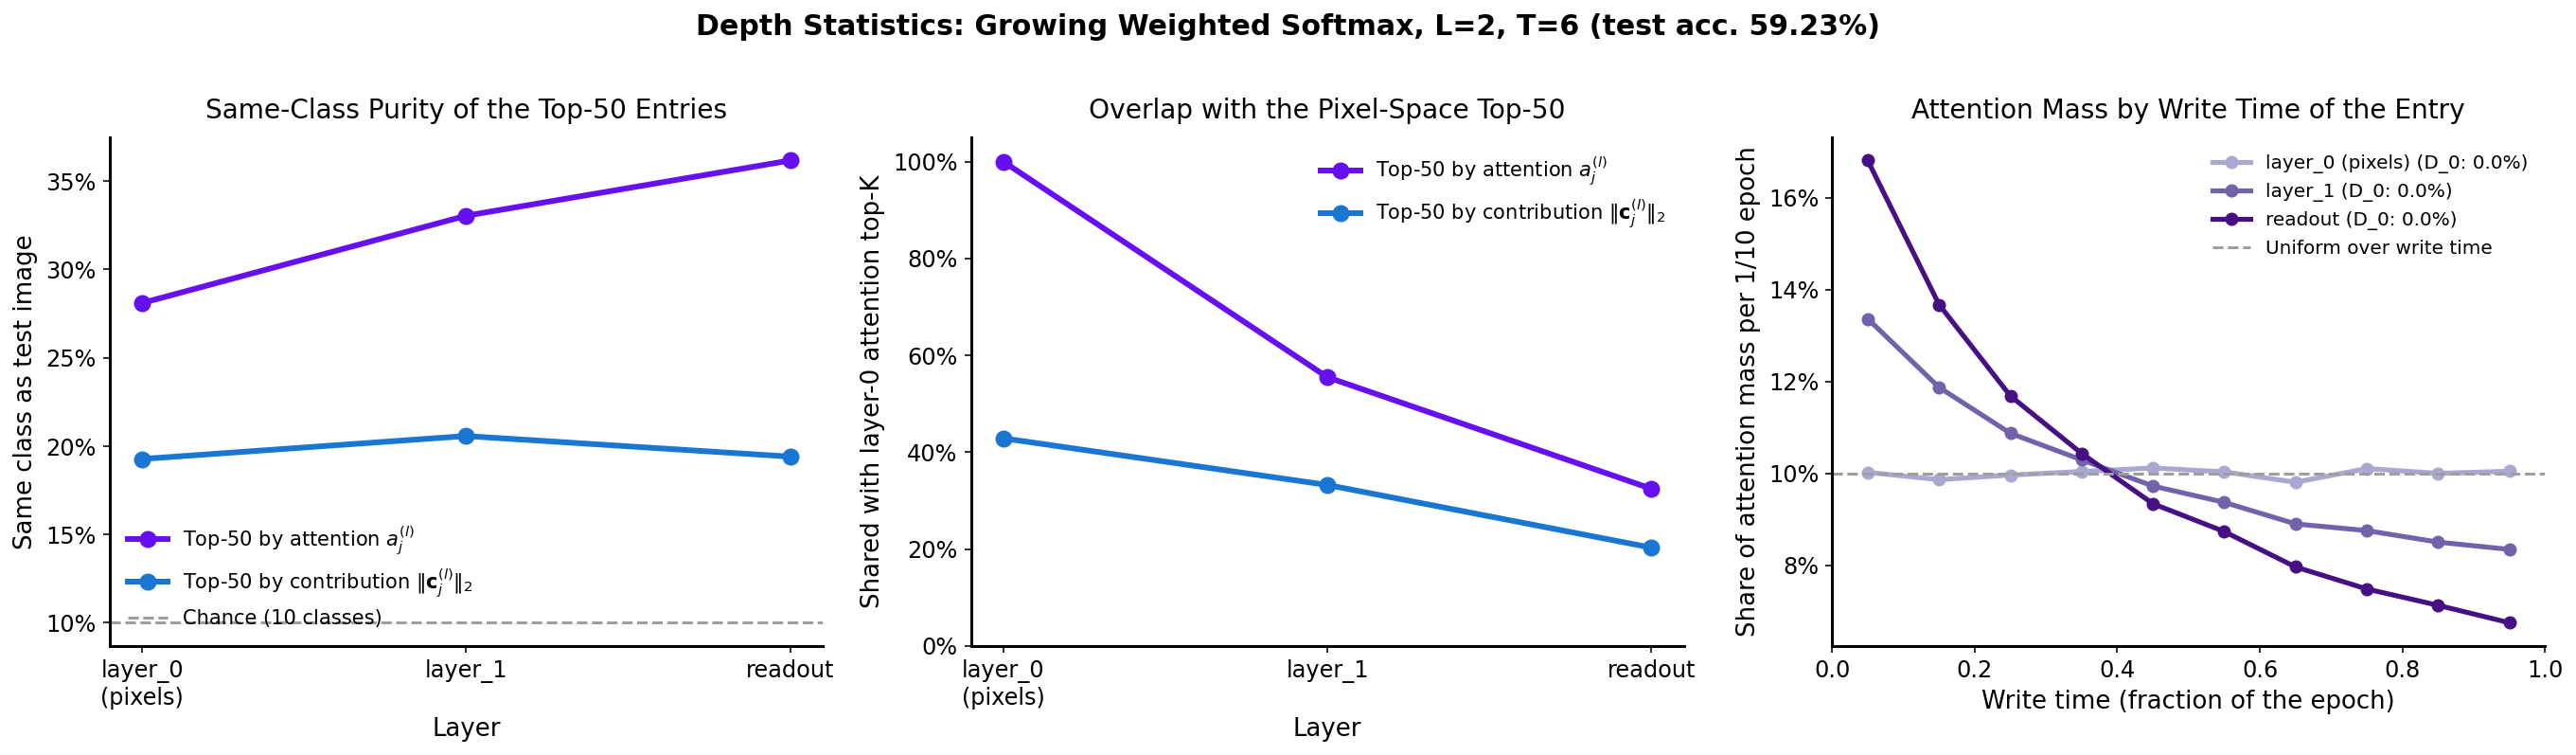

In [ ]:
#@title 11.2 Depth Statistics: Does Retrieval Become More Semantic with Depth?

# Over all 10,000 test images and for every layer l of the model from 11.1, computes:
#   1. Same-class purity: fraction of the top-K entries (by attention a_j^(l) or by contribution
#      ||c_j^(l)||_2 = ã_j^(l) ||ṽ_j^(l)||_2) written by a training image of the test image's class.
#   2. Pixel overlap: fraction of the top-K entries that are also in the pixel-space top-K
#      (= top-K by layer-0 attention, whose query is the RMS-normalized image).
#   3. Attention mass by write time: share of the attention mass a_j^(l) on entries written in each
#      part of the epoch (keys of early entries were written with a much smaller database).
# The B random initial entries (D_0) are excluded from all rankings; their attention mass is reported separately.

STATS_TOP_K = 50  # @param {type:"integer"}
NUM_AGE_BINS = 10  # @param {type:"integer"}
FORCE_RECOMPUTE_STATS = False  # @param {type:"boolean"}

if 'gws_deep_result' not in globals():
  raise RuntimeError('Run 11.1 first: it trains (or reuses) the multi-layer Growing Weighted Softmax.')


def run_gws_depth_statistics(
    state: RCDLTrainState,
    cfg: RCDLConfig,
    entry_labels: np.ndarray,
    top_k: int = 50,
    n_age_bins: int = 10,
    eval_batch_size: int = 200,
) -> Dict[str, Any]:
  """Single compiled pass over the test set computing per-layer purity, pixel overlap & age profiles."""
  layers = gws_deep_layer_data(state, cfg)
  n_lay = len(layers)
  temperature = float(cfg.temperature)
  act_fn = get_activation_fn(cfg.nonlinearity)

  labels_j = jnp.asarray(entry_labels)            # (N,), -1 for D_0 entries
  is_train = labels_j >= 0
  n_init = int(np.argmax(entry_labels >= 0))      # entries before the first training image = D_0
  n_train = int(np.sum(entry_labels >= 0))
  pos = jnp.arange(labels_j.shape[0]) - n_init
  age_bin = jnp.where(is_train, jnp.clip(pos * n_age_bins // n_train, 0, n_age_bins - 1), n_age_bins)
  bin_onehot = jax.nn.one_hot(age_bin, n_age_bins + 1, dtype=jnp.float32)  # last column = D_0

  @jax.jit
  def _eval_batch(layers, bx, by):
    x = bx
    top0 = None
    stats = []
    y = None
    for l_idx, ld in enumerate(layers):
      z, a, a_tilde, y = gws_deep_layer_attention(x, ld, temperature)
      rankable = jnp.logical_and(is_train, ld['valid'])[None, :]
      score_att = jnp.where(rankable, z, -jnp.inf)
      score_mag = jnp.where(rankable, z + jnp.log(jnp.maximum(ld['v_norms'], 1e-12))[None, :], -jnp.inf)
      _, idx_att = jax.lax.top_k(score_att, top_k)
      _, idx_mag = jax.lax.top_k(score_mag, top_k)
      if top0 is None:
        top0 = idx_att
      pur_att = jnp.sum(jnp.mean(labels_j[idx_att] == by[:, None], axis=-1))
      pur_mag = jnp.sum(jnp.mean(labels_j[idx_mag] == by[:, None], axis=-1))
      ov_att = jnp.sum(jnp.mean(jnp.any(idx_att[:, :, None] == top0[:, None, :], axis=-1), axis=-1))
      ov_mag = jnp.sum(jnp.mean(jnp.any(idx_mag[:, :, None] == top0[:, None, :], axis=-1), axis=-1))
      age_mass = jnp.sum(jnp.matmul(a, bin_onehot), axis=0)   # (n_age_bins + 1,)
      stats.append((pur_att, pur_mag, ov_att, ov_mag, age_mass))
      if l_idx < n_lay - 1:
        y = act_fn(y)
        x = (x + y) if cfg.use_residual else y
    n_correct = jnp.sum(jnp.argmax(y, axis=-1) == by)
    return stats, n_correct

  num_batches = test_images.shape[0] // eval_batch_size
  n_eval = num_batches * eval_batch_size
  tot = {k: np.zeros(n_lay) for k in ('pur_att', 'pur_mag', 'ov_att', 'ov_mag')}
  tot_age = np.zeros((n_lay, n_age_bins + 1))
  tot_correct = 0.0

  t0 = time.time()
  for b_i in tqdm(range(num_batches), desc=f'Depth statistics (L={cfg.num_layers}, top-{top_k})'):
    sl = slice(b_i * eval_batch_size, (b_i + 1) * eval_batch_size)
    stats, n_corr = _eval_batch(layers, jnp.asarray(test_images[sl]), jnp.asarray(test_labels[sl]))
    tot_correct += float(n_corr)
    for l_idx, (pa, pm, oa, om, am) in enumerate(stats):
      tot['pur_att'][l_idx] += float(pa)
      tot['pur_mag'][l_idx] += float(pm)
      tot['ov_att'][l_idx] += float(oa)
      tot['ov_mag'][l_idx] += float(om)
      tot_age[l_idx] += np.asarray(am, dtype=np.float64)

  return {
      'cfg': cfg,
      'top_k': top_k,
      'n_age_bins': n_age_bins,
      'layer_labels': [gws_deep_layer_label(i, cfg) for i in range(n_lay)],
      'purity': {'attention': 100.0 * tot['pur_att'] / n_eval,
                 'contribution': 100.0 * tot['pur_mag'] / n_eval},
      'pixel_overlap': {'attention': 100.0 * tot['ov_att'] / n_eval,
                        'contribution': 100.0 * tot['ov_mag'] / n_eval},
      'age_mass': 100.0 * tot_age[:, :n_age_bins] / n_eval,   # (n_layers, n_age_bins), in %
      'd0_mass': 100.0 * tot_age[:, n_age_bins] / n_eval,     # (n_layers,), in %
      'test_acc': 100.0 * tot_correct / n_eval,
      'elapsed': time.time() - t0,
  }


def plot_gws_depth_statistics(res: Dict[str, Any]):
  """3 panels: same-class purity, pixel overlap, and attention mass by write time, per layer."""
  labels = [lbl.replace(' (pixels)', '\n(pixels)') for lbl in res['layer_labels']]
  n_lay = len(labels)
  x_l = np.arange(n_lay)
  k = res['top_k']
  specs = [
      ('attention', '#6610f2', rf'Top-{k} by attention $a^{{(l)}}_j$'),
      ('contribution', '#1976D2', rf'Top-{k} by contribution $\Vert\mathbf{{c}}^{{(l)}}_j\Vert_2$'),
  ]

  fig, (ax_pur, ax_ov, ax_age) = plt.subplots(1, 3, figsize=(19.0, 5.4))

  for r_key, col, lbl in specs:
    ax_pur.plot(x_l, res['purity'][r_key], marker='o', ms=8, lw=3.0, color=col, label=lbl)
    ax_ov.plot(x_l, res['pixel_overlap'][r_key], marker='o', ms=8, lw=3.0, color=col, label=lbl)
  ax_pur.axhline(10.0, ls='--', lw=1.5, color='#9E9E9E', label='Chance (10 classes)')
  ax_pur.set_title(f'Same-Class Purity of the Top-{k} Entries', fontsize=14, pad=10)
  ax_pur.set_ylabel('Same class as test image', fontsize=13)
  ax_ov.set_title(f'Overlap with the Pixel-Space Top-{k}', fontsize=14, pad=10)
  ax_ov.set_ylabel('Shared with layer-0 attention top-K', fontsize=13)
  ax_ov.set_ylim(0, 105)
  for ax in (ax_pur, ax_ov):
    ax.set_xticks(x_l)
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_xlabel('Layer', fontsize=13)
    ax.legend(fontsize=10.5, frameon=False, loc='best')

  n_bins = res['n_age_bins']
  centers = (np.arange(n_bins) + 0.5) / n_bins
  lay_cols = plt.cm.Purples(np.linspace(0.45, 0.95, n_lay))
  for l_idx in range(n_lay):
    ax_age.plot(centers, res['age_mass'][l_idx], marker='o', ms=6, lw=2.6, color=lay_cols[l_idx],
                label=f"{res['layer_labels'][l_idx]} (D_0: {res['d0_mass'][l_idx]:.1f}%)")
  ax_age.axhline(100.0 / n_bins, ls='--', lw=1.5, color='#9E9E9E', label='Uniform over write time')
  ax_age.set_title('Attention Mass by Write Time of the Entry', fontsize=14, pad=10)
  ax_age.set_xlabel('Write time (fraction of the epoch)', fontsize=13)
  ax_age.set_ylabel(f'Share of attention mass per 1/{n_bins} epoch', fontsize=13)
  ax_age.set_xlim(0, 1)
  ax_age.legend(fontsize=10, frameon=False, loc='best')

  for ax in (ax_pur, ax_ov, ax_age):
    style_paper_ax(ax, fontsize_ticks=12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))

  fig.suptitle(f"Depth Statistics: Growing Weighted Softmax, L={res['cfg'].num_layers}, "
               f"T={res['cfg'].temperature:g} (test acc. {res['test_acc']:.2f}%)",
               fontsize=15, weight='bold', y=1.02)
  plt.tight_layout()
  plt.show()
  return fig


if (
    FORCE_RECOMPUTE_STATS
    or 'gws_depth_stats' not in globals()
    or gws_depth_stats.get('cfg') != gws_deep_cfg
    or gws_depth_stats.get('top_k') != int(STATS_TOP_K)
    or gws_depth_stats.get('n_age_bins') != int(NUM_AGE_BINS)
):
  gws_depth_stats = run_gws_depth_statistics(
      gws_deep_state, gws_deep_cfg, deep_entry_labels,
      top_k=int(STATS_TOP_K), n_age_bins=int(NUM_AGE_BINS))

print(f"\nDepth statistics over the test set ({gws_depth_stats['elapsed']:.1f}s, "
      f"replayed test acc. {gws_depth_stats['test_acc']:.2f}%):")
print(f"{'Layer':<18} | {'Purity (a_j)':>12} | {'Purity (||c_j||)':>16} | "
      f"{'Px-overlap (a_j)':>16} | {'Px-overlap (||c_j||)':>20} | {'Mass on D_0':>11}")
print('-' * 109)
for _l, _lbl in enumerate(gws_depth_stats['layer_labels']):
  print(f"{_lbl:<18} | {gws_depth_stats['purity']['attention'][_l]:>11.1f}% | "
        f"{gws_depth_stats['purity']['contribution'][_l]:>15.1f}% | "
        f"{gws_depth_stats['pixel_overlap']['attention'][_l]:>15.1f}% | "
        f"{gws_depth_stats['pixel_overlap']['contribution'][_l]:>19.1f}% | "
        f"{gws_depth_stats['d0_mass'][_l]:>10.1f}%")
_ = plot_gws_depth_statistics(gws_depth_stats)


1D+2D Top-K Sweep (2L + readout, T=6, η=0.003, β=3):   0%|          | 0/20 [00:00<?, ?it/s]


Completed 1D + 2D Top-K Sparsity Sweep in 18.0s (Full N=50,016 Acc: 59.29%)
   Top-K | % of database | Magnitude ||c_j||₂ |       Pure sim z_j
---------------------------------------------------------------
       1 |       0.00% |             20.08% |             33.68%
       3 |       0.01% |             16.32% |             27.16%
       5 |       0.01% |             15.76% |             25.35%
      10 |       0.02% |             14.99% |             24.45%
      25 |       0.05% |             14.40% |             24.93%
      50 |       0.10% |             13.53% |             25.86%
     100 |       0.20% |             13.19% |             26.87%
     250 |       0.50% |             12.73% |             29.36%
     500 |       1.00% |             12.55% |             32.86%
   1,000 |       2.00% |             12.15% |             37.34%
   2,500 |       5.00% |             11.39% |             45.81%
   5,000 |      10.00% |             11.43% |             49.27%
  10,000 |  

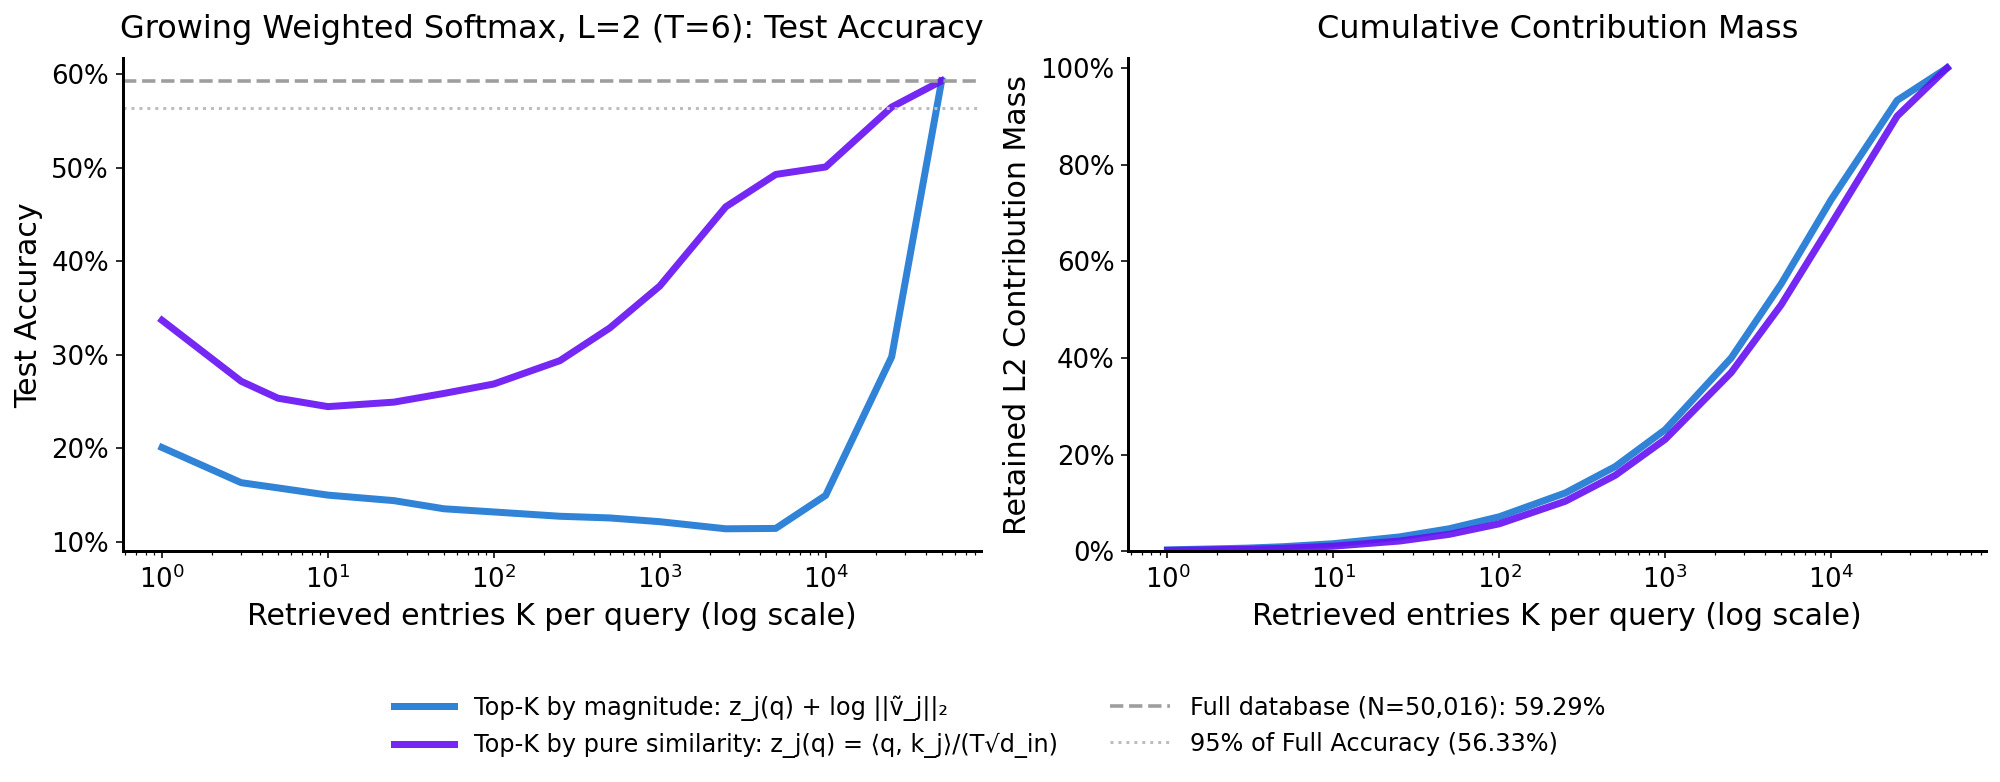

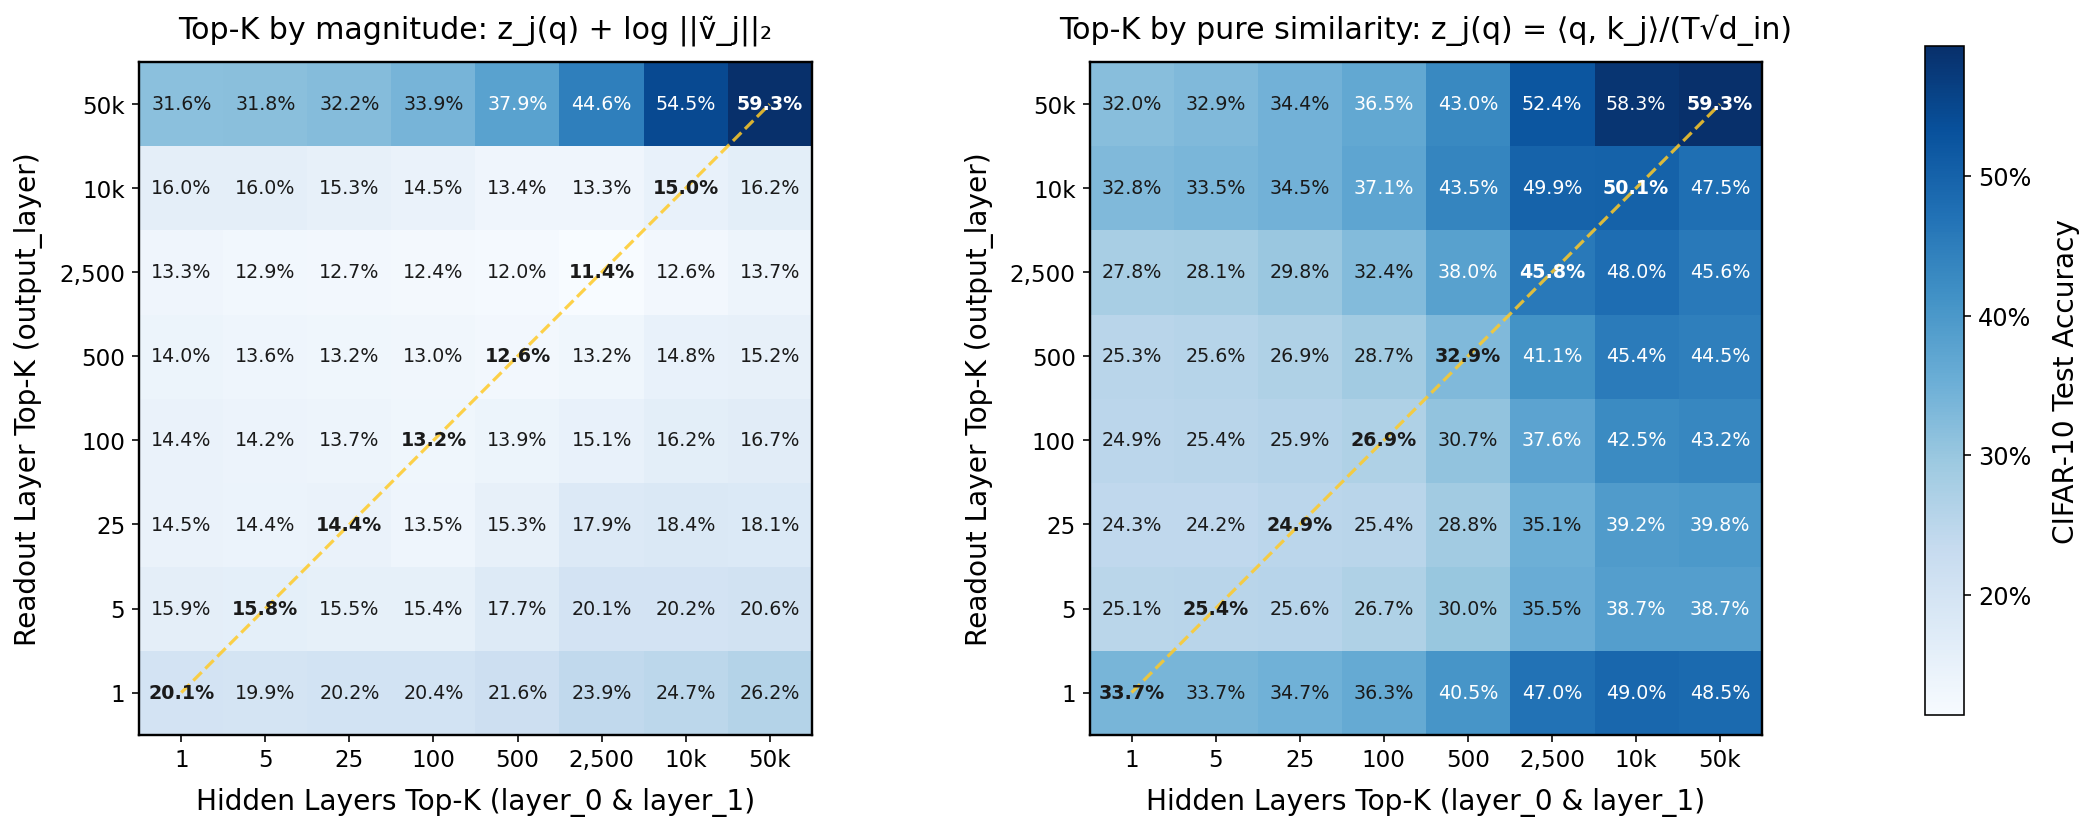

In [ ]:
#@title 11.3 Top-K Sparsity Sweep & 2D Layer-wise Heatmap on the Multi-Layer Growing Weighted Softmax (from 11.1)

# Evaluates test-time Top-K sparsity on the multi-layer Growing Weighted Softmax from 11.1
# (default: L=2, T=6.0, η=0.003, β=3.0, momentum=0.0 -> ~59.3% test accuracy).
# Computes BOTH:
#   1. The 1D equal-sparsity curve (K_hidden = K_readout = K)
#   2. The full 2D accuracy heatmap (X-axis = Hidden Layers Top-K, Y-axis = Readout Layer Top-K)
# in a single compiled pass!

FORCE_RERUN_SWEEP = False  # @param {type:"boolean"}

K_VALUES = [1, 3, 5, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 25000, 50016]
HEATMAP_K_VALUES = [1, 5, 25, 100, 500, 2500, 10000, 50016]

if 'gws_deep_result' not in globals():
  raise RuntimeError('Run 11.1 first: it trains (or reuses) the multi-layer Growing Weighted Softmax.')


def plot_topk_sparsity_results(res: Dict[str, Any], title_prefix: Optional[str] = None):
  """Plots CIFAR-10 Test Accuracy and Retained Contribution Mass vs. Top-K with legend underneath."""
  import matplotlib.ticker as mtick
  ks = res['k_values']
  n_entries = res.get('n_entries', 50016)
  cfg = res.get('cfg')
  temp = res['temperature']
  full_acc = res['accuracies']['magnitude'][-1]

  if title_prefix is not None:
    model_tag = title_prefix
  elif cfg is not None:
    model_tag = f'Growing Weighted Softmax, L={cfg.num_layers} (T={temp:g})'
  else:
    model_tag = f'Growing Weighted Softmax (T={temp:g})'

  fontsize_title = 16
  fontsize_labels = 15
  fontsize_ticks = 13
  fontsize_legend = 12
  linewidth_traj = 3.5

  fig, (ax_acc, ax_mass) = plt.subplots(1, 2, figsize=(14.0, 5.5))

  specs = [
      ('magnitude', '#1976D2', 'Top-K by magnitude: z_j(q) + log ||ṽ_j||₂'),
      ('similarity', '#6610f2', 'Top-K by pure similarity: z_j(q) = ⟨q, k_j⟩/(T√d_in)'),
  ]

  legend_handles = []
  legend_labels = []

  for r_key, col, label in specs:
    y_acc = res['accuracies'][r_key]
    y_mass = res['retained_mass'][r_key]
    h_line, = ax_acc.plot(ks, y_acc, ls='-', lw=linewidth_traj, color=col, alpha=0.9, label=label)
    ax_mass.plot(ks, y_mass, ls='-', lw=linewidth_traj, color=col, alpha=0.9, label=label)
    legend_handles.append(h_line)
    legend_labels.append(label)

  h_full = ax_acc.axhline(
      full_acc, ls='--', lw=1.8, color='#9E9E9E',
      label=f'Full database (N={n_entries:,}): {full_acc:.2f}%',
  )
  h_95 = ax_acc.axhline(
      0.95 * full_acc, ls=':', lw=1.5, color='#bdbdbd',
      label=f'95% of Full Accuracy ({0.95 * full_acc:.2f}%)',
  )
  legend_handles.extend([h_full, h_95])
  legend_labels.extend([
      f'Full database (N={n_entries:,}): {full_acc:.2f}%',
      f'95% of Full Accuracy ({0.95 * full_acc:.2f}%)',
  ])

  for ax in (ax_acc, ax_mass):
    ax.set_xscale('log')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))
    ax.grid(False)

  ax_acc.set_title(f'{model_tag}: Test Accuracy', fontsize=fontsize_title, pad=10)
  ax_acc.set_xlabel('Retrieved entries K per query (log scale)', fontsize=fontsize_labels)
  ax_acc.set_ylabel('Test Accuracy', fontsize=fontsize_labels)

  ax_mass.set_title('Cumulative Contribution Mass', fontsize=fontsize_title, pad=10)
  ax_mass.set_xlabel('Retrieved entries K per query (log scale)', fontsize=fontsize_labels)
  ax_mass.set_ylabel('Retained L2 Contribution Mass', fontsize=fontsize_labels)
  ax_mass.set_ylim(0, 102)

  plt.tight_layout(rect=[0.0, 0.16, 1.0, 1.0])
  fig.legend(
      legend_handles,
      legend_labels,
      loc='upper center',
      bbox_to_anchor=(0.5, 0.14),
      ncol=2,
      fontsize=fontsize_legend,
      frameon=False,
      handlelength=2.5,
      columnspacing=2.2,
  )
  plt.show()
  return fig


def run_topk_sparsity_evaluation(
    state: RCDLTrainState,
    cfg: RCDLConfig,
    k_list=K_VALUES,
    eval_batch_size: int = 500,
) -> Dict[str, Any]:
  """Compiled scan-based 1D + 2D (K_hidden vs K_readout) Top-K sweep on all 10,000 test images."""
  layer_names = [f'layer_{i}' for i in range(cfg.num_layers)] + ['output_layer']
  layers_data = []
  for lname in layer_names:
    lp = state.params[lname]
    keys = jnp.asarray(lp['keys'])              # (N, d_in)
    values = jnp.asarray(lp['values'])          # (N, d_out)
    weights = jnp.asarray(lp['weights'][:, 0])  # (N,)
    v_norms = jnp.linalg.norm(values, axis=-1)  # (N,)
    log_v_norms = jnp.log(jnp.maximum(v_norms, 1e-12))
    valid_mask = jnp.logical_or(jnp.any(keys != 0.0, axis=-1), weights != 0.0)
    scaling = float(cfg.temperature) * jnp.sqrt(float(keys.shape[-1]))
    layers_data.append({
        'keys': keys,
        'values': values,
        'weights': weights,
        'v_norms': v_norms,
        'log_v_norms': log_v_norms,
        'valid_mask': valid_mask,
        'scaling': scaling,
    })

  n_entries = int(layers_data[0]['keys'].shape[0])
  k_sorted = sorted(list(set(min(int(k), n_entries) for k in k_list)))
  k_arr = jnp.asarray(k_sorted, dtype=jnp.int32)
  act_fn = get_activation_fn(cfg.nonlinearity)

  def _compute_layer_stats(x: jax.Array, l_data: Dict[str, Any]):
    q = x / jnp.sqrt(jnp.mean(x ** 2, axis=-1, keepdims=True) + 1e-6)
    logits_qk = jnp.matmul(q, l_data['keys'].T) / l_data['scaling']
    logits_qk = jnp.where(l_data['valid_mask'][None, :], logits_qk, -1e9)

    max_logit = jnp.max(logits_qk, axis=-1, keepdims=True)
    exp_qk = jnp.where(
        l_data['valid_mask'][None, :], jnp.exp(logits_qk - max_logit), 0.0
    )
    denom = jnp.sum(exp_qk * l_data['weights'][None, :], axis=-1, keepdims=True)
    sign = jnp.where(jnp.sign(denom) == 0, 1.0, jnp.sign(denom))
    full_denom = jnp.maximum(jnp.abs(denom), 1e-8) * sign
    a_tilde = exp_qk / full_denom

    entry_l2 = jnp.abs(a_tilde) * l_data['v_norms'][None, :]
    total_l2_mass = jnp.maximum(jnp.sum(entry_l2, axis=-1), 1e-8)
    scores_mag = jnp.where(
        l_data['valid_mask'][None, :],
        logits_qk + l_data['log_v_norms'][None, :],
        -1e9,
    )
    return logits_qk, scores_mag, a_tilde, entry_l2, total_l2_mass

  def _project_from_sorted(
      scores: jax.Array,
      sorted_scores: jax.Array,
      a_tilde: jax.Array,
      entry_l2: jax.Array,
      total_l2_mass: jax.Array,
      values: jax.Array,
      k_val: jax.Array,
  ):
    idx = jnp.clip(n_entries - k_val, 0, n_entries - 1)
    thresh = jnp.take(sorted_scores, idx, axis=-1)[:, None]
    mask = jnp.where(k_val >= n_entries, True, scores >= thresh)
    a_k = jnp.where(mask, a_tilde, 0.0)
    retained_frac = jnp.sum(jnp.where(mask, entry_l2, 0.0), axis=-1) / total_l2_mass
    y_out = jnp.matmul(a_k, values)
    return y_out, retained_frac

  @jax.jit
  def _eval_batch_all_rules(l_list, bx: jax.Array, by: jax.Array):
    # Precompute & sort layer_0 ONCE per test batch (shared across all K_hidden!)
    l0_sim, l0_mag, l0_a, l0_entry_l2, l0_total_l2 = _compute_layer_stats(
        bx, l_list[0]
    )
    l0_sorted_mag = jnp.sort(l0_mag, axis=-1)
    l0_sorted_sim = jnp.sort(l0_sim, axis=-1)

    def _run_rule(use_mag: bool):
      l0_scores = l0_mag if use_mag else l0_sim
      l0_sorted = l0_sorted_mag if use_mag else l0_sorted_sim

      def _scan_k_hidden(carry, k_hid):
        # 1. Propagate through hidden layers (layer_0 .. layer_{L-1}) at k_hid
        y0, frac0 = _project_from_sorted(
            l0_scores, l0_sorted, l0_a, l0_entry_l2, l0_total_l2,
            l_list[0]['values'], k_hid,
        )
        if cfg.num_layers == 0:
          lo_scores, lo_sorted = l0_scores, l0_sorted
          lo_a, lo_entry_l2, lo_total_l2 = l0_a, l0_entry_l2, l0_total_l2
          frac_hid_sum = jnp.zeros_like(frac0)
        else:
          y0 = act_fn(y0)
          x_curr = (bx + y0) if cfg.use_residual else y0
          frac_hid_sum = frac0

          for l_idx in range(1, cfg.num_layers):
            li_sim, li_mag, li_a, li_entry_l2, li_total_l2 = _compute_layer_stats(
                x_curr, l_list[l_idx]
            )
            li_scores = li_mag if use_mag else li_sim
            li_sorted = jnp.sort(li_scores, axis=-1)
            yi, fraci = _project_from_sorted(
                li_scores, li_sorted, li_a, li_entry_l2, li_total_l2,
                l_list[l_idx]['values'], k_hid,
            )
            yi = act_fn(yi)
            x_curr = (x_curr + yi) if cfg.use_residual else yi
            frac_hid_sum = frac_hid_sum + fraci

          # Compute & sort readout layer ONCE for this k_hid
          lo_sim, lo_mag, lo_a, lo_entry_l2, lo_total_l2 = _compute_layer_stats(
              x_curr, l_list[-1]
          )
          lo_scores = lo_mag if use_mag else lo_sim
          lo_sorted = jnp.sort(lo_scores, axis=-1)

        # 2. Sweep ALL k_readout values on the 10-D readout layer (tiny (B, N) @ (N, 10) matmuls!)
        def _scan_k_readout(c_out, k_out):
          logits_k, fraco = _project_from_sorted(
              lo_scores, lo_sorted, lo_a, lo_entry_l2, lo_total_l2,
              l_list[-1]['values'], k_out,
          )
          preds_k = jnp.argmax(logits_k, axis=-1)
          mean_frac = (frac_hid_sum + fraco) / float(len(l_list))
          return c_out, (jnp.sum(preds_k == by), jnp.sum(mean_frac))

        _, (corr_row, mass_row) = jax.lax.scan(_scan_k_readout, None, k_arr)
        return carry, (corr_row, mass_row)

      # Shape of corr_grid, mass_grid: (n_k_hidden, n_k_readout)
      _, (corr_grid, mass_grid) = jax.lax.scan(_scan_k_hidden, None, k_arr)
      return corr_grid, mass_grid

    return {
        'magnitude': _run_rule(True),
        'similarity': _run_rule(False),
    }

  num_test = test_images.shape[0]
  num_batches = num_test // eval_batch_size
  n_eval = num_batches * eval_batch_size
  n_k = len(k_sorted)

  # Grid indexed as [k_hidden_idx, k_readout_idx]
  totals_correct_grid = {r: np.zeros((n_k, n_k), dtype=np.float64)
                         for r in ('magnitude', 'similarity')}
  totals_mass_grid = {r: np.zeros((n_k, n_k), dtype=np.float64)
                      for r in ('magnitude', 'similarity')}

  t0 = time.time()
  desc_str = (
      f'1D+2D Top-K Sweep ({cfg.num_layers}L + readout, '
      f'T={cfg.temperature:g}, η={cfg.eta:g}, β={cfg.beta:g})'
  )
  for b_i in tqdm(range(num_batches), desc=desc_str):
    sl = slice(b_i * eval_batch_size, (b_i + 1) * eval_batch_size)
    b_res = _eval_batch_all_rules(
        layers_data, jnp.asarray(test_images[sl]), jnp.asarray(test_labels[sl]))
    for r in ('magnitude', 'similarity'):
      c_grid, m_grid = b_res[r]
      totals_correct_grid[r] += np.asarray(c_grid, dtype=np.float64)
      totals_mass_grid[r] += np.asarray(m_grid, dtype=np.float64)

  elapsed = time.time() - t0
  # acc_grid[r] has shape (n_k_readout, n_k_hidden) so Y-axis = K_readout, X-axis = K_hidden
  acc_grid = {r: (totals_correct_grid[r].T / n_eval) * 100.0 for r in totals_correct_grid}
  mass_grid = {r: (totals_mass_grid[r].T / n_eval) * 100.0 for r in totals_mass_grid}

  results = {
      'k_values': np.asarray(k_sorted),
      'n_entries': n_entries,
      'cfg': cfg,
      'temperature': cfg.temperature,
      'elapsed': elapsed,
      'accuracies': {r: np.diag(acc_grid[r]) for r in acc_grid},
      'retained_mass': {r: np.diag(mass_grid[r]) for r in mass_grid},
      'acc_grid_2d': acc_grid,
      'mass_grid_2d': mass_grid,
  }

  full_acc = results['accuracies']['magnitude'][-1]
  print(f"\nCompleted 1D + 2D Top-K Sparsity Sweep in {elapsed:.1f}s "
        f"(Full N={n_entries:,} Acc: {full_acc:.2f}%)")
  print(f"{'Top-K':>8} | {'% of database':>11} | {'Magnitude ||c_j||₂':>18} | "
        f"{'Pure sim z_j':>18}")
  print('-' * 63)
  for idx_k, k_val in enumerate(k_sorted):
    pct_mem = 100.0 * k_val / float(n_entries)
    a_mag = results['accuracies']['magnitude'][idx_k]
    a_sim = results['accuracies']['similarity'][idx_k]
    print(f"{k_val:>8,d} | {pct_mem:>10.2f}% | {a_mag:>17.2f}% | {a_sim:>17.2f}%")

  return results


def plot_topk_2d_heatmap(res: Dict[str, Any], heatmap_ks=HEATMAP_K_VALUES):
  """Plots side-by-side 2D Test Accuracy Heatmaps (X = Hidden Layers Top-K, Y = Readout Layer Top-K)."""
  import matplotlib.ticker as mtick
  if 'acc_grid_2d' not in res:
    print("2D grid not found in cached results; re-running evaluation with 2D grid enabled...")
    return None

  all_ks = list(res['k_values'])
  sel_indices = [all_ks.index(k) for k in heatmap_ks if k in all_ks]
  if not sel_indices:
    sel_indices = list(range(len(all_ks)))
  sel_ks = [all_ks[i] for i in sel_indices]
  k_labels = [f"{k:,}" if k < 10000 else f"{k/1000:.0f}k" for k in sel_ks]

  grid_mag = res['acc_grid_2d']['magnitude'][np.ix_(sel_indices, sel_indices)]
  grid_sim = res['acc_grid_2d']['similarity'][np.ix_(sel_indices, sel_indices)]

  vmin = max(10.0, float(min(np.min(grid_mag), np.min(grid_sim))))
  vmax = float(max(np.max(grid_mag), np.max(grid_sim)))

  fig, (ax_mag, ax_sim) = plt.subplots(1, 2, figsize=(15.0, 6.2))
  panels = [
      (ax_mag, grid_mag, 'Top-K by magnitude: z_j(q) + log ||ṽ_j||₂'),
      (ax_sim, grid_sim, 'Top-K by pure similarity: z_j(q) = ⟨q, k_j⟩/(T√d_in)'),
  ]

  im = None
  n_g = len(sel_ks)
  for ax, mat, title in panels:
    im = ax.imshow(mat, origin='lower', cmap='Blues', vmin=vmin, vmax=vmax, aspect='equal')
    # Dashed diagonal reference line (K_hidden == K_readout, corresponding to the 1D curve)
    ax.plot(np.arange(n_g), np.arange(n_g), ls='--', lw=1.6, color='#ffca28', alpha=0.85)

    for r_i in range(n_g):
      for c_i in range(n_g):
        val = mat[r_i, c_i]
        txt_col = 'white' if val > (vmin + 0.52 * (vmax - vmin)) else '#1a1a1a'
        ax.text(c_i, r_i, f"{val:.1f}%", ha='center', va='center',
                fontsize=9.5, color=txt_col, fontweight='bold' if r_i == c_i else 'normal')

    ax.set_xticks(np.arange(n_g))
    ax.set_xticklabels(k_labels, fontsize=11.5)
    ax.set_yticks(np.arange(n_g))
    ax.set_yticklabels(k_labels, fontsize=11.5)
    ax.set_xlabel('Hidden Layers Top-K (layer_0 & layer_1)', fontsize=14, labelpad=8)
    ax.set_ylabel('Readout Layer Top-K (output_layer)', fontsize=14, labelpad=8)
    ax.set_title(title, fontsize=15, pad=12)
    for sp in ('top', 'right', 'bottom', 'left'):
      ax.spines[sp].set_linewidth(1.2)

  plt.tight_layout(rect=[0.0, 0.0, 0.91, 0.95])
  cbar_ax = fig.add_axes([0.925, 0.14, 0.018, 0.75])
  cbar = fig.colorbar(im, cax=cbar_ax)
  cbar.set_label('CIFAR-10 Test Accuracy', fontsize=14, labelpad=10)
  cbar.ax.tick_params(labelsize=12)
  cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))
  plt.show()
  return fig


if (
    FORCE_RERUN_SWEEP
    or 'topk_sweep_results' not in globals()
    or topk_sweep_results.get('cfg') != gws_deep_cfg
    or 'acc_grid_2d' not in topk_sweep_results
):
  topk_sweep_results = run_topk_sparsity_evaluation(
      gws_deep_result['state'], gws_deep_cfg, k_list=K_VALUES)
from IPython.display import display, HTML
_ = plot_topk_sparsity_results(topk_sweep_results)
display(HTML('<div style="height: 36px;"></div>'))
_ = plot_topk_2d_heatmap(topk_sweep_results, heatmap_ks=HEATMAP_K_VALUES)


### Citation
```bibtex
@inproceedings{rcdl2026,
  title={Retrieval-Centric Deep Learning in Growing Nonparametric Neural Networks},
  author={Anonymous Author(s)},
  booktitle={Advances in Neural Information Processing Systems (NeurIPS)},
  year={2026}
}
```